# EDA Completo — Symile-MIMIC  (v3 · Raw + Percentil + Dimensional)
## Sistema Multimodal de Apoyo a la Decisión Clínica
### Train / Val / Test · Análisis Exploratorio Extendido con IVF + PCA/t-SNE + Missingness Estructural
---
**Estructura del notebook:**
- **Bloque 0** — Imports, config y carga de datos
- **Bloque 1** — Visión general del dataset
- **Bloque 2** — Análisis demográfico completo
- **Bloque 3** — Análisis de etiquetas diagnósticas
- **Bloque 4** — Analíticas sanguíneas: missingness, raw vs percentil
- **Bloque 5** — Analíticas vs etiquetas: boxplots y tests estadísticos
- **Bloque 6** — Análisis multivariante
- **Bloque 7** — Poder discriminativo AUC y perfiles clínicos radar
- **Bloque 8** — Calidad, desequilibrio y consistencia entre splits
- **Bloque 9** — Inferencia estadística: forest plot y heatmap p-valores
- **Bloque 10** — Clustering jerárquico y distribuciones detalladas
- **Bloque 11** — 🆕 PCA y t-SNE sobre Labs Raw (reducción dimensional)
- **Bloque 12** — 🆕 Co-ocurrencia ampliada, Jaccard y Correlación Spearman Labs × Etiquetas
- **Bloque 13** — 🆕 Perfiles analíticos: Radar + Distribuciones + AUC-MW agregado
- **Bloque 14** — 🆕 Missingness estructural (MNAR vs MCAR, patrones, edad, tipo ingreso)
- **Bloque 15** — 🆕 IVF — Importancia de Variables (Random Forest + mutual info + ANOVA)
- **Bloque 16** — Asociaciones género × etnia × etiquetas
- **Bloque 17** — 🆕 Raw vs Percentil: análisis comparativo y redundancia
- **Bloque 18** — Tabla resumen ejecutivo
---

---
## Bloque 0 — Importaciones, Configuración y Carga de Datos

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import matplotlib.patheffects as mpe
import seaborn as sns
from scipy import stats
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from itertools import combinations

# ── Directorio de salida ──
OUT_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'eda_outputs')
os.makedirs(OUT_DIR, exist_ok=True)

def out(filename):
    return os.path.join(OUT_DIR, filename)

# ── Paleta dark GitHub ──
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'font.size': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#c9d1d9',
    'ytick.color': '#c9d1d9',
    'text.color': '#c9d1d9',
    'axes.edgecolor': '#30363d',
    'grid.color': '#21262d',
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
})

DARK_BG  = '#0d1117'
PANEL_BG = '#161b22'
C_CYAN   = '#58a6ff'
C_PINK   = '#f78166'
C_GREEN  = '#3fb950'
C_ORANGE = '#d29922'
C_PURPLE = '#bc8cff'
C_TEAL   = '#39d353'
C_RED    = '#da3633'
C_GREY   = '#8b949e'
C_YELLOW = '#e3b341'
C_LBLUE  = '#79c0ff'

SPLIT_COLORS = {'train': C_CYAN, 'val': C_ORANGE, 'test': C_GREEN}
STATE_COLORS = {1: C_GREEN, 0: C_PINK, -1: C_ORANGE, 'NaN': C_GREY}

LABEL_COLS    = ['Atelectasis','Cardiomegaly','Edema','Lung Opacity','No Finding','Pleural Effusion']
LABEL_DISPLAY = ['Atelectasis','Cardiomegalia','Edema','Opac. Pulmonar','Sin Hallazgo','Derrame Pleural']

RACE_MAP = {
    'WHITE':'Blanco','BLACK':'Negro','UNKNOWN':'Desconocido',
    'HISPANIC_LATINO':'Hispano','ASIAN':'Asiático','OTHER_KNOWN':'Otro conocido',
}
ADM_TYPE_MAP = {
    'EMERGENCY':'Urgencias','OBSERVATION':'Observación',
    'URGENT':'Urgente','SCHEDULED':'Planificado',
}
ADM_LOC_MAP = {
    'EMERGENCY_ROOM':'Urgencias','REFERRAL':'Derivación',
    'TRANSFER':'Traslado','INTRA_HOSPITAL':'Intra-hospital',
}

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

print(f"Directorio de salida: {OUT_DIR}")


Directorio de salida: c:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\notebooks\eda_outputs


In [2]:
# ── Carga de datos ──
BASE = r"C:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\data\clean"

train = pd.read_csv(os.path.join(BASE, "train_clean.csv"), sep=";")
val   = pd.read_csv(os.path.join(BASE, "val_clean.csv"),   sep=";")
test  = pd.read_csv(os.path.join(BASE, "test_clean.csv"),  sep=";")

dfs = {"train": train, "val": val, "test": test}

META_COLS = ['subject_id','hadm_id','cxr_path','ecg_path','age','gender','race',
             'admission_type','admission_location','cxr_view','hours_adm_to_cxr']

LAB_RAW_COLS    = [c for c in train.columns
                   if c not in META_COLS + LABEL_COLS and 'pctile' not in c]
LAB_PCTILE_COLS = [c for c in train.columns if 'pctile' in c]

def make_display_name(col):
    name = col.replace('_pctile','').replace('_pct_','_').rstrip('_')
    parts = name.split('_')
    parts = [p for p in parts if not p.isdigit()]
    return ' '.join(parts).title()

LAB_RAW_DISP    = [make_display_name(c) for c in LAB_RAW_COLS]
LAB_PCTILE_DISP = [make_display_name(c) for c in LAB_PCTILE_COLS]

for name, df in dfs.items():
    print(f"{name}: {df.shape[0]:,} filas × {df.shape[1]} cols")

print(f"\nLabs raw:       {len(LAB_RAW_COLS)}")
print(f"Labs percentil: {len(LAB_PCTILE_COLS)}")


train: 10,000 filas × 99 cols
val: 750 filas × 99 cols
test: 464 filas × 99 cols

Labs raw:       41
Labs percentil: 41


---
## Bloque 1 — Visión General del Dataset

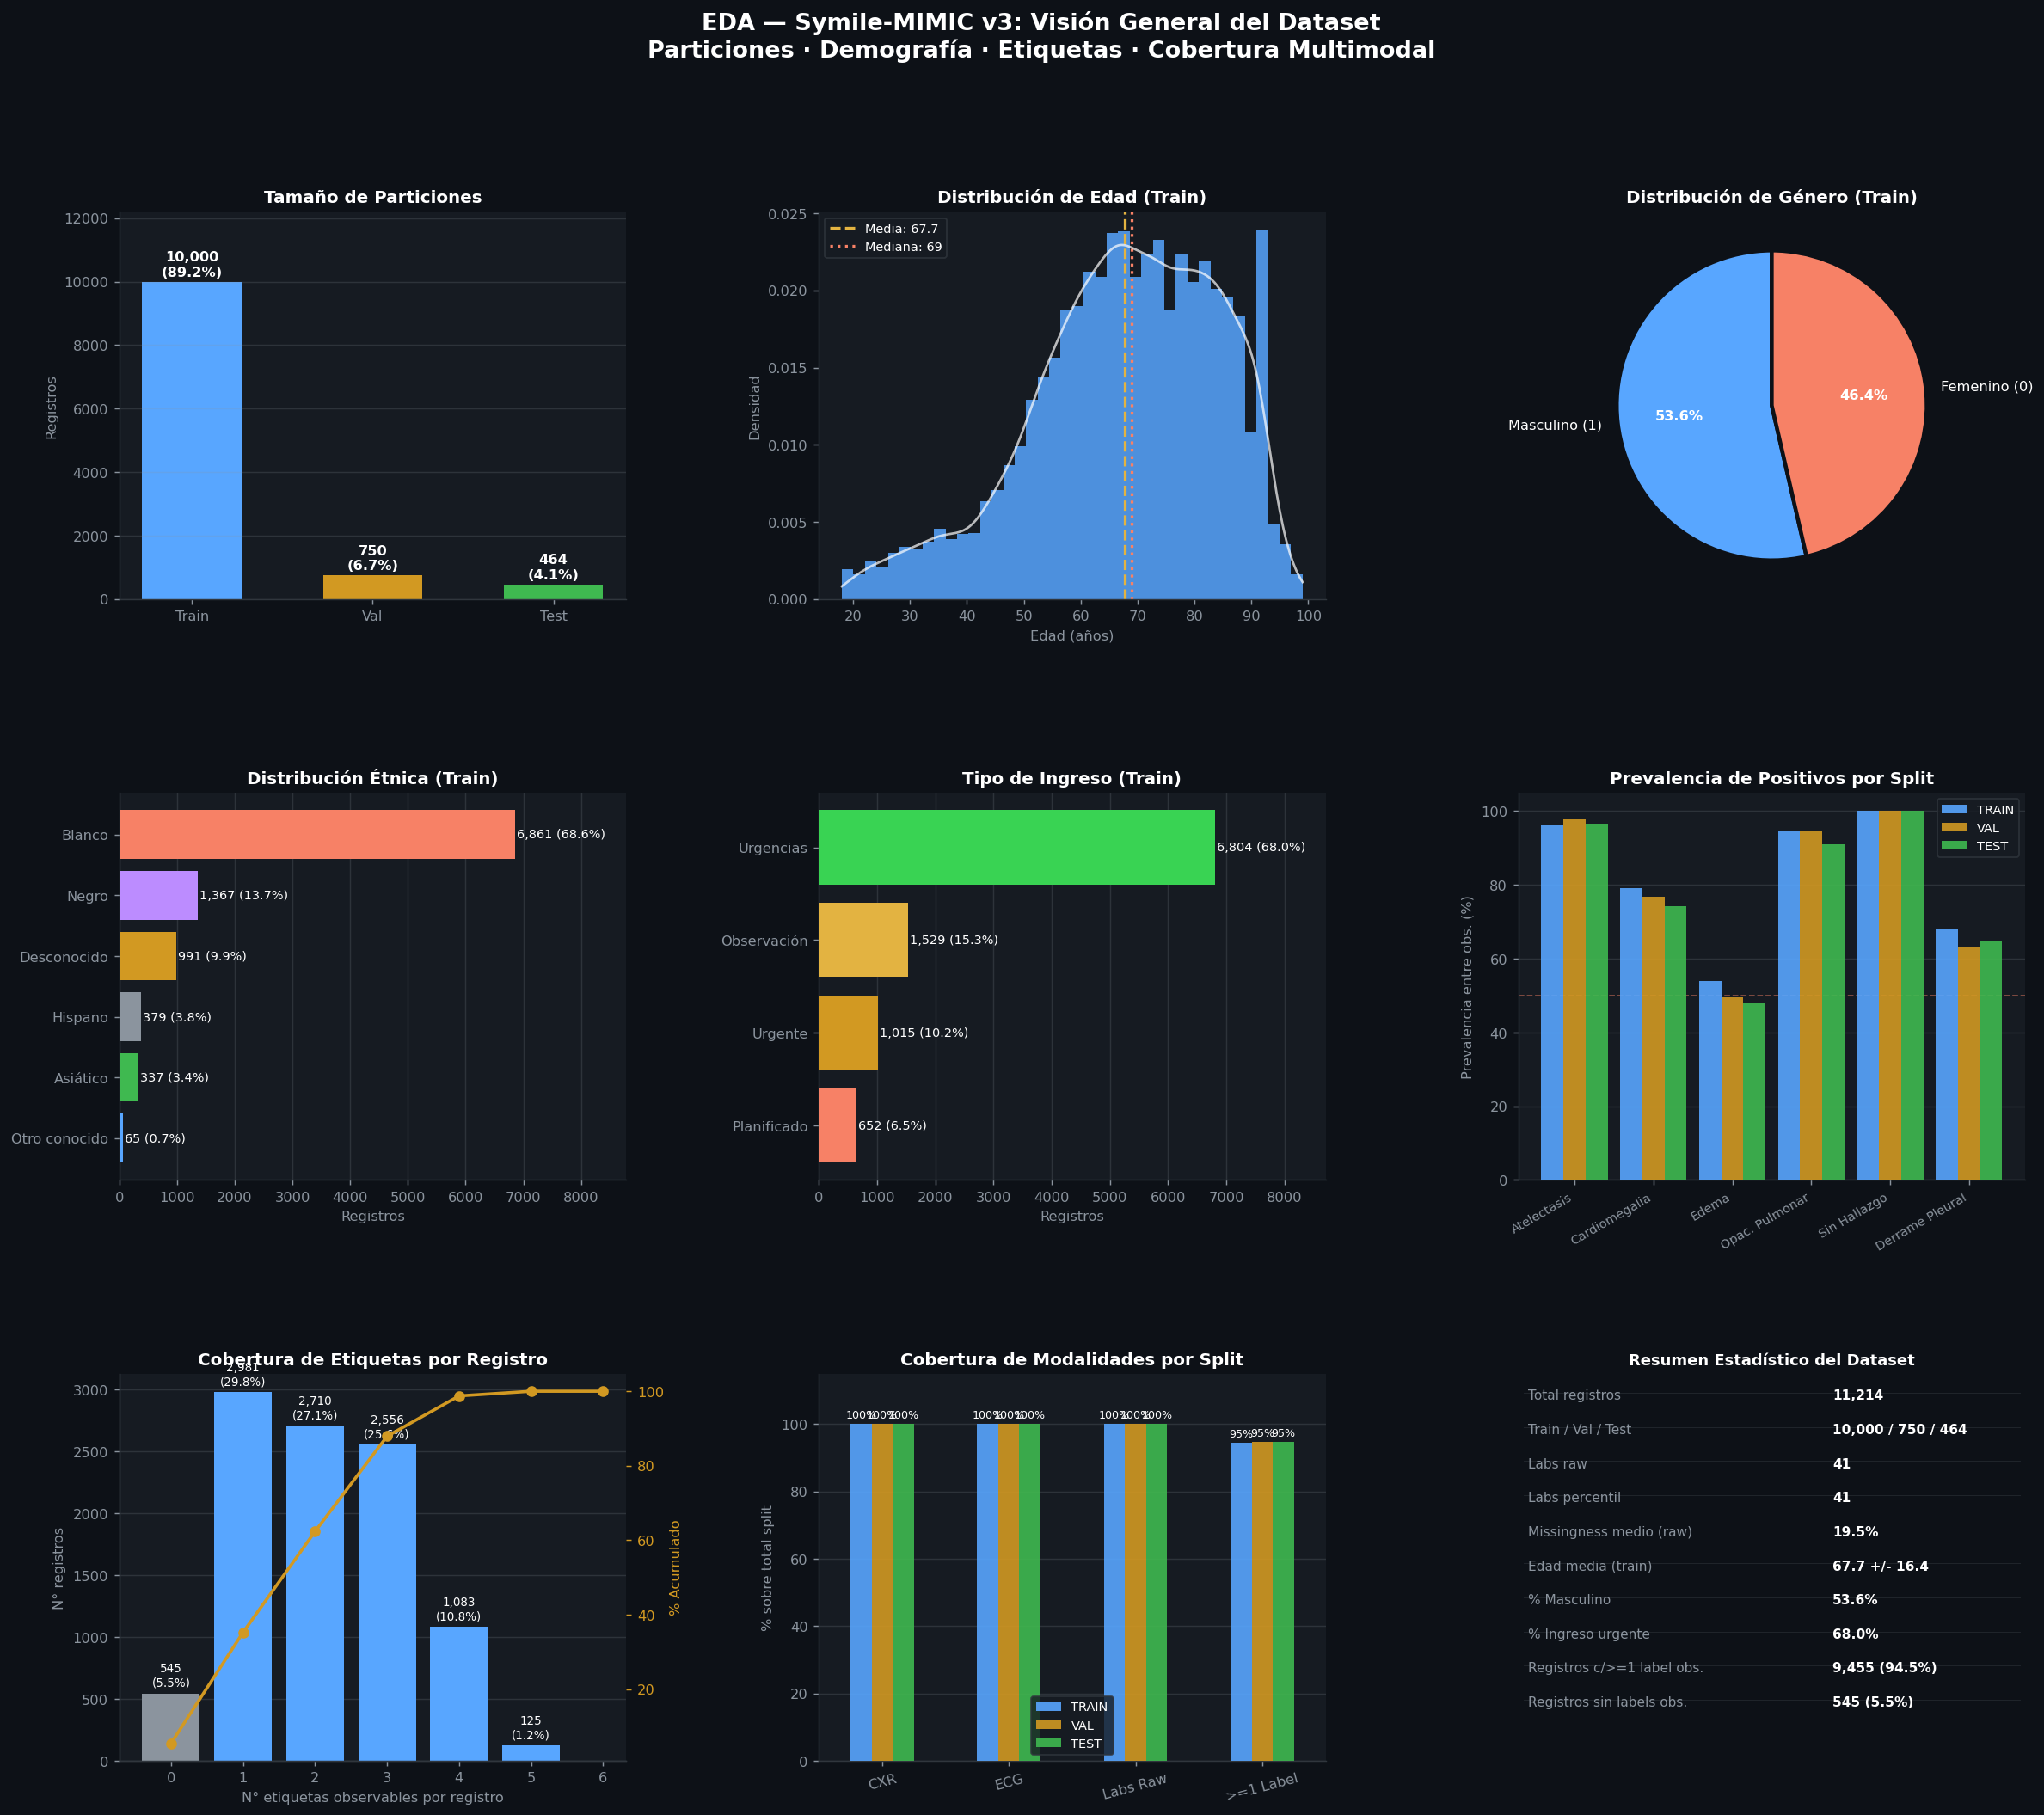

Bloque 1 guardado.


In [3]:
fig = plt.figure(figsize=(22, 18), facecolor=DARK_BG)
fig.suptitle('EDA — Symile-MIMIC v3: Visión General del Dataset\n'
             'Particiones · Demografía · Etiquetas · Cobertura Multimodal',
             fontsize=15, fontweight='bold', color='white', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.38)

sizes = {s: len(dfs[s]) for s in ['train','val','test']}
total = sum(sizes.values())
colors_pie = [C_CYAN, C_ORANGE, C_GREEN]

ax0 = fig.add_subplot(gs[0, 0], facecolor=PANEL_BG)
bars = ax0.bar(['Train','Val','Test'], list(sizes.values()), color=colors_pie, edgecolor='none', width=0.55)
for bar, (s, n) in zip(bars, sizes.items()):
    ax0.text(bar.get_x()+bar.get_width()/2, n+100,
             f'{n:,}\n({n/total*100:.1f}%)', ha='center', va='bottom', fontsize=9, color='white', fontweight='bold')
ax0.set_ylim(0, max(sizes.values())*1.22)
ax0.set_title('Tamaño de Particiones', color='white')
ax0.set_ylabel('Registros', color=C_GREY)
ax0.tick_params(colors=C_GREY)
ax0.yaxis.grid(True, alpha=0.2, color=C_GREY)

ax1 = fig.add_subplot(gs[0, 1], facecolor=PANEL_BG)
ages = train['age'].dropna()
ax1.hist(ages, bins=40, color=C_CYAN, edgecolor='none', alpha=0.85, density=True)
ax1.axvline(ages.mean(),   color=C_YELLOW, linewidth=1.8, linestyle='--', label=f'Media: {ages.mean():.1f}')
ax1.axvline(ages.median(), color=C_PINK,   linewidth=1.8, linestyle=':', label=f'Mediana: {ages.median():.0f}')
try:
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(ages)
    kx = np.linspace(ages.min(), ages.max(), 300)
    ax1.plot(kx, kde(kx), color='white', linewidth=1.5, alpha=0.7)
except Exception: pass
ax1.set_title('Distribución de Edad (Train)', color='white')
ax1.set_xlabel('Edad (años)', color=C_GREY)
ax1.set_ylabel('Densidad', color=C_GREY)
ax1.legend(fontsize=8, labelcolor='white')
ax1.tick_params(colors=C_GREY)

ax2 = fig.add_subplot(gs[0, 2], facecolor=PANEL_BG)
gcounts = train['gender'].value_counts()
wedges, texts, autotexts = ax2.pie(gcounts.values, labels=['Masculino (1)','Femenino (0)'],
    colors=[C_CYAN, C_PINK], autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': DARK_BG, 'linewidth': 2.5}, textprops={'color': 'white', 'fontsize': 9})
for at in autotexts: at.set_color('white'); at.set_fontweight('bold')
ax2.set_title('Distribución de Género (Train)', color='white')

ax3 = fig.add_subplot(gs[1, 0], facecolor=PANEL_BG)
rcounts = train['race'].map(RACE_MAP).fillna('Otro').value_counts()
pal_r = [C_CYAN, C_GREEN, C_GREY, C_ORANGE, C_PURPLE, C_PINK]
bars3 = ax3.barh(rcounts.index[::-1], rcounts.values[::-1], color=pal_r[:len(rcounts)], edgecolor='none', zorder=3)
for bar, v in zip(bars3, rcounts.values[::-1]):
    ax3.text(v+30, bar.get_y()+bar.get_height()/2, f'{v:,} ({v/len(train)*100:.1f}%)', va='center', fontsize=8, color='white')
ax3.set_title('Distribución Étnica (Train)', color='white')
ax3.set_xlabel('Registros', color=C_GREY)
ax3.set_xlim(0, rcounts.max()*1.28)
ax3.tick_params(colors=C_GREY)
ax3.xaxis.grid(True, alpha=0.2, color=C_GREY)

ax4 = fig.add_subplot(gs[1, 1], facecolor=PANEL_BG)
acounts = train['admission_type'].map(ADM_TYPE_MAP).fillna(train['admission_type']).value_counts()
pal_a = [C_PINK, C_ORANGE, C_YELLOW, C_TEAL, C_CYAN, C_PURPLE, C_GREY, C_GREEN]
bars4 = ax4.barh(acounts.index[::-1], acounts.values[::-1], color=pal_a[:len(acounts)], edgecolor='none', zorder=3)
for bar, v in zip(bars4, acounts.values[::-1]):
    ax4.text(v+30, bar.get_y()+bar.get_height()/2, f'{v:,} ({v/len(train)*100:.1f}%)', va='center', fontsize=8, color='white')
ax4.set_title('Tipo de Ingreso (Train)', color='white')
ax4.set_xlabel('Registros', color=C_GREY)
ax4.set_xlim(0, acounts.max()*1.28)
ax4.tick_params(colors=C_GREY)
ax4.xaxis.grid(True, alpha=0.2, color=C_GREY)

ax5 = fig.add_subplot(gs[1, 2], facecolor=PANEL_BG)
x = np.arange(len(LABEL_DISPLAY))
width = 0.28
for i, (sp, col) in enumerate(SPLIT_COLORS.items()):
    df_sp = dfs[sp]
    prev = []
    for lc in LABEL_COLS:
        s = df_sp[lc]; obs = int(((s==0)|(s==1)).sum()); pos = int((s==1).sum())
        prev.append(pos/obs*100 if obs>0 else 0)
    ax5.bar(x + i*width, prev, width, label=sp.upper(), color=col, edgecolor='none', alpha=0.9, zorder=3)
ax5.set_xticks(x + width)
ax5.set_xticklabels(LABEL_DISPLAY, rotation=30, ha='right', fontsize=8, color=C_GREY)
ax5.set_ylabel('Prevalencia entre obs. (%)', color=C_GREY)
ax5.set_title('Prevalencia de Positivos por Split', color='white')
ax5.legend(fontsize=8, labelcolor='white')
ax5.yaxis.grid(True, alpha=0.2, color=C_GREY)
ax5.axhline(50, color=C_PINK, linewidth=1, linestyle='--', alpha=0.5)
ax5.tick_params(colors=C_GREY)

ax6 = fig.add_subplot(gs[2, 0], facecolor=PANEL_BG)
obs_per_row = train[LABEL_COLS].apply(lambda x: ((x==0)|(x==1)).sum(), axis=1)
counts_obs  = obs_per_row.value_counts().sort_index()
bars6 = ax6.bar(counts_obs.index, counts_obs.values,
                color=[C_GREY if k==0 else C_CYAN for k in counts_obs.index], edgecolor='none', zorder=3)
for bar in bars6:
    h = int(bar.get_height())
    ax6.text(bar.get_x()+bar.get_width()/2, h+40, f'{h:,}\n({h/len(train)*100:.1f}%)',
             ha='center', va='bottom', fontsize=7.5, color='white')
ax2b = ax6.twinx()
cumsum = np.cumsum([counts_obs.get(i,0) for i in range(7)])
ax2b.plot(range(len(cumsum)), cumsum/len(train)*100, color=C_ORANGE, marker='o', lw=2, zorder=5)
ax2b.set_ylabel('% Acumulado', color=C_ORANGE)
ax2b.tick_params(colors=C_ORANGE)
ax2b.spines['right'].set_color(C_ORANGE)
ax6.set_xticks(range(7))
ax6.set_xlabel('N° etiquetas observables por registro', color=C_GREY)
ax6.set_ylabel('N° registros', color=C_GREY)
ax6.set_title('Cobertura de Etiquetas por Registro', color='white')
ax6.tick_params(colors=C_GREY)
ax6.yaxis.grid(True, alpha=0.2, color=C_GREY)

ax7 = fig.add_subplot(gs[2, 1], facecolor=PANEL_BG)
modal_data = []
for sp in ['train','val','test']:
    df_sp = dfs[sp]; n = len(df_sp)
    obs_any = df_sp[LABEL_COLS].apply(lambda x: ((x==0)|(x==1)).sum(), axis=1)
    modal_data.append({'Split': sp.upper(), 'CXR': df_sp['cxr_path'].notna().sum()/n*100,
        'ECG': df_sp['ecg_path'].notna().sum()/n*100,
        'Labs Raw': (~df_sp[LAB_RAW_COLS].isna().all(axis=1)).sum()/n*100,
        '>=1 Label': (obs_any>=1).sum()/n*100})
df_modal = pd.DataFrame(modal_data).set_index('Split')
df_modal.T.plot(kind='bar', ax=ax7, color=list(SPLIT_COLORS.values()), edgecolor='none', alpha=0.9, zorder=3)
ax7.set_ylim(0, 115)
ax7.set_ylabel('% sobre total split', color=C_GREY)
ax7.set_title('Cobertura de Modalidades por Split', color='white')
ax7.tick_params(axis='x', rotation=15, colors=C_GREY)
ax7.tick_params(axis='y', colors=C_GREY)
ax7.legend(fontsize=8, labelcolor='white')
ax7.yaxis.grid(True, alpha=0.2, color=C_GREY)
for container in ax7.containers:
    ax7.bar_label(container, fmt='%.0f%%', fontsize=7, color='white', padding=2)

ax8 = fig.add_subplot(gs[2, 2], facecolor=PANEL_BG)
ax8.axis('off')
miss_raw_mean = train[LAB_RAW_COLS].isnull().mean().mean()*100
obs_any_train = train[LABEL_COLS].apply(lambda x: ((x==0)|(x==1)).sum(), axis=1)
summary = [
    ('Total registros', f'{total:,}'),
    ('Train / Val / Test', f'{len(train):,} / {len(val):,} / {len(test):,}'),
    ('Labs raw', f'{len(LAB_RAW_COLS)}'),
    ('Labs percentil', f'{len(LAB_PCTILE_COLS)}'),
    ('Missingness medio (raw)', f'{miss_raw_mean:.1f}%'),
    ('Edad media (train)', f'{ages.mean():.1f} +/- {ages.std():.1f}'),
    ('% Masculino', f'{(train["gender"]==1).mean()*100:.1f}%'),
    ('% Ingreso urgente', f'{(train["admission_type"]=="EMERGENCY").mean()*100:.1f}%'),
    ('Registros c/>=1 label obs.', f'{(obs_any_train>=1).sum():,} ({(obs_any_train>=1).mean()*100:.1f}%)'),
    ('Registros sin labels obs.', f'{(obs_any_train==0).sum():,} ({(obs_any_train==0).mean()*100:.1f}%)'),
]
for i, (metric, value) in enumerate(summary):
    y = 0.96 - i * 0.088
    ax8.text(0.02, y, metric, fontsize=8.5, color=C_GREY, va='top')
    ax8.text(0.62, y, value, fontsize=8.5, color='white', va='top', fontweight='bold')
    ax8.axhline(y-0.01, xmin=0.01, xmax=0.99, color='#21262d', linewidth=0.5)
ax8.set_title('Resumen Estadístico del Dataset', color='white', fontsize=10)

plt.savefig(out('block1_overview.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 1 guardado.")


---
## Bloque 2 — Análisis Demográfico Completo

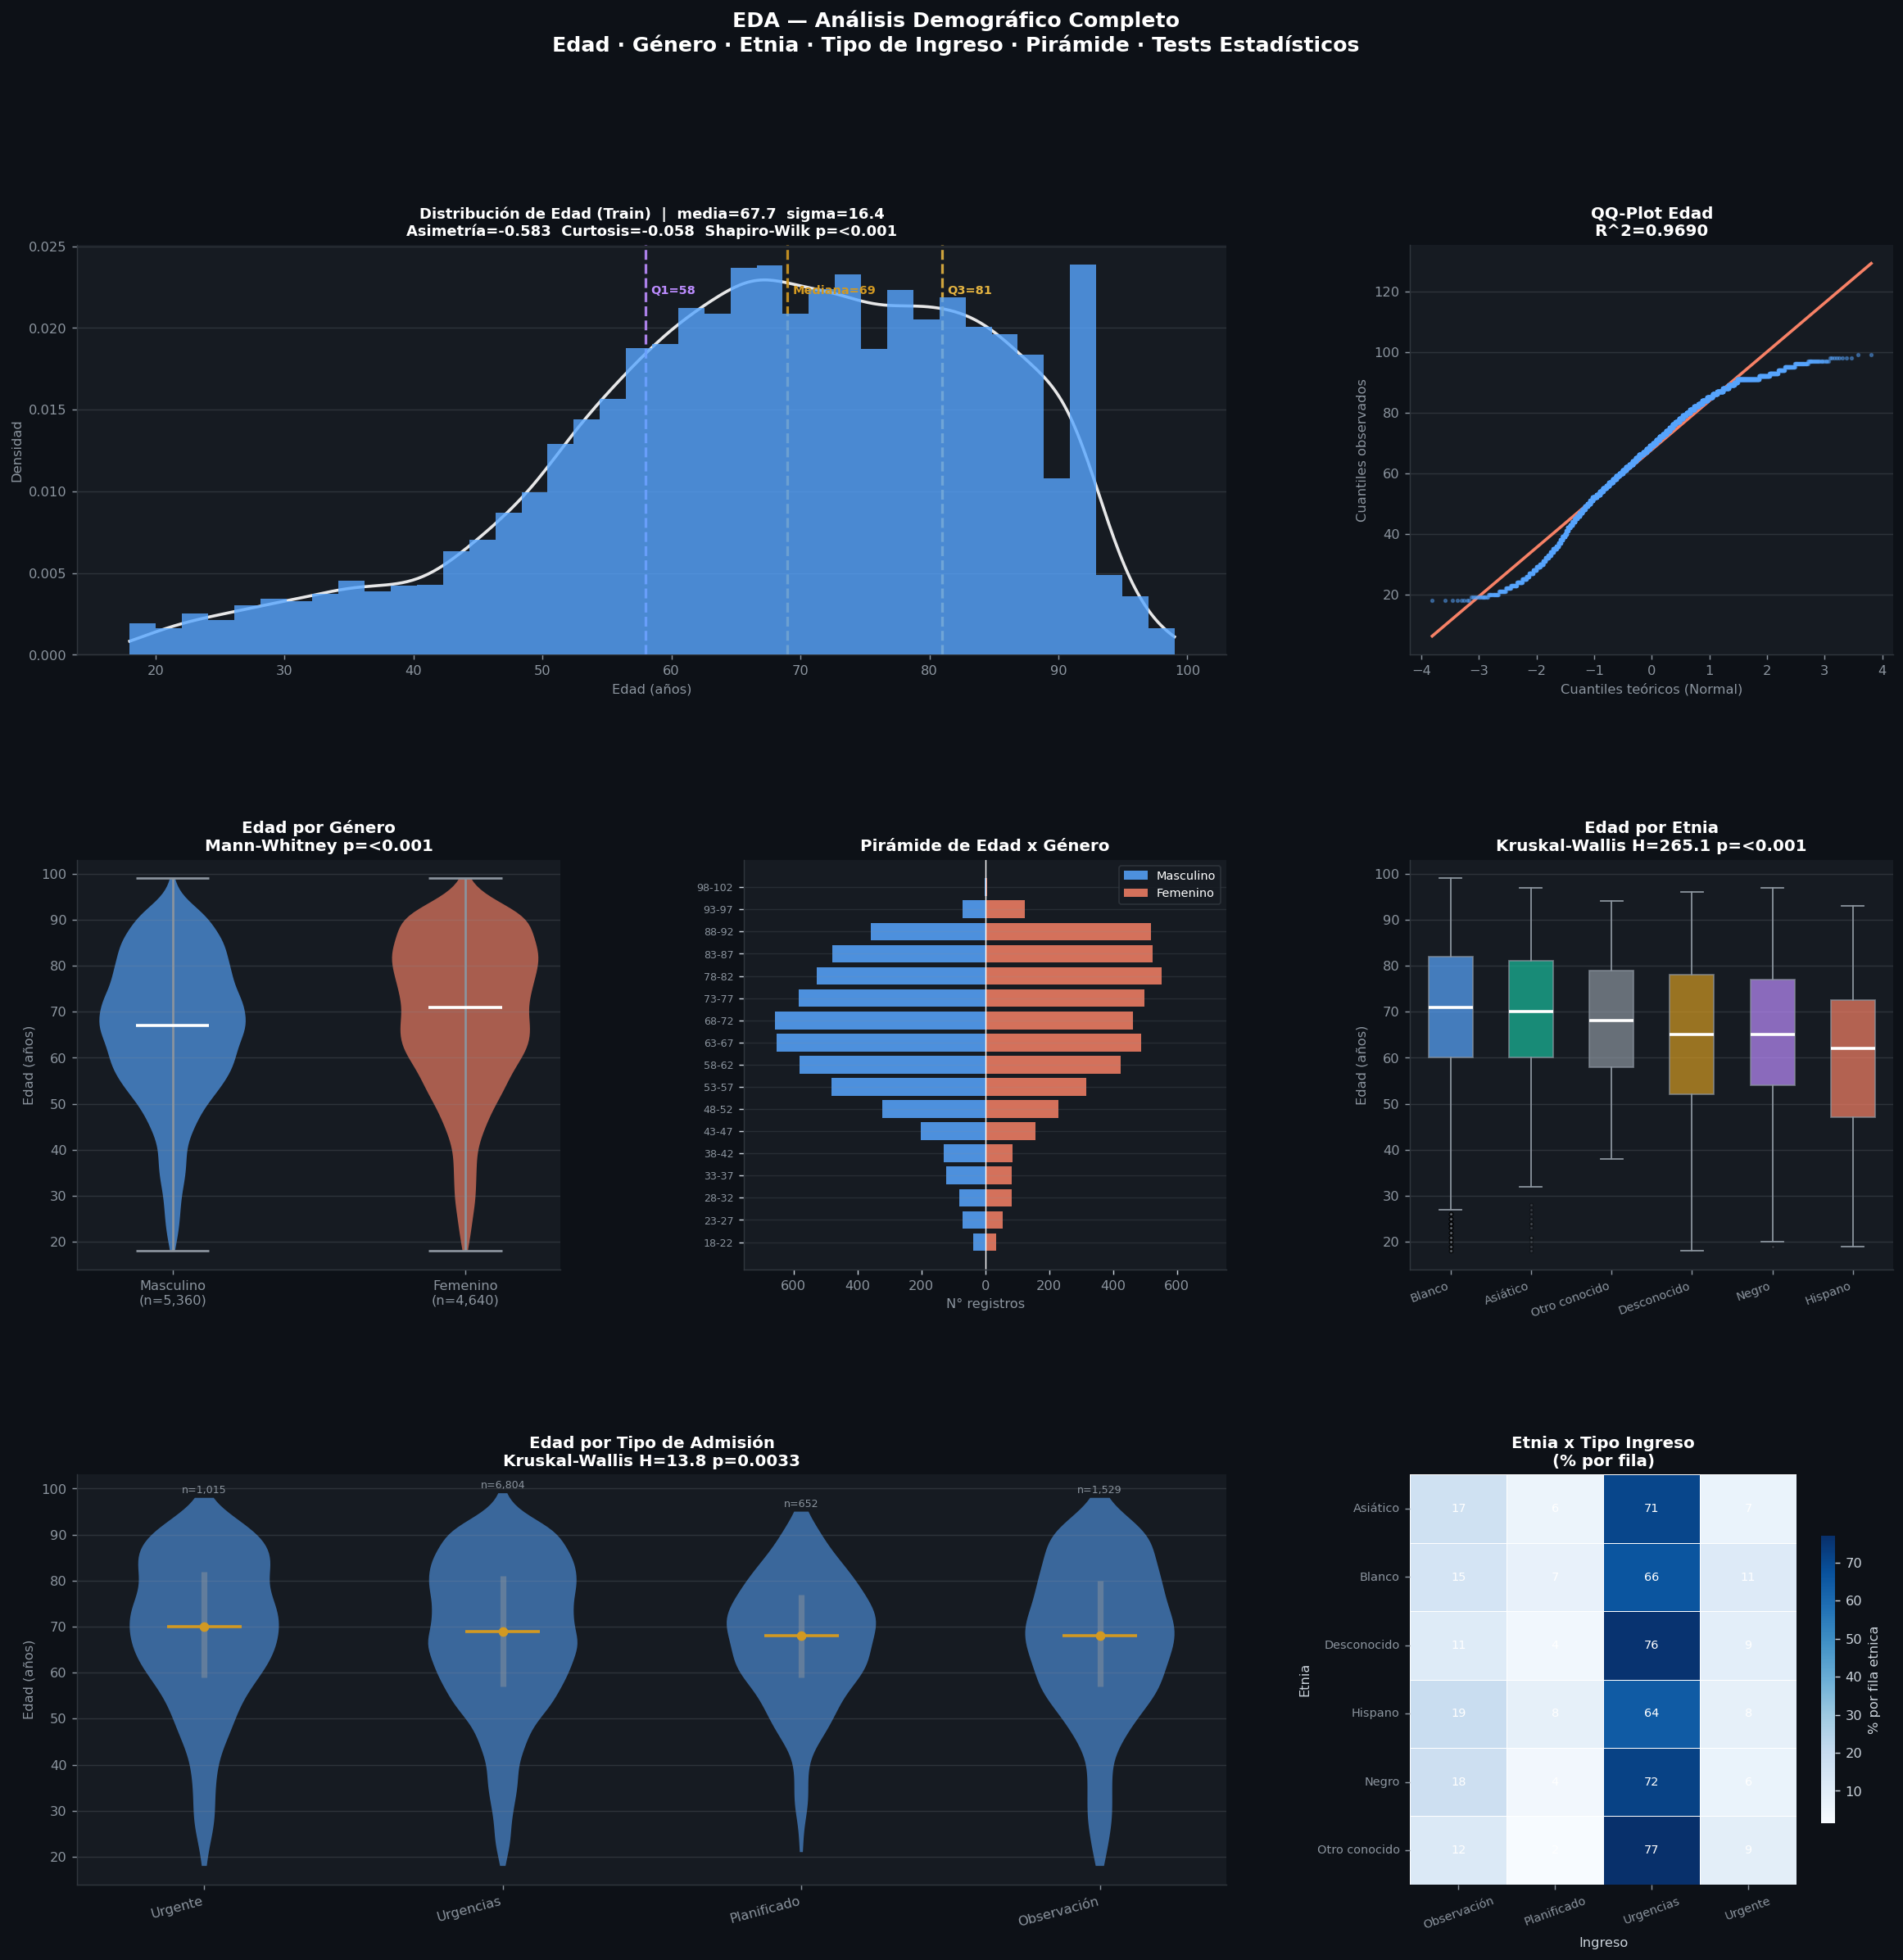

Bloque 2 guardado.


In [4]:
fig = plt.figure(figsize=(22, 20), facecolor=DARK_BG)
fig.suptitle('EDA — Análisis Demográfico Completo\n'
             'Edad · Género · Etnia · Tipo de Ingreso · Pirámide · Tests Estadísticos',
             fontsize=14, fontweight='bold', color='white', y=0.99)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

ages   = train['age'].dropna()
data_m = train.loc[train['gender']==1, 'age'].dropna().values
data_f = train.loc[train['gender']==0, 'age'].dropna().values
_, p_sw  = stats.shapiro(ages.sample(min(500, len(ages)), random_state=42))
sk, ku   = ages.skew(), ages.kurt()
u_mw, p_mw = stats.mannwhitneyu(data_m, data_f, alternative='two-sided')

ax0 = fig.add_subplot(gs[0, 0:2], facecolor=PANEL_BG)
ax0.hist(ages, bins=40, color=C_CYAN, edgecolor='none', alpha=0.8, density=True, zorder=3)
try:
    from scipy.stats import gaussian_kde as gkde
    kde = gkde(ages)
    kx = np.linspace(ages.min(), ages.max(), 400)
    ax0.plot(kx, kde(kx), color='white', lw=2, alpha=0.9)
except Exception: pass
for pct, lbl, col in [(25,'Q1',C_PURPLE),(50,'Mediana',C_ORANGE),(75,'Q3',C_YELLOW)]:
    v = np.percentile(ages, pct)
    ax0.axvline(v, color=col, lw=1.8, linestyle='--', alpha=0.9)
    ax0.text(v+0.4, ax0.get_ylim()[1]*0.88, f'{lbl}={v:.0f}', fontsize=8, color=col, fontweight='bold')
ax0.set_xlabel('Edad (años)', color=C_GREY)
ax0.set_ylabel('Densidad', color=C_GREY)
sw_txt = '<0.001' if p_sw < 0.001 else f'{p_sw:.3f}'
ax0.set_title(f'Distribución de Edad (Train)  |  media={ages.mean():.1f}  sigma={ages.std():.1f}\n'
              f'Asimetría={sk:.3f}  Curtosis={ku:.3f}  Shapiro-Wilk p={sw_txt}', color='white', fontsize=10)
ax0.tick_params(colors=C_GREY)
ax0.yaxis.grid(True, alpha=0.2, color=C_GREY)

ax1 = fig.add_subplot(gs[0, 2], facecolor=PANEL_BG)
(osm, osr), (slope, intercept, r) = stats.probplot(ages, dist='norm')
ax1.scatter(osm, osr, color=C_CYAN, s=4, alpha=0.4, zorder=3)
lx = np.array([osm.min(), osm.max()])
ax1.plot(lx, slope*lx+intercept, color=C_PINK, lw=2)
ax1.set_xlabel('Cuantiles teóricos (Normal)', color=C_GREY)
ax1.set_ylabel('Cuantiles observados', color=C_GREY)
ax1.set_title(f'QQ-Plot Edad\nR^2={r**2:.4f}', color='white')
ax1.tick_params(colors=C_GREY)
ax1.yaxis.grid(True, alpha=0.2, color=C_GREY)

ax2 = fig.add_subplot(gs[1, 0], facecolor=PANEL_BG)
parts = ax2.violinplot([data_m, data_f], positions=[1,2], showmedians=True, showextrema=True)
for pc, c in zip(parts['bodies'], [C_CYAN, C_PINK]): pc.set_facecolor(c); pc.set_alpha(0.65)
parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)
for k in ['cmins','cmaxes','cbars']: parts[k].set_color(C_GREY)
ax2.set_xticks([1,2])
ax2.set_xticklabels([f'Masculino\n(n={len(data_m):,})', f'Femenino\n(n={len(data_f):,})'], color=C_GREY)
ax2.set_ylabel('Edad (años)', color=C_GREY)
mw_txt = '<0.001' if p_mw < 0.001 else f'{p_mw:.4f}'
ax2.set_title(f'Edad por Género\nMann-Whitney p={mw_txt}', color='white')
ax2.yaxis.grid(True, alpha=0.2, color=C_GREY)
ax2.tick_params(colors=C_GREY)

ax3 = fig.add_subplot(gs[1, 1], facecolor=PANEL_BG)
bins  = np.arange(18, 105, 5)
hm, _ = np.histogram(data_m, bins=bins)
hf, _ = np.histogram(data_f, bins=bins)
bin_labs = [f'{int(b)}-{int(b+4)}' for b in bins[:-1]]
y_pos    = np.arange(len(bin_labs))
ax3.barh(y_pos, -hm, color=C_CYAN, alpha=0.85, edgecolor='none', label='Masculino')
ax3.barh(y_pos,  hf, color=C_PINK, alpha=0.85, edgecolor='none', label='Femenino')
ax3.axvline(0, color='white', lw=0.8)
ax3.set_yticks(y_pos)
ax3.set_yticklabels(bin_labs, fontsize=7, color=C_GREY)
ax3.set_xlabel('N° registros', color=C_GREY)
ax3.set_title('Pirámide de Edad x Género', color='white')
mx = max(hm.max(), hf.max())
ax3.set_xlim(-mx*1.15, mx*1.15)
ax3.set_xticklabels([str(abs(int(t))) for t in ax3.get_xticks()], color=C_GREY)
ax3.legend(fontsize=8, labelcolor='white')
ax3.yaxis.grid(True, alpha=0.15, color=C_GREY)

ax4 = fig.add_subplot(gs[1, 2], facecolor=PANEL_BG)
train2 = train.copy()
train2['Etnia'] = train2['race'].map(RACE_MAP).fillna('Otro')
etnia_order = train2.groupby('Etnia')['age'].median().sort_values(ascending=False).index.tolist()
etnia_data  = [train2.loc[train2['Etnia']==e, 'age'].dropna().values for e in etnia_order]
H_kw, p_kw  = stats.kruskal(*[d for d in etnia_data if len(d)>1])
pal_e = [C_CYAN, '#1abc9c', C_GREY, C_ORANGE, C_PURPLE, C_PINK]
bp = ax4.boxplot(etnia_data, patch_artist=True, notch=False, widths=0.55,
                  medianprops={'color':'white','linewidth':2},
                  flierprops={'markersize':2,'alpha':0.3,'markerfacecolor':C_GREY},
                  whiskerprops={'color':C_GREY}, capprops={'color':C_GREY},
                  boxprops={'edgecolor':C_GREY})
for patch, c in zip(bp['boxes'], pal_e[:len(etnia_order)]): patch.set_facecolor(c); patch.set_alpha(0.7)
ax4.set_xticks(range(1, len(etnia_order)+1))
ax4.set_xticklabels(etnia_order, rotation=20, ha='right', fontsize=8, color=C_GREY)
ax4.set_ylabel('Edad (años)', color=C_GREY)
kw_txt = '<0.001' if p_kw < 0.001 else f'{p_kw:.4f}'
ax4.set_title(f'Edad por Etnia\nKruskal-Wallis H={H_kw:.1f} p={kw_txt}', color='white')
ax4.yaxis.grid(True, alpha=0.2, color=C_GREY)
ax4.tick_params(colors=C_GREY)

ax5 = fig.add_subplot(gs[2, 0:2], facecolor=PANEL_BG)
train2['Ingreso'] = train2['admission_type'].map(ADM_TYPE_MAP).fillna(train2['admission_type'])
adm_order = train2.groupby('Ingreso')['age'].median().sort_values(ascending=False).index.tolist()
adm_data  = [train2.loc[train2['Ingreso']==g, 'age'].dropna().values for g in adm_order]
H_adm, p_adm = stats.kruskal(*[d for d in adm_data if len(d)>1])
parts2 = ax5.violinplot(adm_data, positions=range(1, len(adm_order)+1), showmedians=True, showextrema=False)
for pc in parts2['bodies']: pc.set_facecolor(C_CYAN); pc.set_alpha(0.55)
parts2['cmedians'].set_color(C_ORANGE); parts2['cmedians'].set_linewidth(2)
for i, grp in enumerate(adm_data):
    if len(grp) == 0: continue
    q1, md_, q3 = np.percentile(grp, [25,50,75])
    ax5.vlines(i+1, q1, q3, color=C_GREY, lw=4, alpha=0.5)
    ax5.scatter(i+1, md_, s=30, color=C_ORANGE, zorder=5)
    ax5.text(i+1, grp.max()+0.5, f'n={len(grp):,}', ha='center', va='bottom', fontsize=7, color=C_GREY)
ax5.set_xticks(range(1, len(adm_order)+1))
ax5.set_xticklabels(adm_order, rotation=15, ha='right', fontsize=9, color=C_GREY)
ax5.set_ylabel('Edad (años)', color=C_GREY)
adm_txt = '<0.001' if p_adm < 0.001 else f'{p_adm:.4f}'
ax5.set_title(f'Edad por Tipo de Admisión\nKruskal-Wallis H={H_adm:.1f} p={adm_txt}', color='white')
ax5.yaxis.grid(True, alpha=0.2, color=C_GREY)
ax5.tick_params(colors=C_GREY)

ax6 = fig.add_subplot(gs[2, 2], facecolor=PANEL_BG)
ct = pd.crosstab(train2['Etnia'], train2['Ingreso'])
ct_pct = ct.div(ct.sum(axis=1), axis=0)*100
sns.heatmap(ct_pct, annot=True, fmt='.0f', cmap='Blues', ax=ax6, linewidths=0.4,
            cbar_kws={'shrink':0.7, 'label':'% por fila etnica'},
            annot_kws={'size':8, 'color':'white'})
ax6.set_title('Etnia x Tipo Ingreso\n(% por fila)', color='white')
ax6.tick_params(axis='x', rotation=20, labelsize=8, colors=C_GREY)
ax6.tick_params(axis='y', rotation=0, labelsize=8, colors=C_GREY)

plt.savefig(out('block2_demographics.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 2 guardado.")


---
## Bloque 3 — Análisis de Etiquetas Diagnósticas

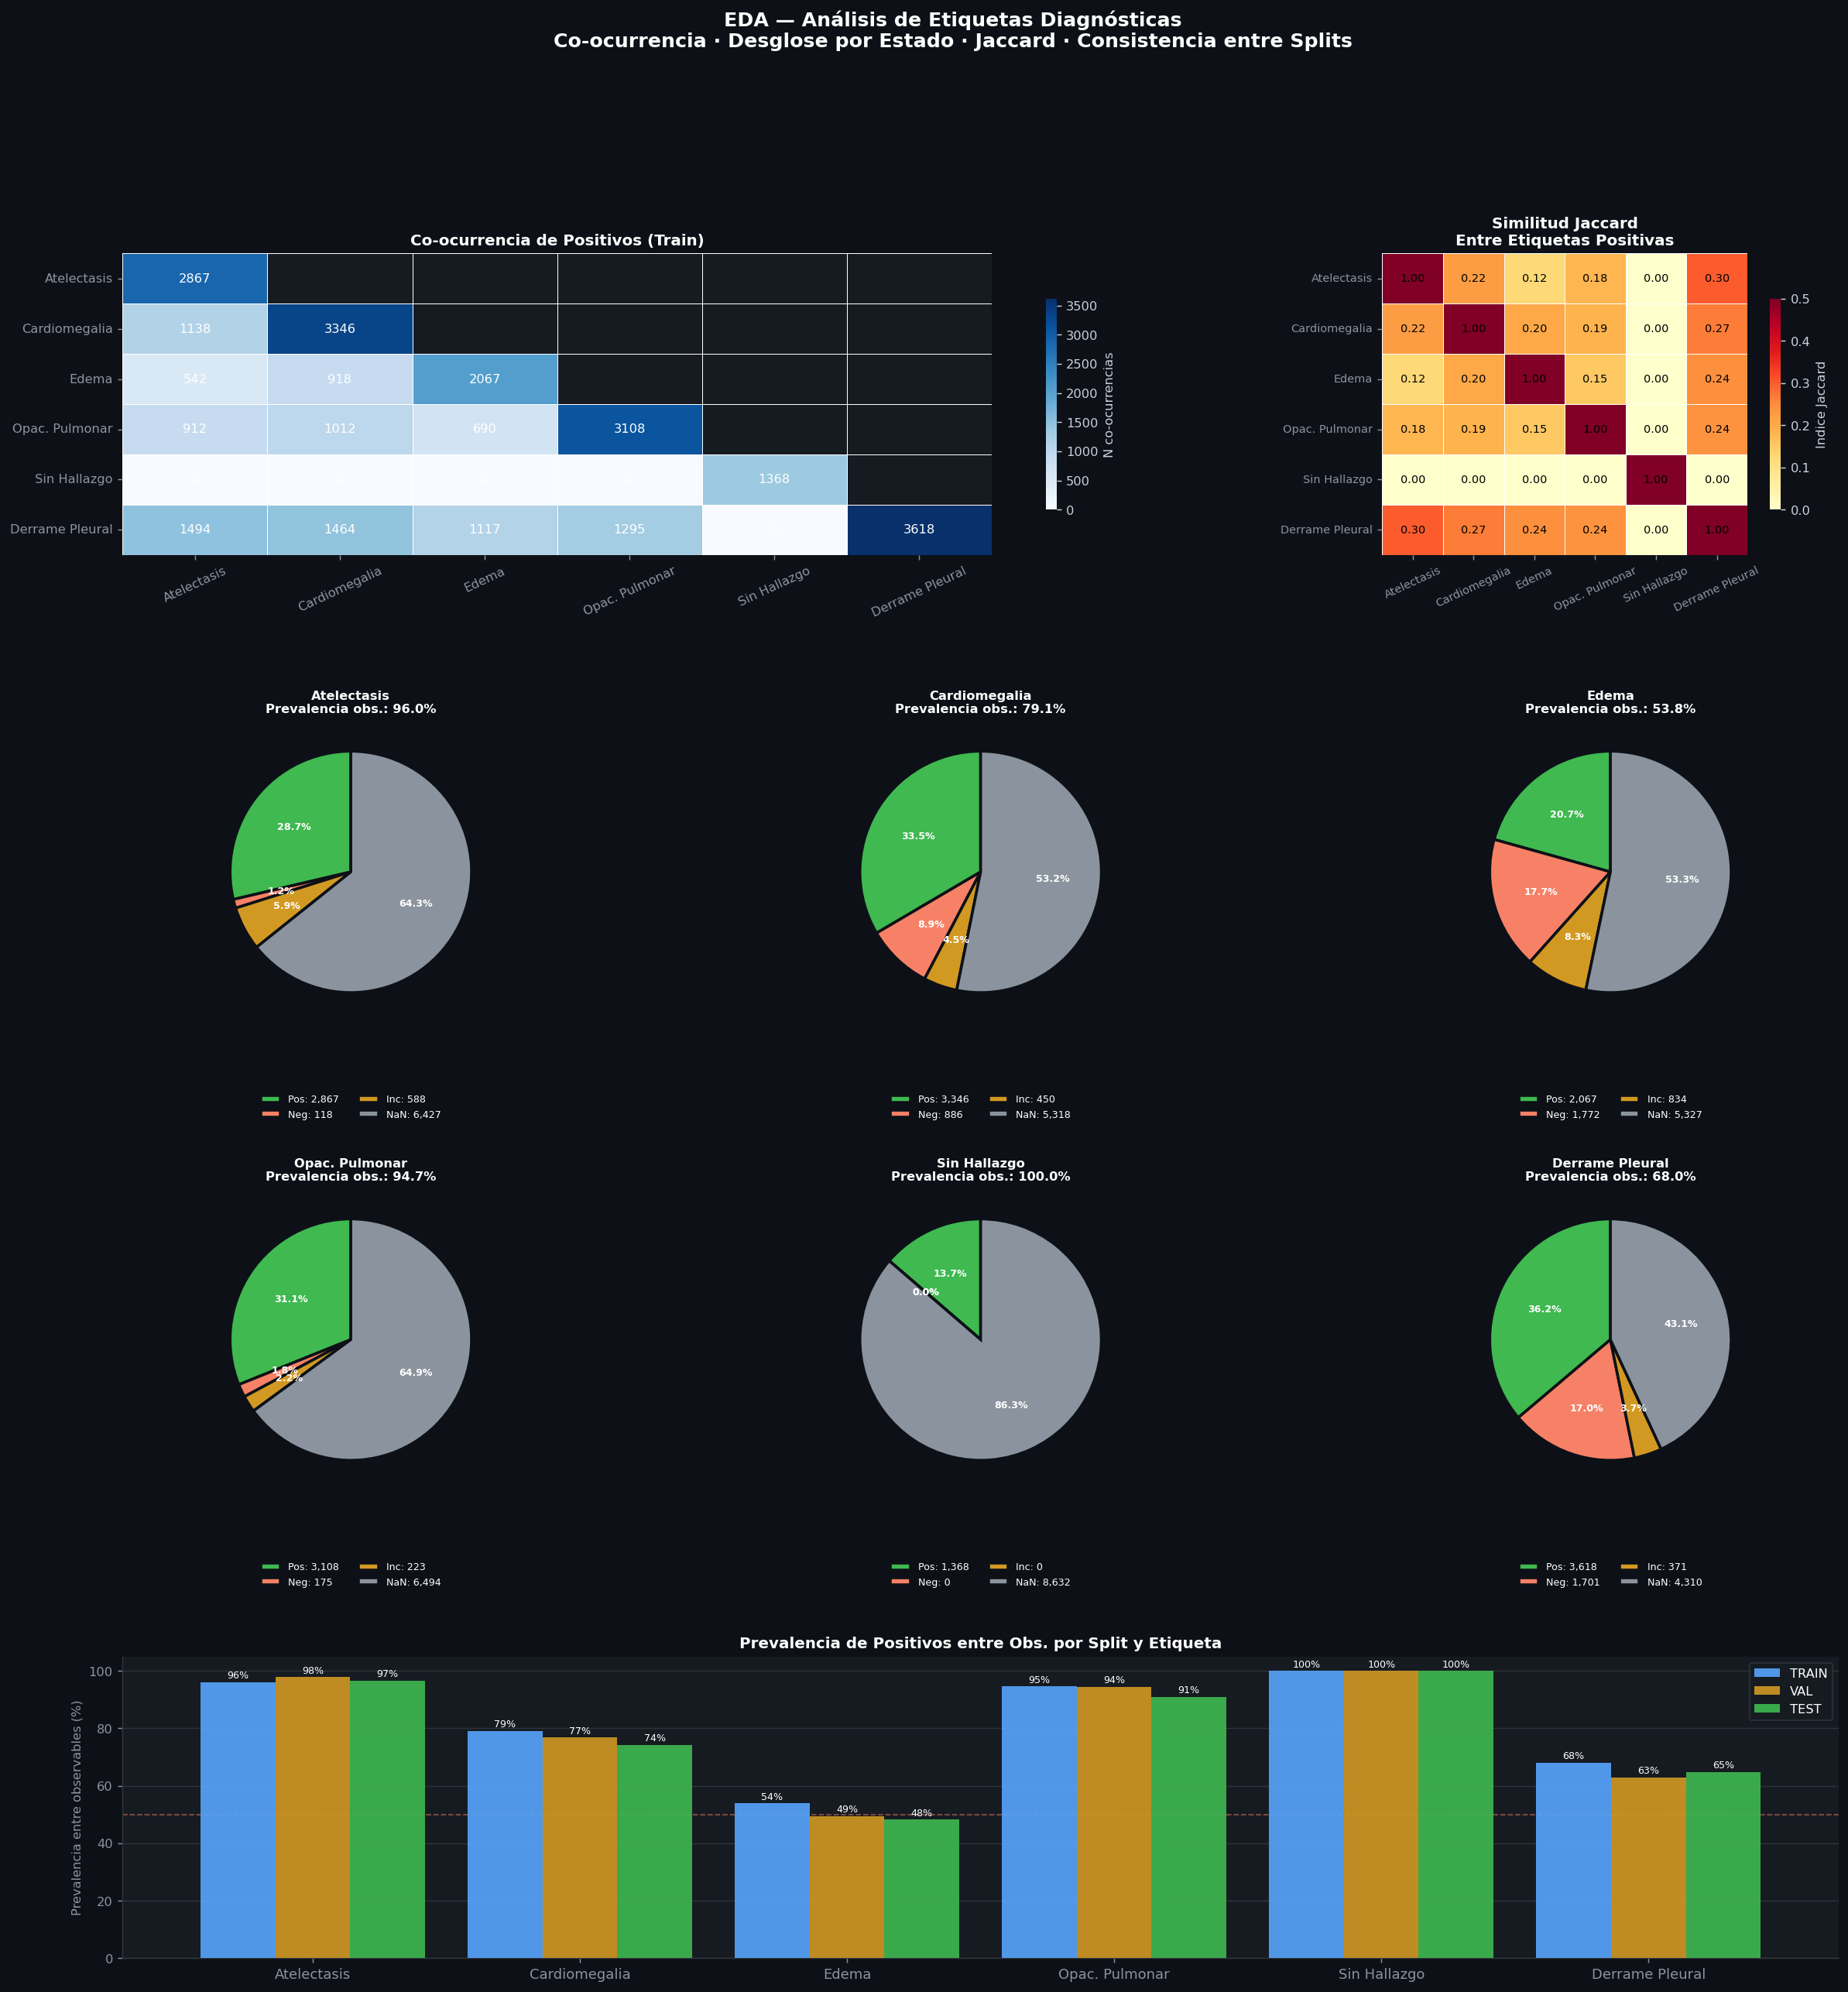

Bloque 3 guardado.


In [5]:
fig = plt.figure(figsize=(22, 22), facecolor=DARK_BG)
fig.suptitle('EDA — Análisis de Etiquetas Diagnósticas\n'
             'Co-ocurrencia · Desglose por Estado · Jaccard · Consistencia entre Splits',
             fontsize=14, fontweight='bold', color='white', y=0.99)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.38)

ax0 = fig.add_subplot(gs[0, 0:2], facecolor=PANEL_BG)
pos_mat = train[LABEL_COLS].apply(lambda x: (x==1).astype(float))
cooc = pos_mat.T.dot(pos_mat).astype(int)
mask_up = np.triu(np.ones_like(cooc, dtype=bool), k=1)
sns.heatmap(cooc, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_DISPLAY, yticklabels=LABEL_DISPLAY,
            mask=mask_up, ax=ax0, linewidths=0.5,
            cbar_kws={'shrink':0.7, 'label':'N co-ocurrencias'},
            annot_kws={'size':9, 'color':'white'})
ax0.set_title('Co-ocurrencia de Positivos (Train)', color='white')
ax0.tick_params(axis='x', rotation=25, labelsize=9, colors=C_GREY)
ax0.tick_params(axis='y', rotation=0, labelsize=9, colors=C_GREY)

ax1 = fig.add_subplot(gs[0, 2], facecolor=PANEL_BG)
jacc = pd.DataFrame(0.0, index=LABEL_DISPLAY, columns=LABEL_DISPLAY)
for i, ci in enumerate(LABEL_COLS):
    for j, cj in enumerate(LABEL_COLS):
        a = (train[ci]==1).astype(int); b = (train[cj]==1).astype(int)
        inter = (a & b).sum(); union = (a | b).sum()
        jacc.iloc[i,j] = inter/union if union>0 else 0
sns.heatmap(jacc, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax1, linewidths=0.5, vmin=0, vmax=0.5,
            cbar_kws={'shrink':0.7, 'label':'Indice Jaccard'}, annot_kws={'size':8, 'color':'black'})
ax1.set_title('Similitud Jaccard\nEntre Etiquetas Positivas', color='white')
ax1.tick_params(axis='x', rotation=25, labelsize=8, colors=C_GREY)
ax1.tick_params(axis='y', rotation=0, labelsize=8, colors=C_GREY)

for idx2, (col, disp) in enumerate(zip(LABEL_COLS, LABEL_DISPLAY)):
    row_ = 1 + idx2 // 3; col_ = idx2 % 3
    ax = fig.add_subplot(gs[row_, col_], facecolor=PANEL_BG)
    s = train[col]
    counts = {1: int((s==1).sum()), 0: int((s==0).sum()), -1: int((s==-1).sum()), 'NaN': int(s.isna().sum())}
    vals   = [counts[k] for k in [1, 0, -1, 'NaN']]
    colors_ = [C_GREEN, C_PINK, C_ORANGE, C_GREY]
    lbls   = [f'Pos: {counts[1]:,}', f'Neg: {counts[0]:,}', f'Inc: {counts[-1]:,}', f'NaN: {counts["NaN"]:,}']
    wedges, _, autotexts = ax.pie(vals, colors=colors_, autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': DARK_BG, 'linewidth':2}, textprops={'color':'white', 'fontsize':7})
    for at in autotexts: at.set_color('white'); at.set_fontsize(7); at.set_fontweight('bold')
    obs = counts[1]+counts[0]; prev = counts[1]/obs*100 if obs>0 else 0
    ax.set_title(f'{disp}\nPrevalencia obs.: {prev:.1f}%', color='white', fontsize=9)
    ax.legend(wedges, lbls, loc='lower center', bbox_to_anchor=(0.5,-0.35),
              fontsize=7, labelcolor='white', frameon=False, ncol=2)

ax_prev = fig.add_subplot(gs[3, 0:3], facecolor=PANEL_BG)
x2 = np.arange(len(LABEL_DISPLAY)); width2 = 0.28
for i, (sp, col2) in enumerate(SPLIT_COLORS.items()):
    df_sp = dfs[sp]; prev_list = []
    for lc in LABEL_COLS:
        s2 = df_sp[lc]; obs = int(((s2==0)|(s2==1)).sum()); pos = int((s2==1).sum())
        prev_list.append(pos/obs*100 if obs>0 else 0)
    bars_ = ax_prev.bar(x2 + i*width2, prev_list, width2, label=sp.upper(), color=col2, edgecolor='none', alpha=0.9, zorder=3)
    for bar_, v_ in zip(bars_, prev_list):
        ax_prev.text(bar_.get_x()+bar_.get_width()/2, v_+0.5, f'{v_:.0f}%',
                     ha='center', va='bottom', fontsize=7, color='white')
ax_prev.set_xticks(x2 + width2)
ax_prev.set_xticklabels(LABEL_DISPLAY, fontsize=10, color=C_GREY)
ax_prev.set_ylabel('Prevalencia entre observables (%)', color=C_GREY)
ax_prev.set_title('Prevalencia de Positivos entre Obs. por Split y Etiqueta', color='white', fontsize=11)
ax_prev.legend(fontsize=9, labelcolor='white')
ax_prev.yaxis.grid(True, alpha=0.2, color=C_GREY)
ax_prev.axhline(50, color=C_PINK, lw=1, linestyle='--', alpha=0.5)
ax_prev.tick_params(colors=C_GREY)

plt.savefig(out('block3_labels.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 3 guardado.")


---
## Bloque 4 — Analíticas Sanguíneas: Missingness, Raw vs Percentil y Correlaciones

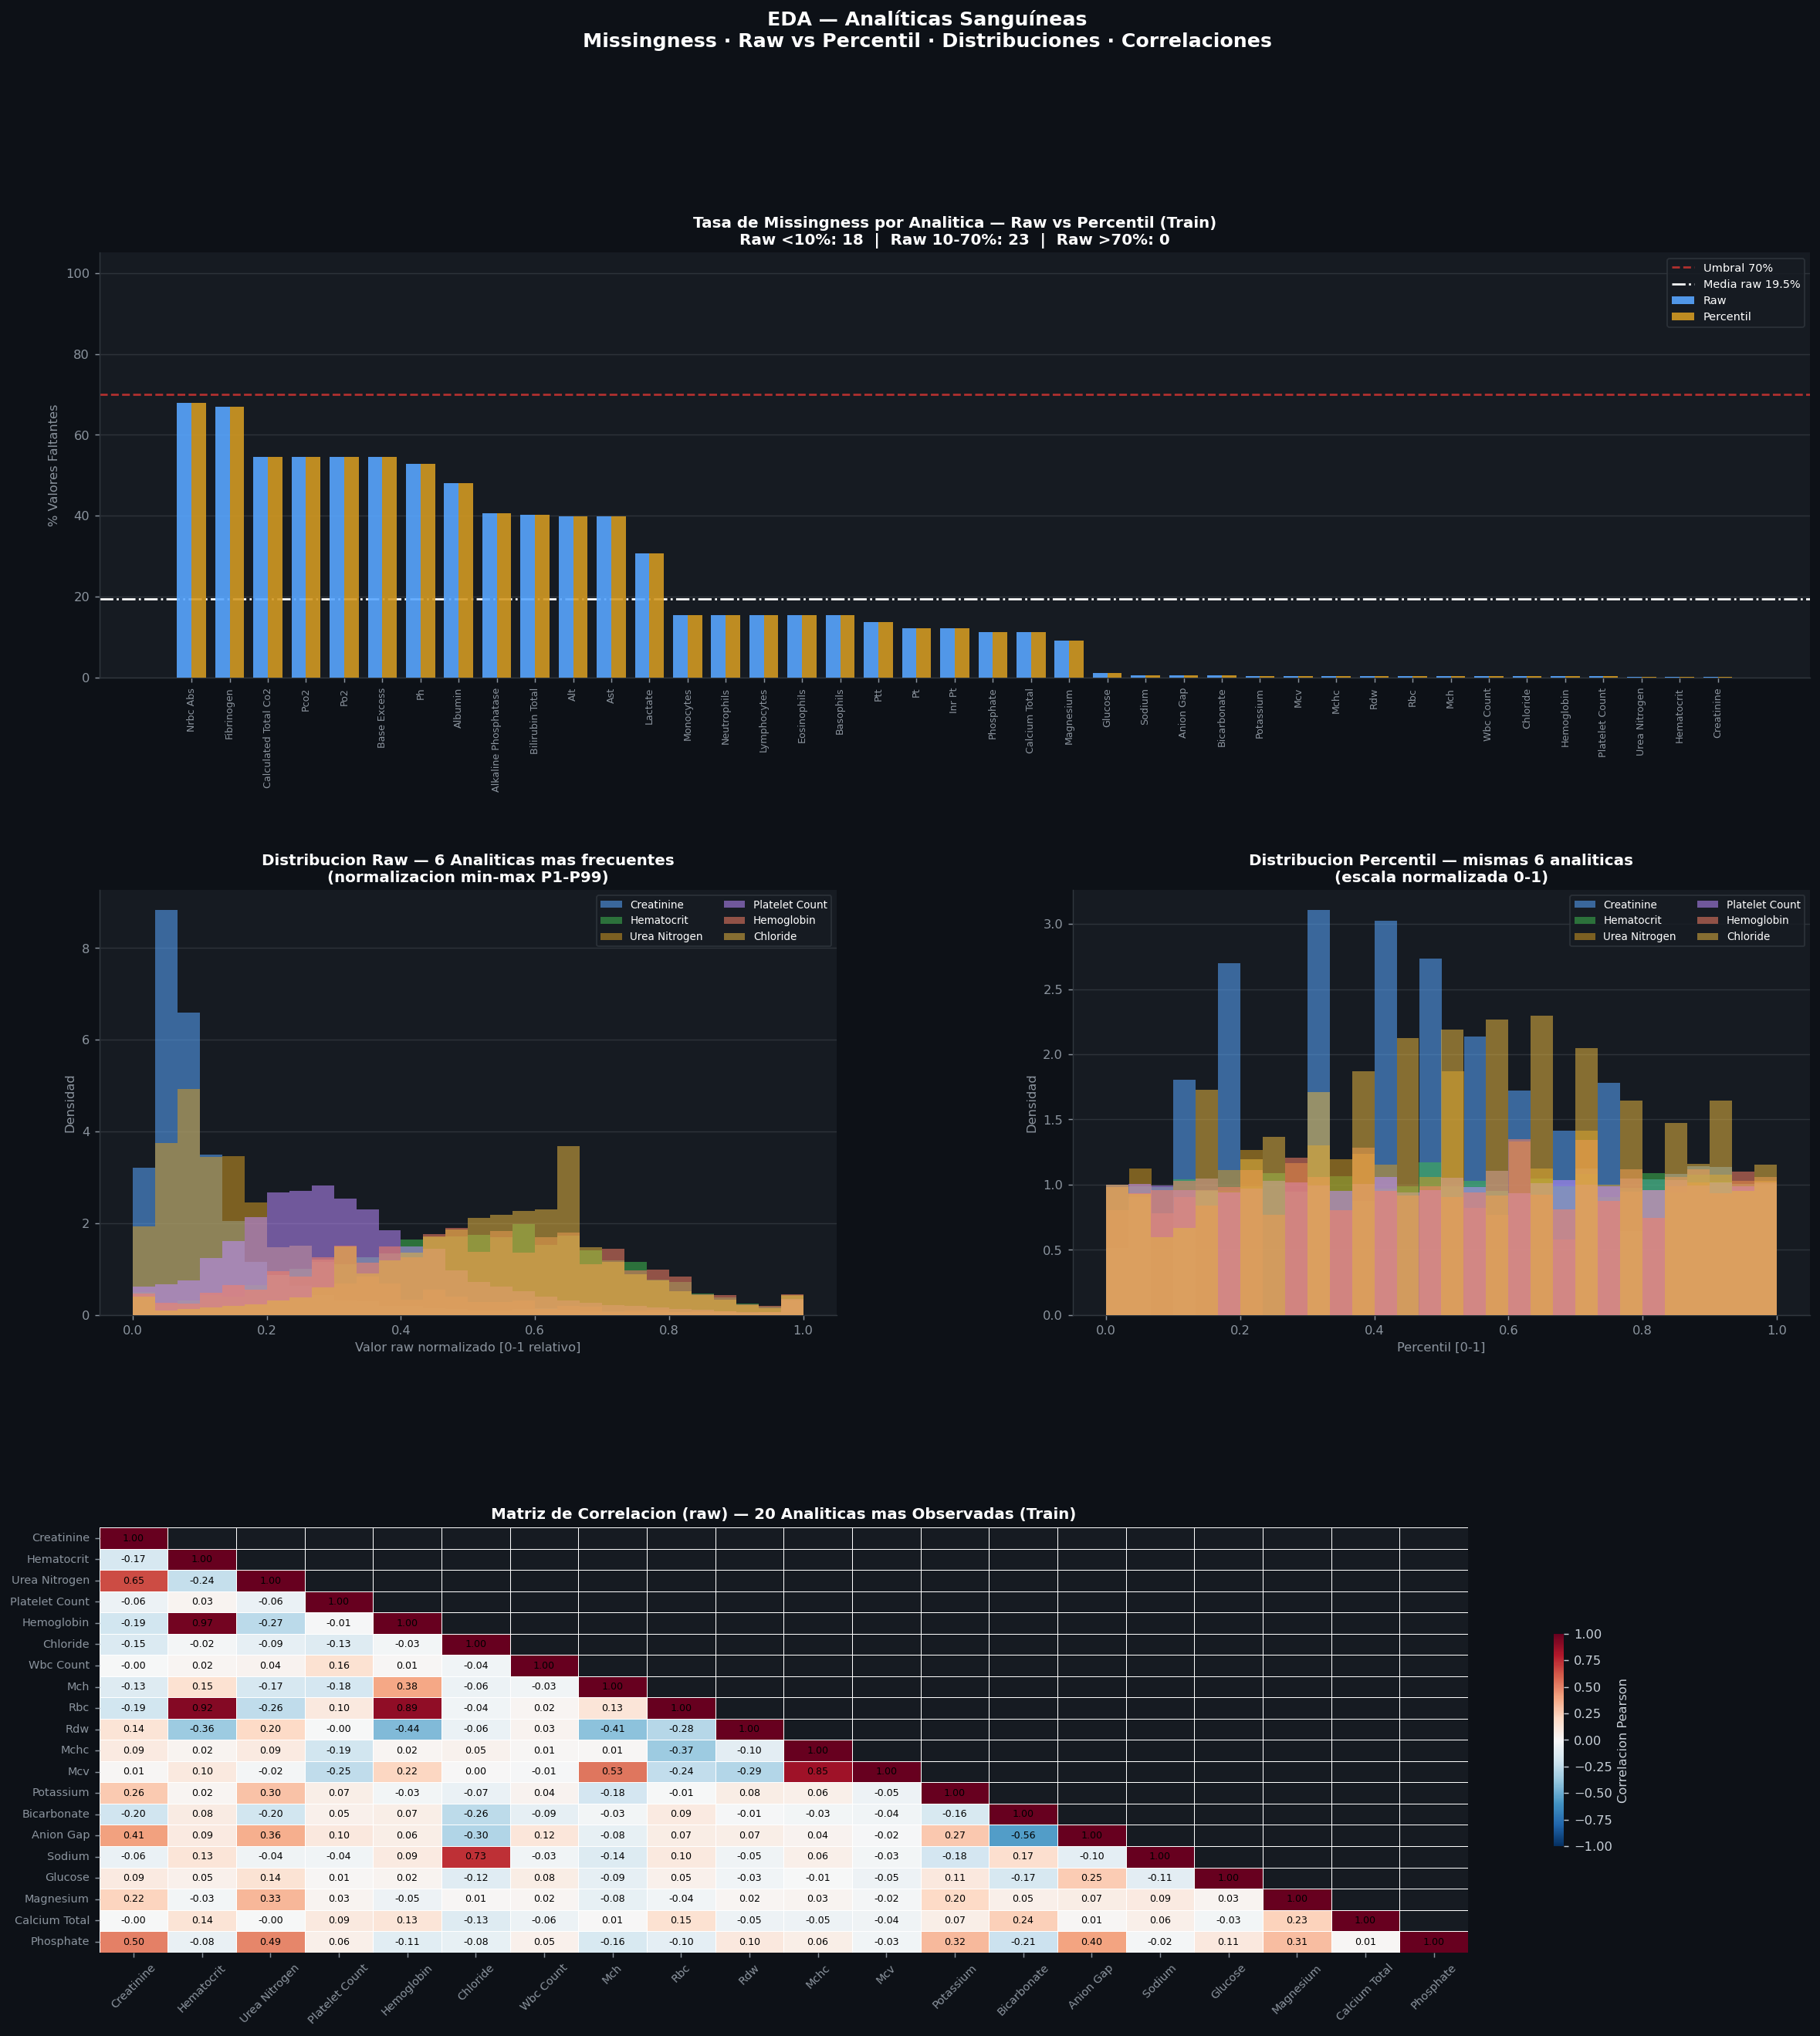

Bloque 4 guardado.


In [6]:
miss_raw    = train[LAB_RAW_COLS].isnull().mean().values
miss_pctile = train[LAB_PCTILE_COLS].isnull().mean().values
raw_arr     = train[LAB_RAW_COLS].values.astype(float)
pct_arr     = train[LAB_PCTILE_COLS].values.astype(float)

fig = plt.figure(figsize=(22, 22), facecolor=DARK_BG)
fig.suptitle('EDA — Analíticas Sanguíneas\nMissingness · Raw vs Percentil · Distribuciones · Correlaciones',
             fontsize=14, fontweight='bold', color='white', y=0.99)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.32)

ax0 = fig.add_subplot(gs[0, 0:2], facecolor=PANEL_BG)
sorted_idx = np.argsort(miss_raw)[::-1]
x_bar = np.arange(len(LAB_RAW_COLS)); w_bar = 0.38
ax0.bar(x_bar - w_bar/2, miss_raw[sorted_idx]*100, w_bar, color=C_CYAN, edgecolor='none', alpha=0.9, zorder=3, label='Raw')
ax0.bar(x_bar + w_bar/2, miss_pctile[sorted_idx]*100, w_bar, color=C_ORANGE, edgecolor='none', alpha=0.9, zorder=3, label='Percentil')
ax0.axhline(70, color=C_RED, linestyle='--', lw=1.5, alpha=0.8, label='Umbral 70%')
ax0.axhline(miss_raw.mean()*100, color='white', linestyle='-.', lw=1.5, label=f'Media raw {miss_raw.mean()*100:.1f}%')
ax0.set_xticks(x_bar)
ax0.set_xticklabels([LAB_RAW_DISP[sorted_idx[i]] for i in range(len(LAB_RAW_COLS))], rotation=90, fontsize=7, color=C_GREY)
ax0.set_ylabel('% Valores Faltantes', color=C_GREY)
ax0.set_ylim(0, 105)
n_low = (miss_raw<0.1).sum(); n_mid = ((miss_raw>=0.1)&(miss_raw<0.7)).sum(); n_hi = (miss_raw>=0.7).sum()
ax0.set_title(f'Tasa de Missingness por Analitica — Raw vs Percentil (Train)\nRaw <10%: {n_low}  |  Raw 10-70%: {n_mid}  |  Raw >70%: {n_hi}', color='white')
ax0.legend(fontsize=8, labelcolor='white', loc='upper right')
ax0.tick_params(colors=C_GREY)
ax0.yaxis.grid(True, alpha=0.2, color=C_GREY)

ax1 = fig.add_subplot(gs[1, 0], facecolor=PANEL_BG)
low6_idx = np.argsort(miss_raw)[:6]
pal_low6 = [C_CYAN, C_GREEN, C_ORANGE, C_PURPLE, C_PINK, C_YELLOW]
for i, idx in enumerate(low6_idx):
    obs = raw_arr[~np.isnan(raw_arr[:,idx]), idx]
    if len(obs) == 0: continue
    obs_n = (obs - np.nanpercentile(obs, 1)) / (np.nanpercentile(obs, 99) - np.nanpercentile(obs, 1) + 1e-9)
    obs_n = np.clip(obs_n, 0, 1)
    ax1.hist(obs_n, bins=30, alpha=0.55, color=pal_low6[i], edgecolor='none', density=True, label=LAB_RAW_DISP[idx], zorder=3)
ax1.set_xlabel('Valor raw normalizado [0-1 relativo]', color=C_GREY)
ax1.set_ylabel('Densidad', color=C_GREY)
ax1.set_title('Distribucion Raw — 6 Analiticas mas frecuentes\n(normalizacion min-max P1-P99)', color='white')
ax1.legend(fontsize=7.5, labelcolor='white', ncol=2)
ax1.tick_params(colors=C_GREY)
ax1.yaxis.grid(True, alpha=0.2, color=C_GREY)

ax2 = fig.add_subplot(gs[1, 1], facecolor=PANEL_BG)
for i, idx in enumerate(low6_idx):
    obs_p = pct_arr[~np.isnan(pct_arr[:,idx]), idx]
    if len(obs_p) == 0: continue
    ax2.hist(obs_p, bins=30, alpha=0.55, color=pal_low6[i], edgecolor='none', density=True, label=LAB_PCTILE_DISP[idx], zorder=3)
ax2.set_xlabel('Percentil [0-1]', color=C_GREY)
ax2.set_ylabel('Densidad', color=C_GREY)
ax2.set_title('Distribucion Percentil — mismas 6 analiticas\n(escala normalizada 0-1)', color='white')
ax2.legend(fontsize=7.5, labelcolor='white', ncol=2)
ax2.tick_params(colors=C_GREY)
ax2.yaxis.grid(True, alpha=0.2, color=C_GREY)

ax3 = fig.add_subplot(gs[2, 0:2], facecolor=PANEL_BG)
top20_idx   = np.argsort(miss_raw)[:20]
top20_names = [LAB_RAW_DISP[i] for i in top20_idx]
df_top20_raw = pd.DataFrame(raw_arr[:, top20_idx], columns=top20_names)
corr20 = df_top20_raw.corr()
mask20 = np.triu(np.ones_like(corr20, dtype=bool), k=1)
sns.heatmap(corr20, mask=mask20, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.3, ax=ax3,
            cbar_kws={'shrink':0.5, 'label':'Correlacion Pearson'},
            annot_kws={'size':7, 'color':'black'},
            xticklabels=top20_names, yticklabels=top20_names)
ax3.set_title('Matriz de Correlacion (raw) — 20 Analiticas mas Observadas (Train)', color='white', fontsize=11)
ax3.tick_params(axis='x', rotation=45, labelsize=8, colors=C_GREY)
ax3.tick_params(axis='y', rotation=0, labelsize=8, colors=C_GREY)

plt.savefig(out('block4_labs.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 4 guardado.")


---
## Bloque 5 — Analíticas vs Etiquetas: Boxplots y Tests Estadísticos

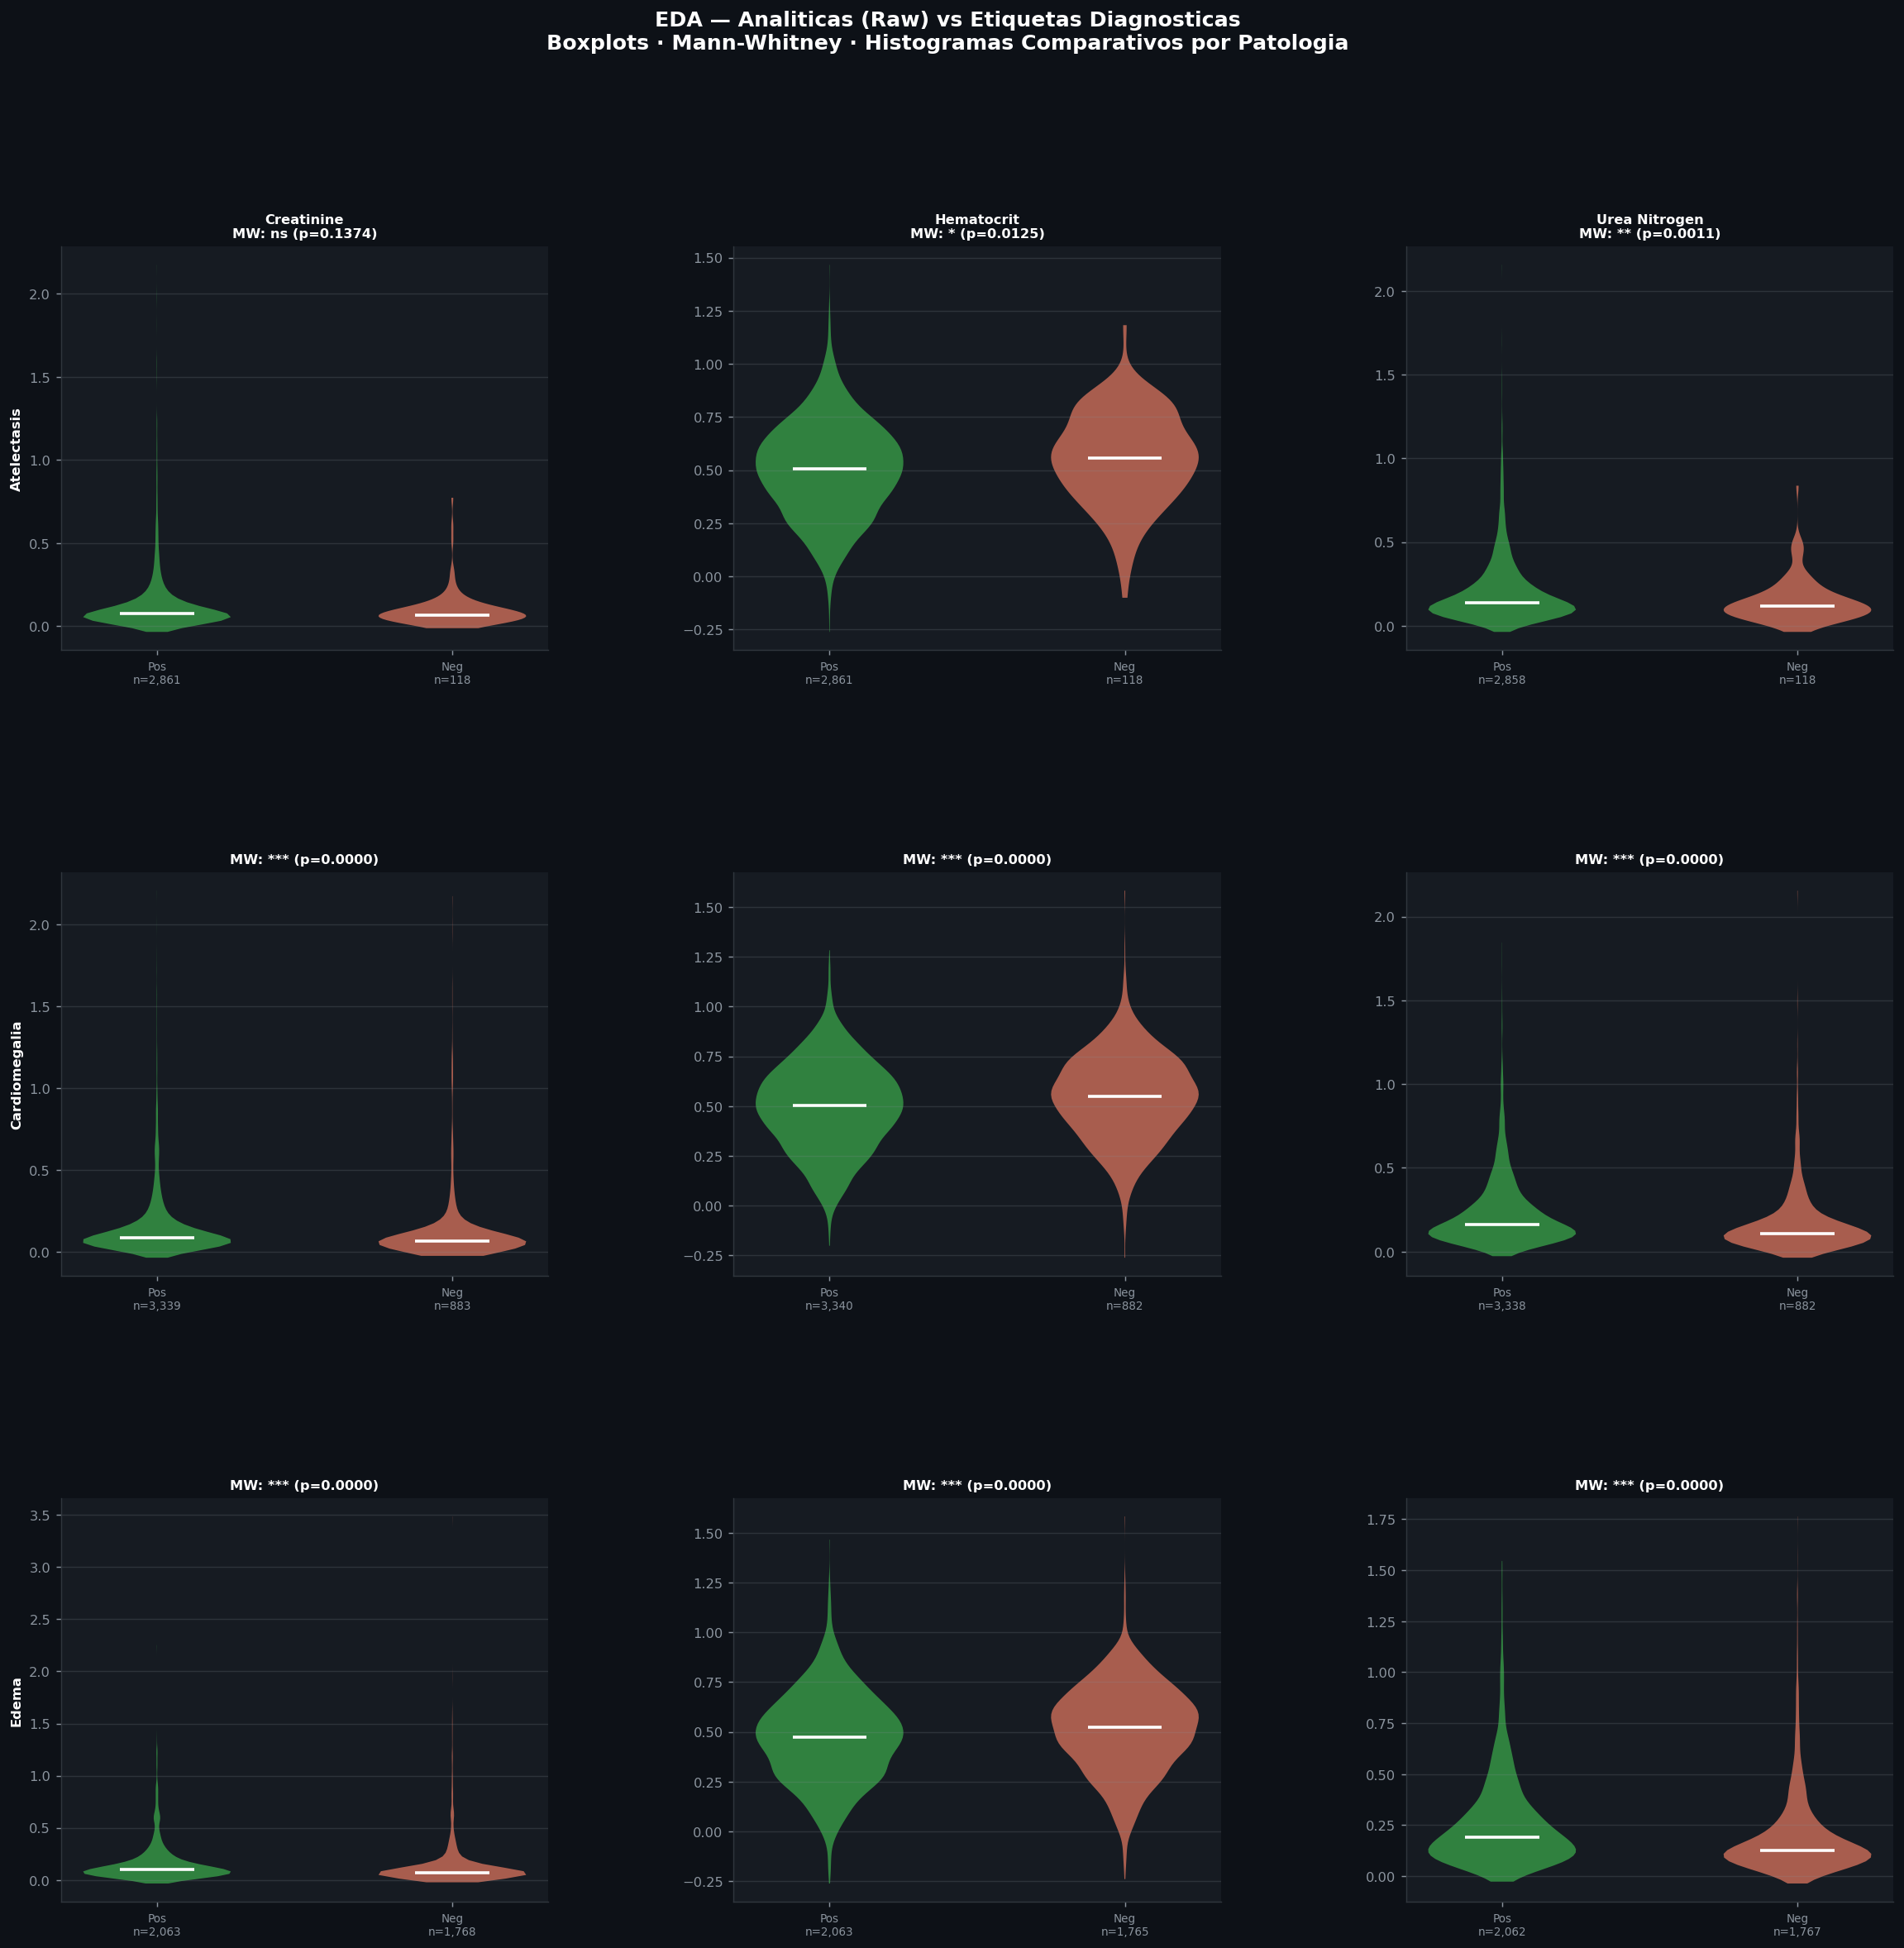

Bloque 5 guardado.


In [7]:
fig = plt.figure(figsize=(22, 20), facecolor=DARK_BG)
fig.suptitle('EDA — Analiticas (Raw) vs Etiquetas Diagnosticas\n'
             'Boxplots · Mann-Whitney · Histogramas Comparativos por Patologia',
             fontsize=14, fontweight='bold', color='white', y=0.99)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

raw_arr  = train[LAB_RAW_COLS].values.astype(float)
miss_raw = train[LAB_RAW_COLS].isnull().mean().values
top3_idx = np.argsort(miss_raw)[:3]

for row_i, (lc, ld) in enumerate(zip(LABEL_COLS[:3], LABEL_DISPLAY[:3])):
    for col_i, lab_idx in enumerate(top3_idx):
        ax = fig.add_subplot(gs[row_i, col_i], facecolor=PANEL_BG)
        obs_raw_col = raw_arr[:, lab_idx]
        p1, p99 = np.nanpercentile(obs_raw_col, [1,99])
        obs_n = (obs_raw_col - p1) / (p99 - p1 + 1e-9)
        grp_pos = obs_n[(train[lc]==1).values]; grp_pos = grp_pos[~np.isnan(grp_pos)]
        grp_neg = obs_n[(train[lc]==0).values]; grp_neg = grp_neg[~np.isnan(grp_neg)]
        data_vl, colors_vl, labs_vl = [], [], []
        if len(grp_pos) >= 5: data_vl.append(grp_pos); colors_vl.append(C_GREEN); labs_vl.append(f'Pos\nn={len(grp_pos):,}')
        if len(grp_neg) >= 5: data_vl.append(grp_neg); colors_vl.append(C_PINK); labs_vl.append(f'Neg\nn={len(grp_neg):,}')
        if data_vl:
            parts_v = ax.violinplot(data_vl, showmedians=True, showextrema=False)
            for pc, c in zip(parts_v['bodies'], colors_vl): pc.set_facecolor(c); pc.set_alpha(0.65)
            parts_v['cmedians'].set_color('white'); parts_v['cmedians'].set_linewidth(2)
        ax.set_xticks(range(1, len(labs_vl)+1))
        ax.set_xticklabels(labs_vl, fontsize=7.5, color=C_GREY)
        sig = ''
        if len(grp_pos) >= 5 and len(grp_neg) >= 5:
            _, p_mw = stats.mannwhitneyu(grp_pos, grp_neg, alternative='two-sided')
            sig = f'MW: {sig_stars(p_mw)} (p={p_mw:.4f})'
        ax.set_title(f'{LAB_RAW_DISP[lab_idx]}\n{sig}' if row_i == 0 else sig, color='white', fontsize=9)
        if col_i == 0: ax.set_ylabel(ld, color='white', fontsize=9, fontweight='bold')
        ax.yaxis.grid(True, alpha=0.2, color=C_GREY)
        ax.tick_params(colors=C_GREY)

plt.savefig(out('block5_labs_vs_labels.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 5 guardado.")


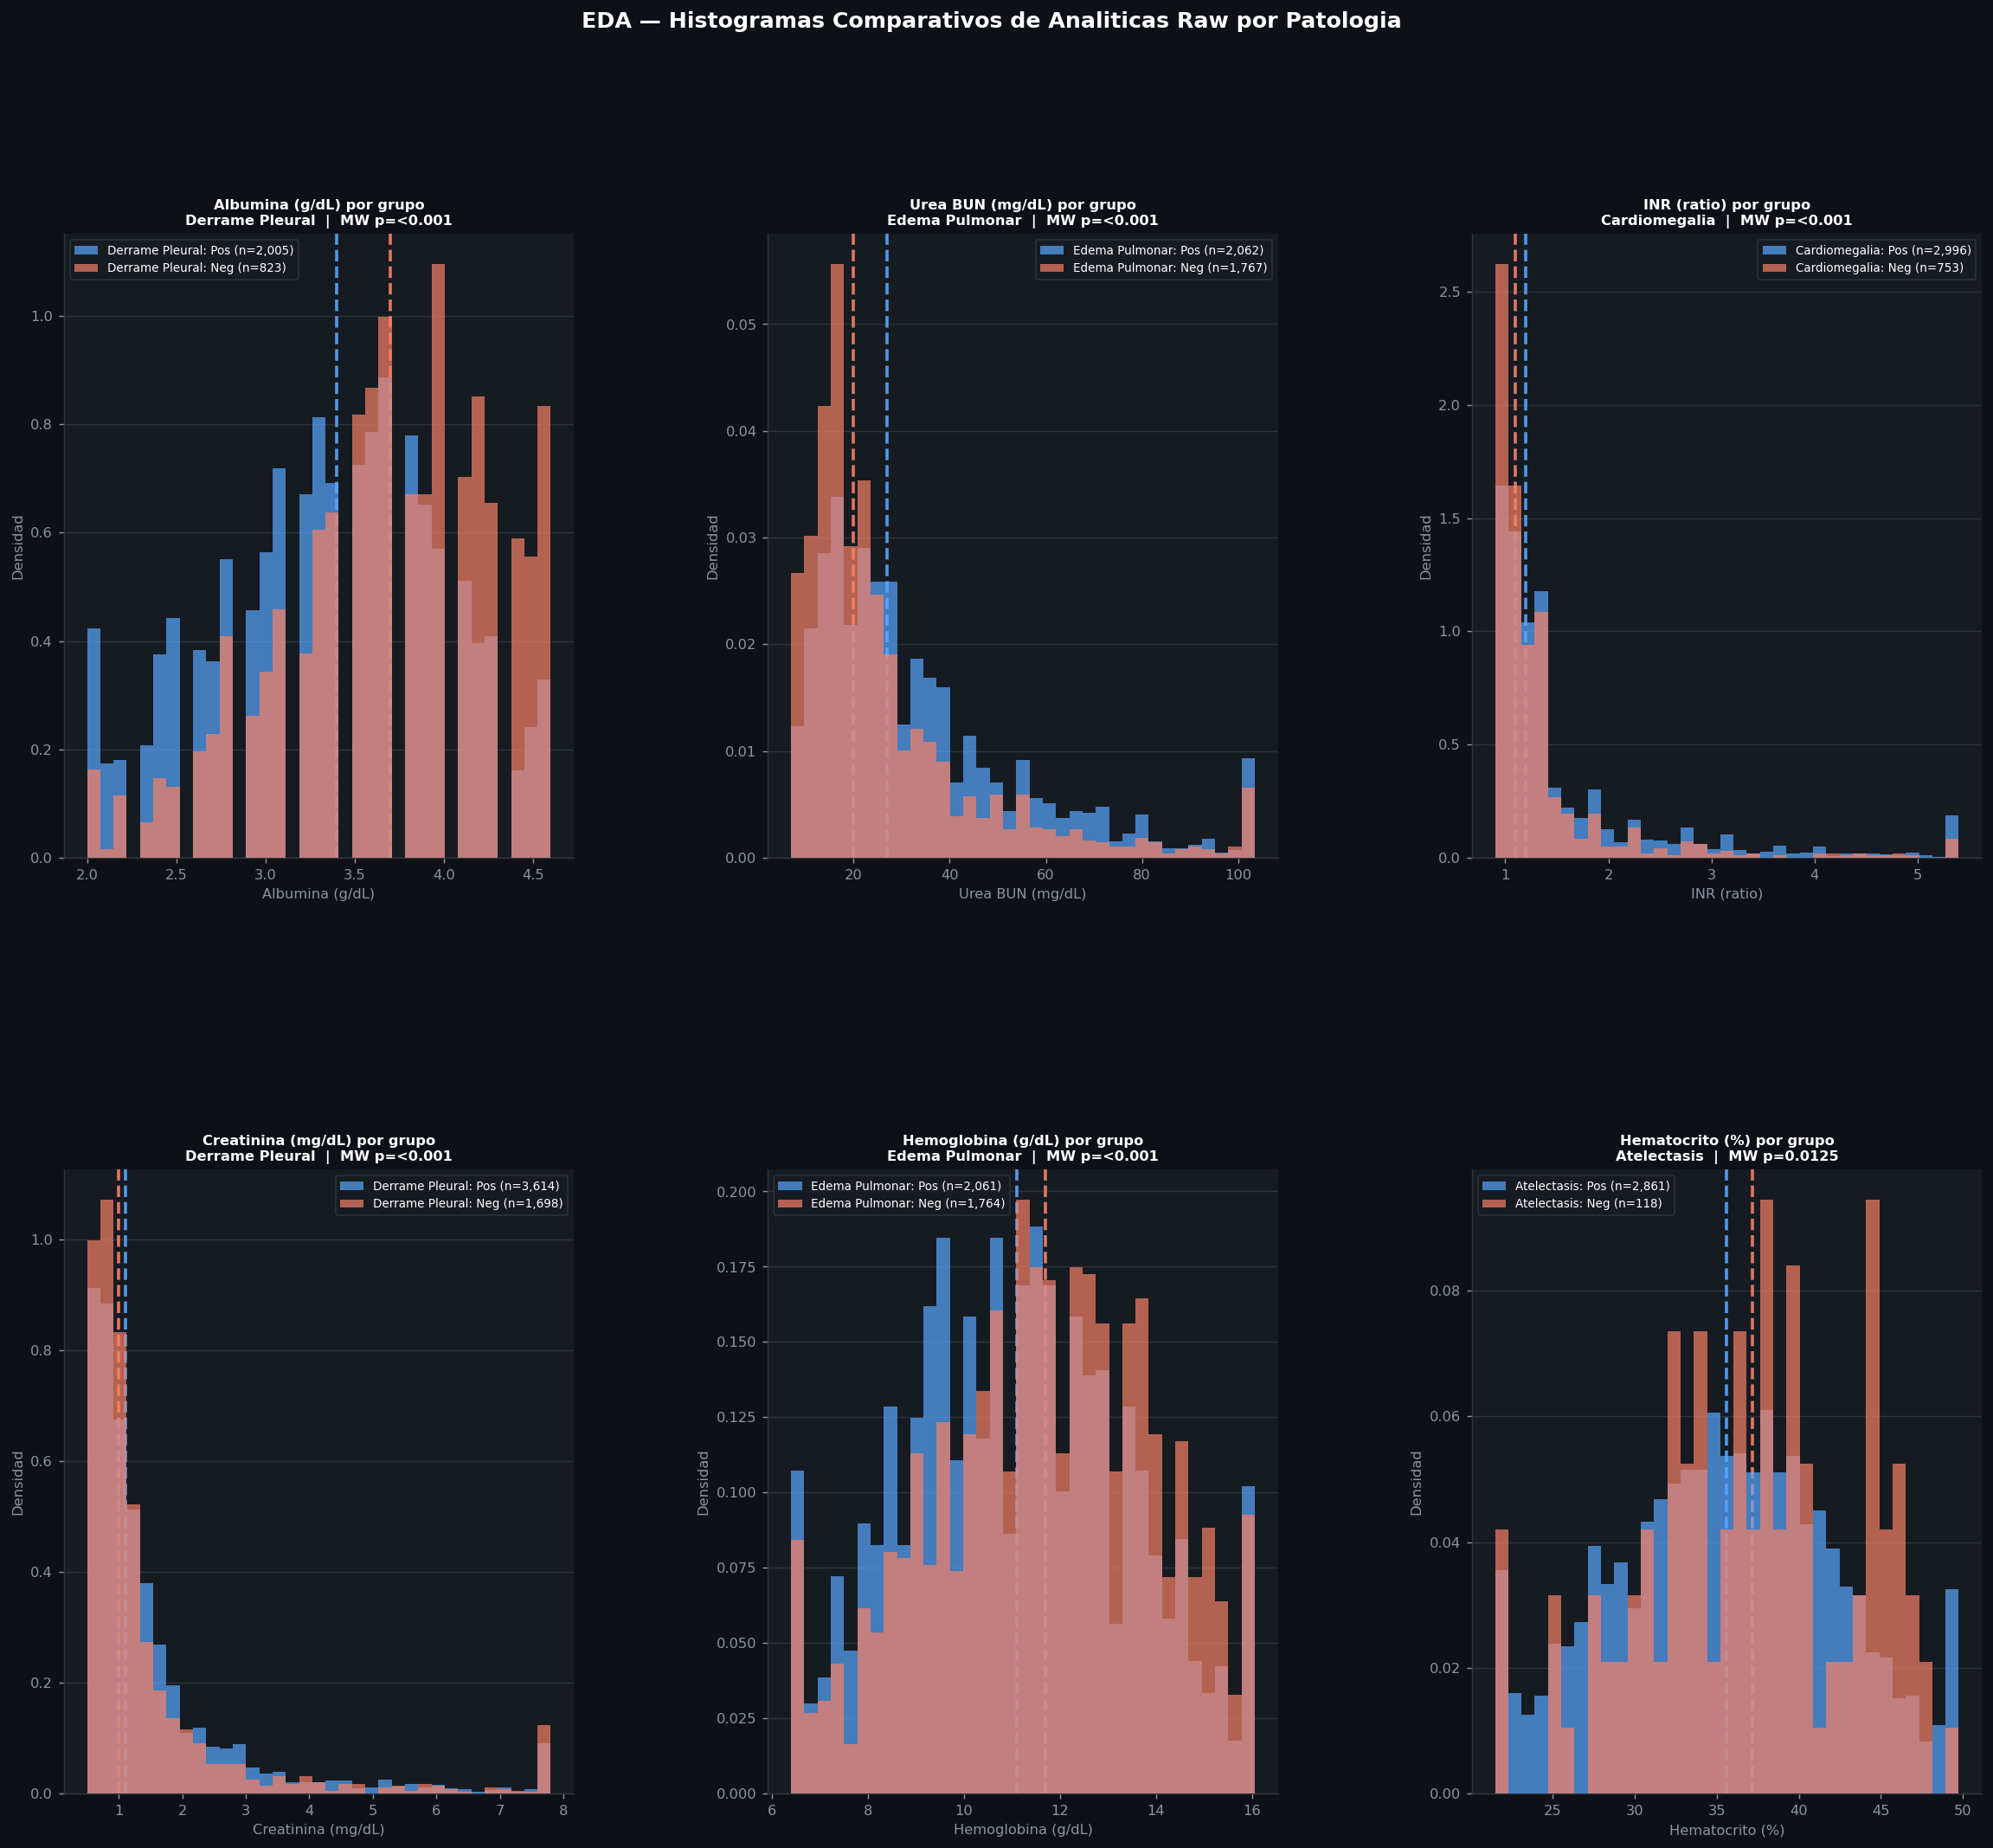

Bloque 5b guardado.


In [8]:
# Histogramas comparativos específicos (raw)
fig2 = plt.figure(figsize=(22, 18), facecolor=DARK_BG)
fig2.suptitle('EDA — Histogramas Comparativos de Analiticas Raw por Patologia',
              fontsize=14, fontweight='bold', color='white', y=0.99)
gs2 = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.50, wspace=0.38)

combos = [
    ('Pleural Effusion', 'albumin_50862',    'Derrame Pleural', 'Albumina (g/dL)'),
    ('Edema',           'urea_nitrogen_51006', 'Edema Pulmonar', 'Urea BUN (mg/dL)'),
    ('Cardiomegaly',    'inr_pt_51237',        'Cardiomegalia',  'INR (ratio)'),
    ('Pleural Effusion','creatinine_50912',    'Derrame Pleural', 'Creatinina (mg/dL)'),
    ('Edema',           'hemoglobin_51222',    'Edema Pulmonar',  'Hemoglobina (g/dL)'),
    ('Atelectasis',     'hematocrit_51221',    'Atelectasis',     'Hematocrito (%)'),
]
raw_arr = train[LAB_RAW_COLS].values.astype(float)

for i, (lbl_col, lab_col, lbl_disp, lab_disp) in enumerate(combos):
    ax = fig2.add_subplot(gs2[i//3, i%3], facecolor=PANEL_BG)
    if lab_col not in LAB_RAW_COLS: ax.axis('off'); continue
    lab_idx = LAB_RAW_COLS.index(lab_col)
    grp_pos = raw_arr[(train[lbl_col]==1).values, lab_idx]; grp_pos = grp_pos[~np.isnan(grp_pos)]
    grp_neg = raw_arr[(train[lbl_col]==0).values, lab_idx]; grp_neg = grp_neg[~np.isnan(grp_neg)]
    if len(grp_pos) < 5 or len(grp_neg) < 5: ax.axis('off'); continue
    lo_, hi_ = np.percentile(np.concatenate([grp_pos,grp_neg]), [2,98])
    bins_ = np.linspace(lo_, hi_, 36)
    ax.hist(np.clip(grp_pos,lo_,hi_), bins=bins_, color=C_CYAN, alpha=0.7, density=True, edgecolor='none', label=f'{lbl_disp}: Pos (n={len(grp_pos):,})', zorder=3)
    ax.hist(np.clip(grp_neg,lo_,hi_), bins=bins_, color=C_PINK, alpha=0.7, density=True, edgecolor='none', label=f'{lbl_disp}: Neg (n={len(grp_neg):,})', zorder=3)
    ax.axvline(np.median(grp_pos), color=C_CYAN, lw=2, linestyle='--', alpha=0.9)
    ax.axvline(np.median(grp_neg), color=C_PINK, lw=2, linestyle='--', alpha=0.9)
    _, p_mw = stats.mannwhitneyu(grp_pos, grp_neg, alternative='two-sided')
    mw_t = '<0.001' if p_mw < 0.001 else f'{p_mw:.4f}'
    ax.set_xlabel(lab_disp, color=C_GREY)
    ax.set_ylabel('Densidad', color=C_GREY)
    ax.set_title(f'{lab_disp} por grupo\n{lbl_disp}  |  MW p={mw_t}', color='white', fontsize=9)
    ax.legend(fontsize=7.5, labelcolor='white')
    ax.tick_params(colors=C_GREY)
    ax.yaxis.grid(True, alpha=0.2, color=C_GREY)

plt.savefig(out('block5b_histos.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 5b guardado.")


---
## Bloque 6 — Análisis Multivariante: Demografía × Analíticas × Etiquetas

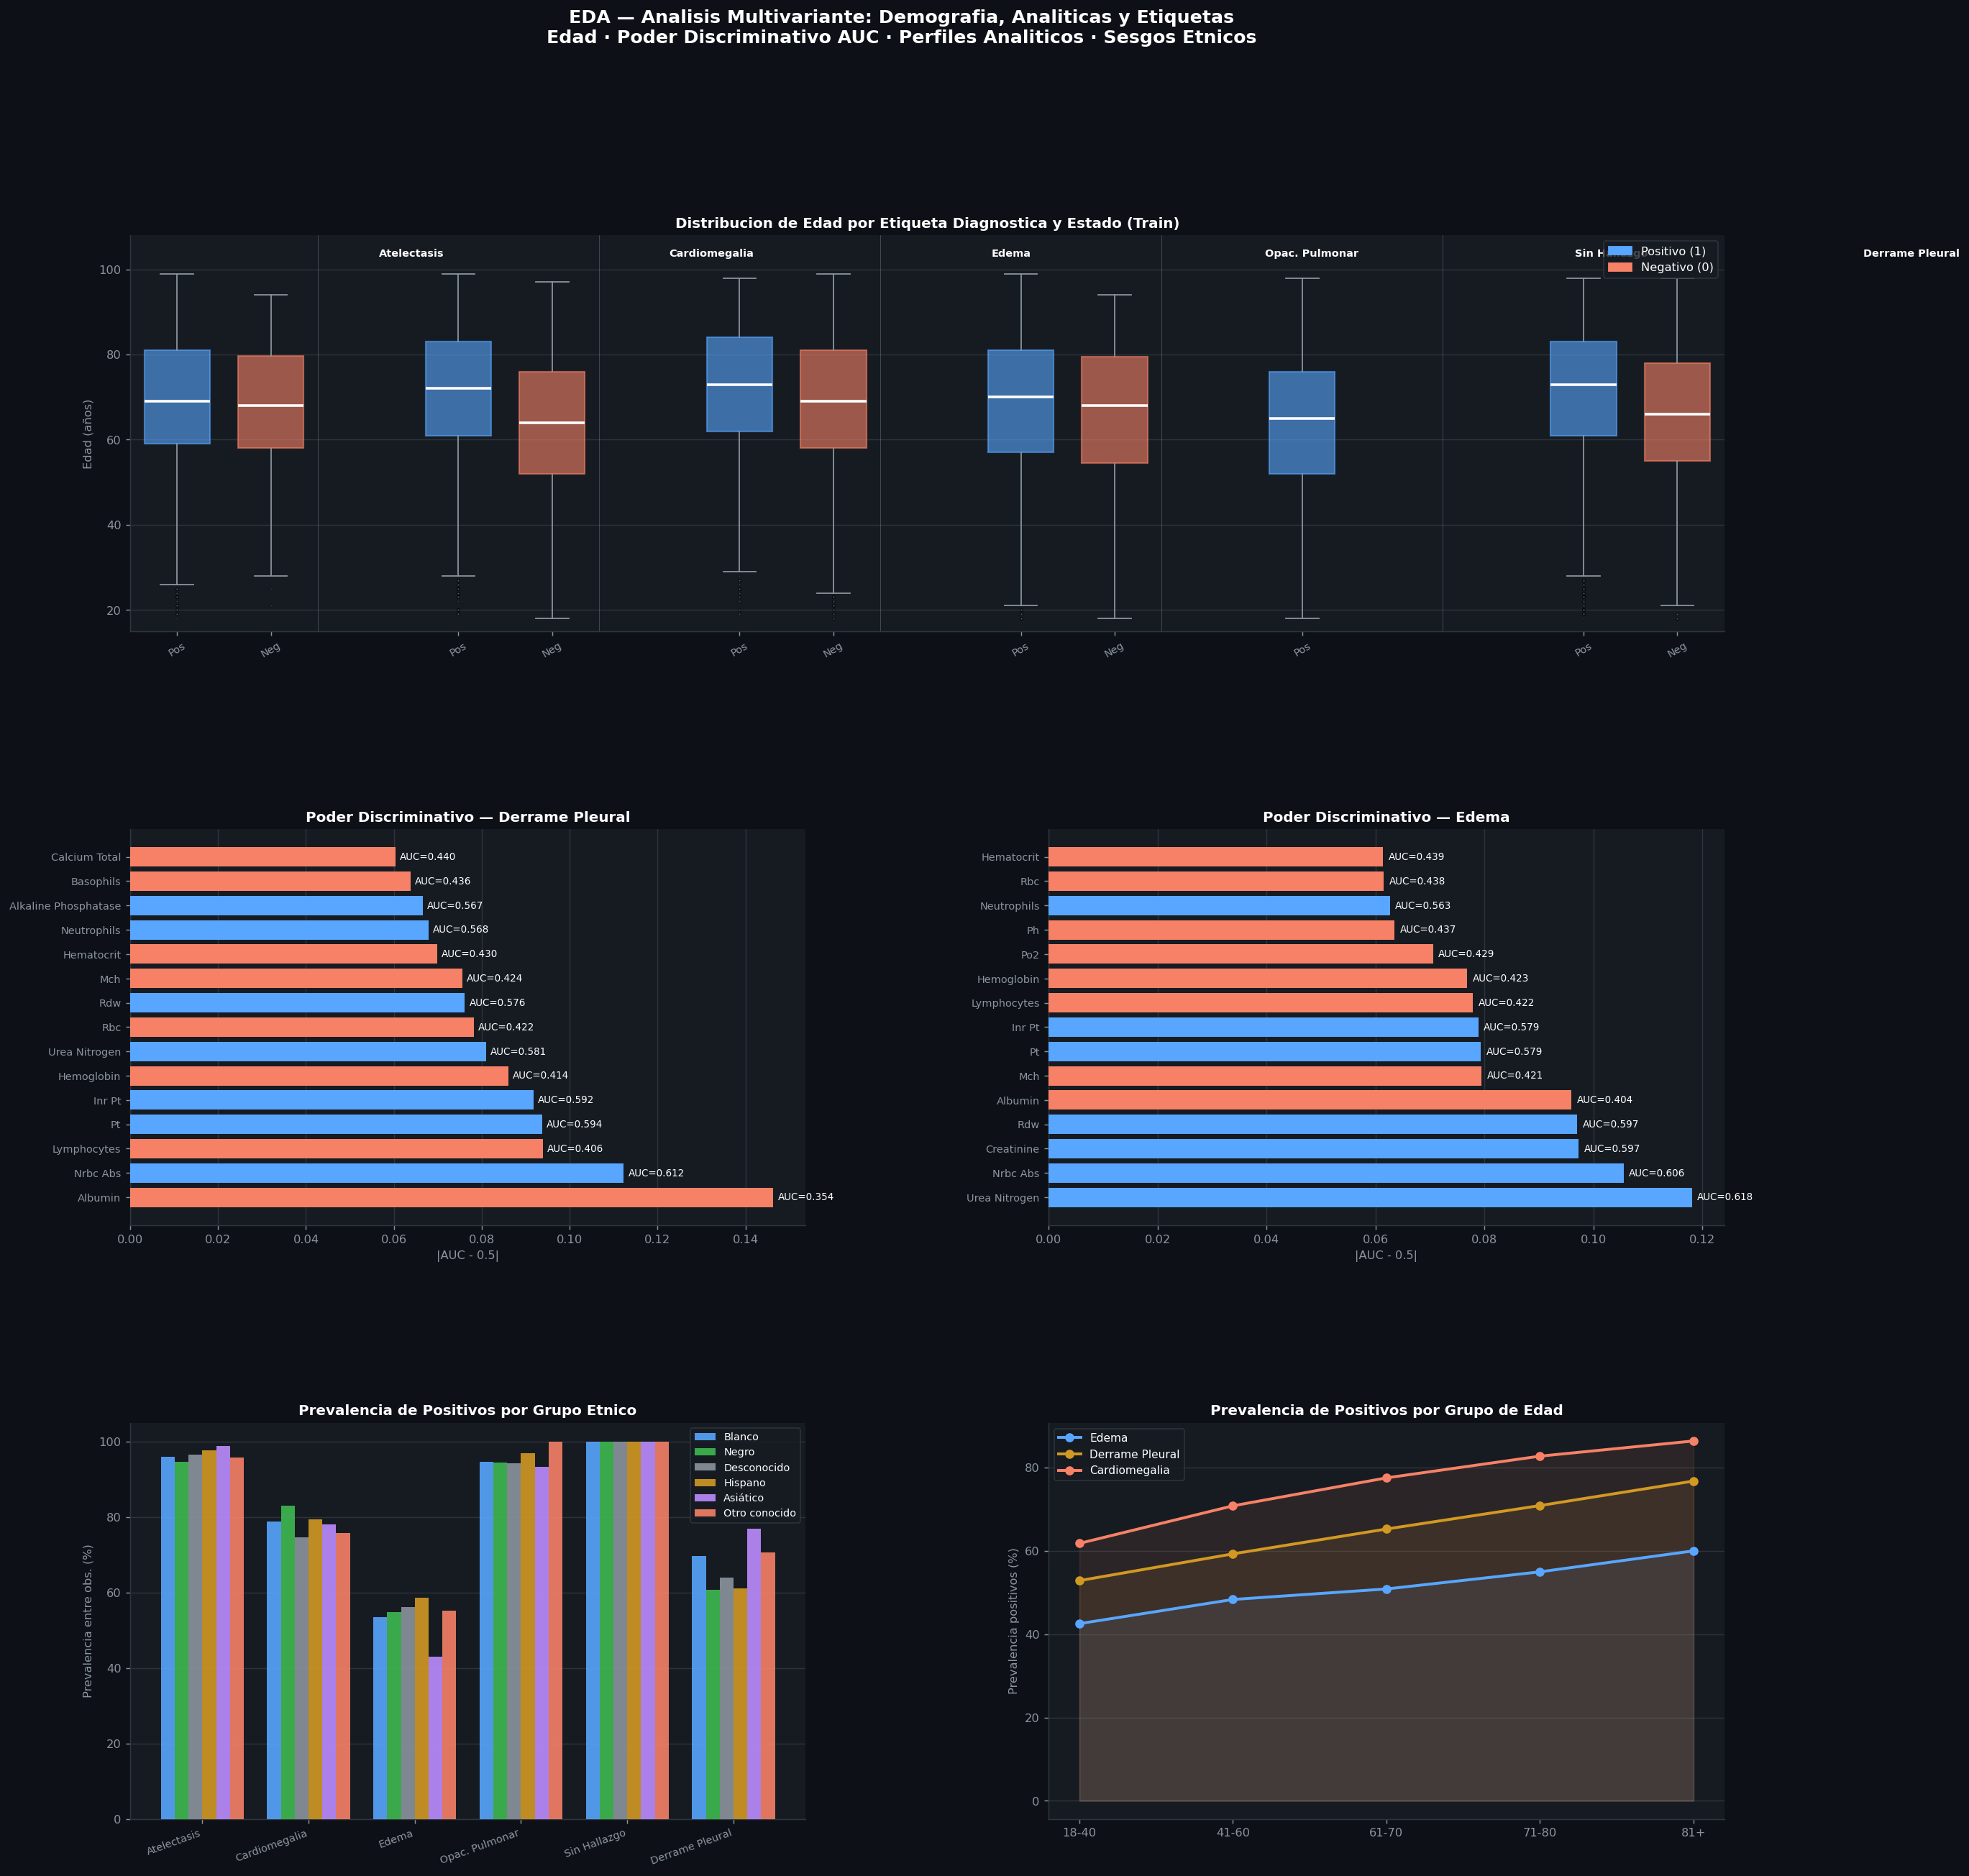

Bloque 6 guardado.


In [9]:
fig = plt.figure(figsize=(22, 22), facecolor=DARK_BG)
fig.suptitle('EDA — Analisis Multivariante: Demografia, Analiticas y Etiquetas\n'
             'Edad · Poder Discriminativo AUC · Perfiles Analiticos · Sesgos Etnicos',
             fontsize=14, fontweight='bold', color='white', y=0.99)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.50, wspace=0.36)

raw_arr  = train[LAB_RAW_COLS].values.astype(float)
miss_raw = train[LAB_RAW_COLS].isnull().mean().values

ax0 = fig.add_subplot(gs[0, 0:2], facecolor=PANEL_BG)
all_cols_bp, tick_pos, tick_labs = [], [], []
x_cursor = 1
for j, (lc, ld) in enumerate(zip(LABEL_COLS, LABEL_DISPLAY)):
    pos_age = train.loc[train[lc]==1, 'age'].dropna().values
    neg_age = train.loc[train[lc]==0, 'age'].dropna().values
    for k, (grp, lbl, col_bp) in enumerate([(pos_age,'Pos',C_CYAN),(neg_age,'Neg',C_PINK)]):
        if len(grp) < 5: x_cursor += 1; continue
        bp = ax0.boxplot([grp], positions=[x_cursor], patch_artist=True, widths=0.7, notch=False,
                         medianprops={'color':'white','lw':2},
                         flierprops={'markersize':1.5,'alpha':0.3,'markerfacecolor':C_GREY},
                         whiskerprops={'color':C_GREY,'lw':1}, capprops={'color':C_GREY,'lw':1},
                         boxprops={'edgecolor':col_bp,'lw':1.2})
        bp['boxes'][0].set_facecolor(col_bp); bp['boxes'][0].set_alpha(0.6)
        all_cols_bp.append(col_bp); tick_pos.append(x_cursor); tick_labs.append(lbl); x_cursor += 1
    if j < len(LABEL_COLS)-1: ax0.axvline(x_cursor - 0.5, color=C_GREY, lw=0.5, alpha=0.4)
    x_cursor += 1
ax0.set_xticks(tick_pos)
ax0.set_xticklabels(tick_labs, fontsize=8, color=C_GREY, rotation=30)
for tick, col in zip(ax0.get_xticklabels(), all_cols_bp): tick.set_color(col)
for j, ld in enumerate(LABEL_DISPLAY): ax0.text(3.5 + j*3.2, 103, ld, ha='center', fontsize=8, color='white', fontweight='bold')
ax0.set_ylabel('Edad (años)', color=C_GREY)
ax0.set_title('Distribucion de Edad por Etiqueta Diagnostica y Estado (Train)', color='white', fontsize=11)
ax0.yaxis.grid(True, alpha=0.2, color=C_GREY)
ax0.set_ylim(15, 108)
ax0.tick_params(colors=C_GREY)
leg_e = [mpatches.Patch(color=C_CYAN, label='Positivo (1)'), mpatches.Patch(color=C_PINK, label='Negativo (0)')]
ax0.legend(handles=leg_e, fontsize=9, labelcolor='white', loc='upper right')

ax1 = fig.add_subplot(gs[1, 0], facecolor=PANEL_BG)
auc_pe = []
for idx in range(len(LAB_RAW_COLS)):
    pos_v = raw_arr[(train['Pleural Effusion']==1).values, idx]; pos_v = pos_v[~np.isnan(pos_v)]
    neg_v = raw_arr[(train['Pleural Effusion']==0).values, idx]; neg_v = neg_v[~np.isnan(neg_v)]
    if len(pos_v) >= 5 and len(neg_v) >= 5:
        u, _ = stats.mannwhitneyu(pos_v, neg_v, alternative='two-sided')
        auc_pe.append((LAB_RAW_DISP[idx], u/(len(pos_v)*len(neg_v))))
    else: auc_pe.append((LAB_RAW_DISP[idx], 0.5))
auc_pe_s = sorted(auc_pe, key=lambda x: abs(x[1]-0.5), reverse=True)[:15]
cols_pe = [C_CYAN if v>=0.5 else C_PINK for _,v in auc_pe_s]
ax1.barh(range(len(auc_pe_s)), [abs(v-0.5) for _,v in auc_pe_s], color=cols_pe, edgecolor='none', zorder=3)
ax1.set_yticks(range(len(auc_pe_s)))
ax1.set_yticklabels([n for n,_ in auc_pe_s], fontsize=8, color=C_GREY)
for i, (_,v) in enumerate(auc_pe_s): ax1.text(abs(v-0.5)+0.001, i, f'AUC={v:.3f}', va='center', fontsize=7.5, color='white')
ax1.set_xlabel('|AUC - 0.5|', color=C_GREY)
ax1.set_title('Poder Discriminativo — Derrame Pleural', color='white')
ax1.tick_params(colors=C_GREY); ax1.xaxis.grid(True, alpha=0.2, color=C_GREY)

ax2 = fig.add_subplot(gs[1, 1], facecolor=PANEL_BG)
auc_ed = []
for idx in range(len(LAB_RAW_COLS)):
    pos_v = raw_arr[(train['Edema']==1).values, idx]; pos_v = pos_v[~np.isnan(pos_v)]
    neg_v = raw_arr[(train['Edema']==0).values, idx]; neg_v = neg_v[~np.isnan(neg_v)]
    if len(pos_v) >= 5 and len(neg_v) >= 5:
        u, _ = stats.mannwhitneyu(pos_v, neg_v, alternative='two-sided')
        auc_ed.append((LAB_RAW_DISP[idx], u/(len(pos_v)*len(neg_v))))
    else: auc_ed.append((LAB_RAW_DISP[idx], 0.5))
auc_ed_s = sorted(auc_ed, key=lambda x: abs(x[1]-0.5), reverse=True)[:15]
cols_ed = [C_CYAN if v>=0.5 else C_PINK for _,v in auc_ed_s]
ax2.barh(range(len(auc_ed_s)), [abs(v-0.5) for _,v in auc_ed_s], color=cols_ed, edgecolor='none', zorder=3)
ax2.set_yticks(range(len(auc_ed_s)))
ax2.set_yticklabels([n for n,_ in auc_ed_s], fontsize=8, color=C_GREY)
for i, (_,v) in enumerate(auc_ed_s): ax2.text(abs(v-0.5)+0.001, i, f'AUC={v:.3f}', va='center', fontsize=7.5, color='white')
ax2.set_xlabel('|AUC - 0.5|', color=C_GREY)
ax2.set_title('Poder Discriminativo — Edema', color='white')
ax2.tick_params(colors=C_GREY); ax2.xaxis.grid(True, alpha=0.2, color=C_GREY)

ax3 = fig.add_subplot(gs[2, 0], facecolor=PANEL_BG)
train3 = train.copy()
train3['Etnia'] = train3['race'].map(RACE_MAP).fillna('Otro')
races_ = train3['Etnia'].value_counts().index.tolist()
x3 = np.arange(len(LABEL_DISPLAY)); w3 = 0.13
pal3 = [C_CYAN, C_GREEN, C_GREY, C_ORANGE, C_PURPLE, C_PINK]
for i, (race, col3) in enumerate(zip(races_, pal3)):
    prev3 = []
    for lc in LABEL_COLS:
        df_obs = train3[train3[lc].isin([0,1])]; sub = df_obs[df_obs['Etnia']==race]
        prev3.append((sub[lc]==1).sum()/len(sub)*100 if len(sub)>0 else 0)
    ax3.bar(x3 + i*w3, prev3, w3, label=race, color=col3, edgecolor='none', alpha=0.9, zorder=3)
ax3.set_xticks(x3 + w3*2.5)
ax3.set_xticklabels(LABEL_DISPLAY, rotation=20, ha='right', fontsize=8, color=C_GREY)
ax3.set_ylabel('Prevalencia entre obs. (%)', color=C_GREY)
ax3.set_title('Prevalencia de Positivos por Grupo Etnico', color='white')
ax3.legend(fontsize=8, labelcolor='white')
ax3.yaxis.grid(True, alpha=0.2, color=C_GREY)
ax3.tick_params(colors=C_GREY)

ax4 = fig.add_subplot(gs[2, 1], facecolor=PANEL_BG)
bins_age = [18, 40, 60, 70, 80, 100]; labs_age = ['18-40', '41-60', '61-70', '71-80', '81+']
train4 = train.copy()
train4['age_group'] = pd.cut(train4['age'], bins=bins_age, labels=labs_age, right=False)
for lc, ld, col4 in [('Edema','Edema',C_CYAN),('Pleural Effusion','Derrame Pleural',C_ORANGE),('Cardiomegaly','Cardiomegalia',C_PINK)]:
    prev4 = []
    for ag in labs_age:
        sub = train4[(train4['age_group']==ag) & (train4[lc].isin([0,1]))]
        prev4.append((sub[lc]==1).sum()/len(sub)*100 if len(sub)>0 else 0)
    ax4.plot(labs_age, prev4, marker='o', color=col4, lw=2.2, label=ld, zorder=4)
    ax4.fill_between(range(len(labs_age)), prev4, alpha=0.1, color=col4)
ax4.set_xticks(range(len(labs_age)))
ax4.set_xticklabels(labs_age, color=C_GREY)
ax4.set_ylabel('Prevalencia positivos (%)', color=C_GREY)
ax4.set_title('Prevalencia de Positivos por Grupo de Edad', color='white')
ax4.legend(fontsize=8.5, labelcolor='white')
ax4.yaxis.grid(True, alpha=0.2, color=C_GREY)
ax4.tick_params(colors=C_GREY)

plt.savefig(out('block6_multivariate.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 6 guardado.")


---
## Bloque 7 — Poder Predictivo AUC Completo y Perfiles Clínicos Radar

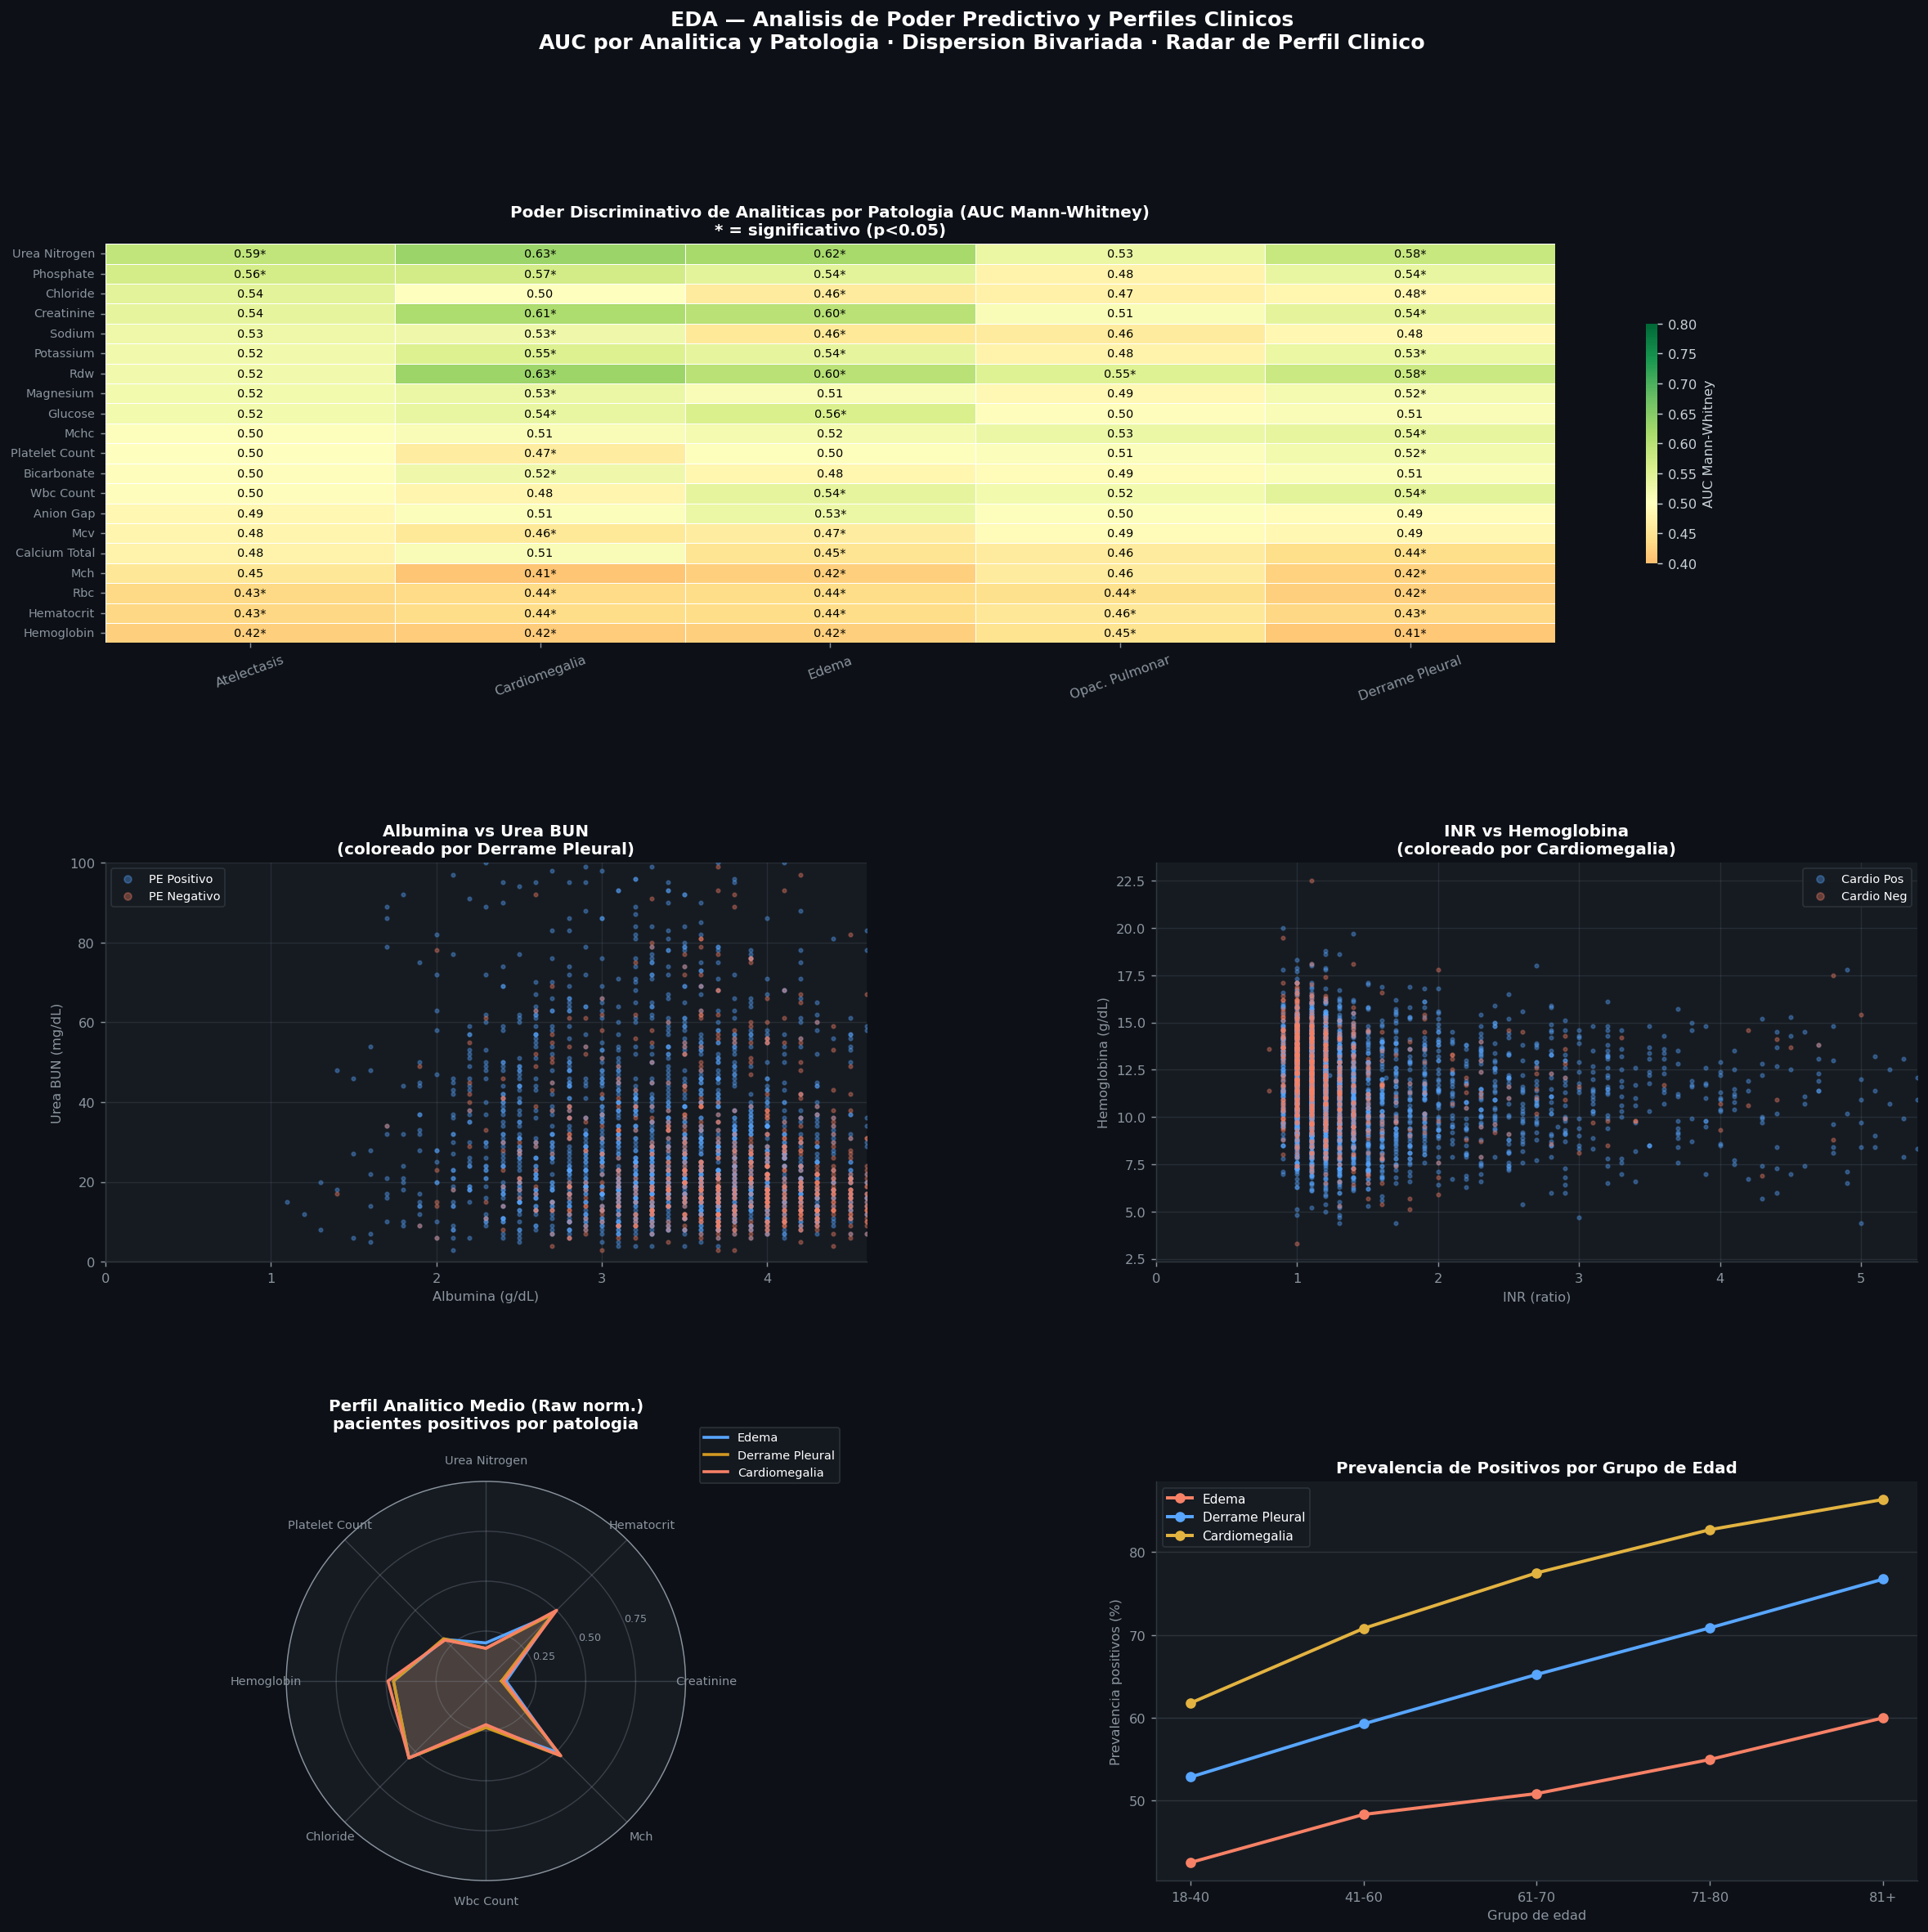

Bloque 7 guardado.


In [10]:
fig = plt.figure(figsize=(22, 20), facecolor=DARK_BG)
fig.suptitle('EDA — Analisis de Poder Predictivo y Perfiles Clinicos\n'
             'AUC por Analitica y Patologia · Dispersion Bivariada · Radar de Perfil Clinico',
             fontsize=14, fontweight='bold', color='white', y=0.99)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.38)

raw_arr  = train[LAB_RAW_COLS].values.astype(float)
miss_raw = train[LAB_RAW_COLS].isnull().mean().values
top20_idx   = np.argsort(miss_raw)[:20]
top20_names = [LAB_RAW_DISP[i] for i in top20_idx]
label_cols_nof = [lc for lc in LABEL_COLS if lc != 'No Finding']
label_disp_nof = [ld for lc, ld in zip(LABEL_COLS, LABEL_DISPLAY) if lc != 'No Finding']

ax0 = fig.add_subplot(gs[0, 0:2], facecolor=PANEL_BG)
auc_mat  = pd.DataFrame(np.nan, index=top20_names, columns=label_disp_nof)
star_mat = pd.DataFrame('', index=top20_names, columns=label_disp_nof)
for idx, lab_n in zip(top20_idx, top20_names):
    for lc, ld in zip(label_cols_nof, label_disp_nof):
        pos_v = raw_arr[(train[lc]==1).values, idx]; pos_v = pos_v[~np.isnan(pos_v)]
        neg_v = raw_arr[(train[lc]==0).values, idx]; neg_v = neg_v[~np.isnan(neg_v)]
        if len(pos_v) >= 5 and len(neg_v) >= 5:
            u, p = stats.mannwhitneyu(pos_v, neg_v, alternative='two-sided')
            auc_v = u/(len(pos_v)*len(neg_v))
            auc_mat.loc[lab_n, ld] = auc_v
            star_mat.loc[lab_n, ld] = f'{auc_v:.2f}{"*" if p<0.05 else ""}'
auc_mat = auc_mat.sort_values(by=label_disp_nof[0], ascending=False)
star_mat = star_mat.loc[auc_mat.index]
sns.heatmap(auc_mat.astype(float), annot=star_mat, fmt='', cmap='RdYlGn', center=0.5, vmin=0.4, vmax=0.8,
            ax=ax0, linewidths=0.4, cbar_kws={'shrink':0.6, 'label':'AUC Mann-Whitney'},
            annot_kws={'size':8, 'color':'black'})
ax0.set_title('Poder Discriminativo de Analiticas por Patologia (AUC Mann-Whitney)\n* = significativo (p<0.05)', color='white', fontsize=11)
ax0.tick_params(axis='x', rotation=20, labelsize=9, colors=C_GREY)
ax0.tick_params(axis='y', rotation=0, labelsize=8, colors=C_GREY)

ax1 = fig.add_subplot(gs[1, 0], facecolor=PANEL_BG)
alb_idx = LAB_RAW_COLS.index('albumin_50862') if 'albumin_50862' in LAB_RAW_COLS else None
bun_idx = LAB_RAW_COLS.index('urea_nitrogen_51006') if 'urea_nitrogen_51006' in LAB_RAW_COLS else None
if alb_idx is not None and bun_idx is not None:
    mask_pe = train['Pleural Effusion'].isin([0,1])
    pe_vals = train.loc[mask_pe, 'Pleural Effusion'].values
    alb_v = raw_arr[mask_pe.values, alb_idx]; bun_v = raw_arr[mask_pe.values, bun_idx]
    valid = ~(np.isnan(alb_v) | np.isnan(bun_v))
    ax1.scatter(alb_v[valid & (pe_vals==1)], bun_v[valid & (pe_vals==1)], s=6, alpha=0.35, color=C_CYAN, label='PE Positivo', zorder=3)
    ax1.scatter(alb_v[valid & (pe_vals==0)], bun_v[valid & (pe_vals==0)], s=6, alpha=0.35, color=C_PINK, label='PE Negativo', zorder=3)
    ax1.set_xlim(0, np.nanpercentile(alb_v, 98)); ax1.set_ylim(0, np.nanpercentile(bun_v, 98))
ax1.set_xlabel('Albumina (g/dL)', color=C_GREY); ax1.set_ylabel('Urea BUN (mg/dL)', color=C_GREY)
ax1.set_title('Albumina vs Urea BUN\n(coloreado por Derrame Pleural)', color='white')
ax1.legend(fontsize=8, labelcolor='white', markerscale=2); ax1.tick_params(colors=C_GREY)
ax1.yaxis.grid(True, alpha=0.15, color=C_GREY); ax1.xaxis.grid(True, alpha=0.15, color=C_GREY)

ax2 = fig.add_subplot(gs[1, 1], facecolor=PANEL_BG)
inr_idx = LAB_RAW_COLS.index('inr_pt_51237') if 'inr_pt_51237' in LAB_RAW_COLS else None
hgb_idx = LAB_RAW_COLS.index('hemoglobin_51222') if 'hemoglobin_51222' in LAB_RAW_COLS else None
if inr_idx is not None and hgb_idx is not None:
    mask_cm = train['Cardiomegaly'].isin([0,1])
    cm_vals = train.loc[mask_cm, 'Cardiomegaly'].values
    inr_v = raw_arr[mask_cm.values, inr_idx]; hgb_v = raw_arr[mask_cm.values, hgb_idx]
    valid = ~(np.isnan(inr_v) | np.isnan(hgb_v))
    ax2.scatter(inr_v[valid & (cm_vals==1)], hgb_v[valid & (cm_vals==1)], s=6, alpha=0.35, color=C_CYAN, label='Cardio Pos', zorder=3)
    ax2.scatter(inr_v[valid & (cm_vals==0)], hgb_v[valid & (cm_vals==0)], s=6, alpha=0.35, color=C_PINK, label='Cardio Neg', zorder=3)
    ax2.set_xlim(0, np.nanpercentile(inr_v, 98))
ax2.set_xlabel('INR (ratio)', color=C_GREY); ax2.set_ylabel('Hemoglobina (g/dL)', color=C_GREY)
ax2.set_title('INR vs Hemoglobina\n(coloreado por Cardiomegalia)', color='white')
ax2.legend(fontsize=8, labelcolor='white', markerscale=2); ax2.tick_params(colors=C_GREY)
ax2.yaxis.grid(True, alpha=0.15, color=C_GREY); ax2.xaxis.grid(True, alpha=0.15, color=C_GREY)

ax3 = fig.add_subplot(gs[2, 0], facecolor=PANEL_BG, polar=True)
ax3.set_facecolor(PANEL_BG)
top8_idx = np.argsort(miss_raw)[:8]; top8_names = [LAB_RAW_DISP[i] for i in top8_idx]
n_vars = len(top8_idx)
angles = np.linspace(0, 2*np.pi, n_vars, endpoint=False).tolist() + [0]
for lc, ld, col5 in [('Edema','Edema',C_CYAN),('Pleural Effusion','Derrame Pleural',C_ORANGE),('Cardiomegaly','Cardiomegalia',C_PINK)]:
    meds = []
    for idx in top8_idx:
        vals_r = raw_arr[(train[lc]==1).values, idx]; vals_r = vals_r[~np.isnan(vals_r)]
        all_r  = raw_arr[~np.isnan(raw_arr[:,idx]), idx]
        if len(vals_r) > 0 and len(all_r) > 0:
            p1_, p99_ = np.nanpercentile(all_r, [1,99])
            norm_med = (np.median(vals_r) - p1_) / (p99_ - p1_ + 1e-9)
            meds.append(float(np.clip(norm_med, 0, 1)))
        else: meds.append(0.5)
    meds += meds[:1]
    ax3.plot(angles, meds, color=col5, lw=2, label=ld)
    ax3.fill(angles, meds, color=col5, alpha=0.12)
ax3.set_xticks(angles[:-1]); ax3.set_xticklabels(top8_names, fontsize=8, color=C_GREY)
ax3.set_ylim(0, 1); ax3.set_yticks([0.25, 0.5, 0.75]); ax3.set_yticklabels(['0.25','0.50','0.75'], fontsize=7, color=C_GREY)
ax3.set_title('Perfil Analitico Medio (Raw norm.)\npacientes positivos por patologia', color='white', pad=18)
ax3.legend(loc='upper right', bbox_to_anchor=(1.4,1.15), fontsize=8, labelcolor='white')
ax3.spines['polar'].set_color(C_GREY); ax3.grid(color=C_GREY, alpha=0.3)

ax4 = fig.add_subplot(gs[2, 1], facecolor=PANEL_BG)
bins_age2 = [18, 40, 60, 70, 80, 101]; labs_age2 = ['18-40', '41-60', '61-70', '71-80', '81+']
train5 = train.copy()
train5['age_group'] = pd.cut(train5['age'], bins=bins_age2, labels=labs_age2, right=False)
for lc, ld, col6 in [('Edema','Edema',C_PINK),('Pleural Effusion','Derrame Pleural',C_CYAN),('Cardiomegaly','Cardiomegalia',C_YELLOW)]:
    prev5 = []
    for ag in labs_age2:
        sub5 = train5[(train5['age_group']==ag) & (train5[lc].isin([0,1]))]
        prev5.append((sub5[lc]==1).sum()/len(sub5)*100 if len(sub5)>0 else 0)
    ax4.plot(labs_age2, prev5, marker='o', color=col6, lw=2.2, label=ld, zorder=4)
ax4.set_xlabel('Grupo de edad', color=C_GREY); ax4.set_ylabel('Prevalencia positivos (%)', color=C_GREY)
ax4.set_title('Prevalencia de Positivos por Grupo de Edad', color='white')
ax4.legend(fontsize=8.5, labelcolor='white'); ax4.yaxis.grid(True, alpha=0.2, color=C_GREY)
ax4.tick_params(colors=C_GREY)

plt.savefig(out('block7_discriminative.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 7 guardado.")


---
## Bloque 8 — Calidad de Datos, Desequilibrio y Consistencia entre Splits

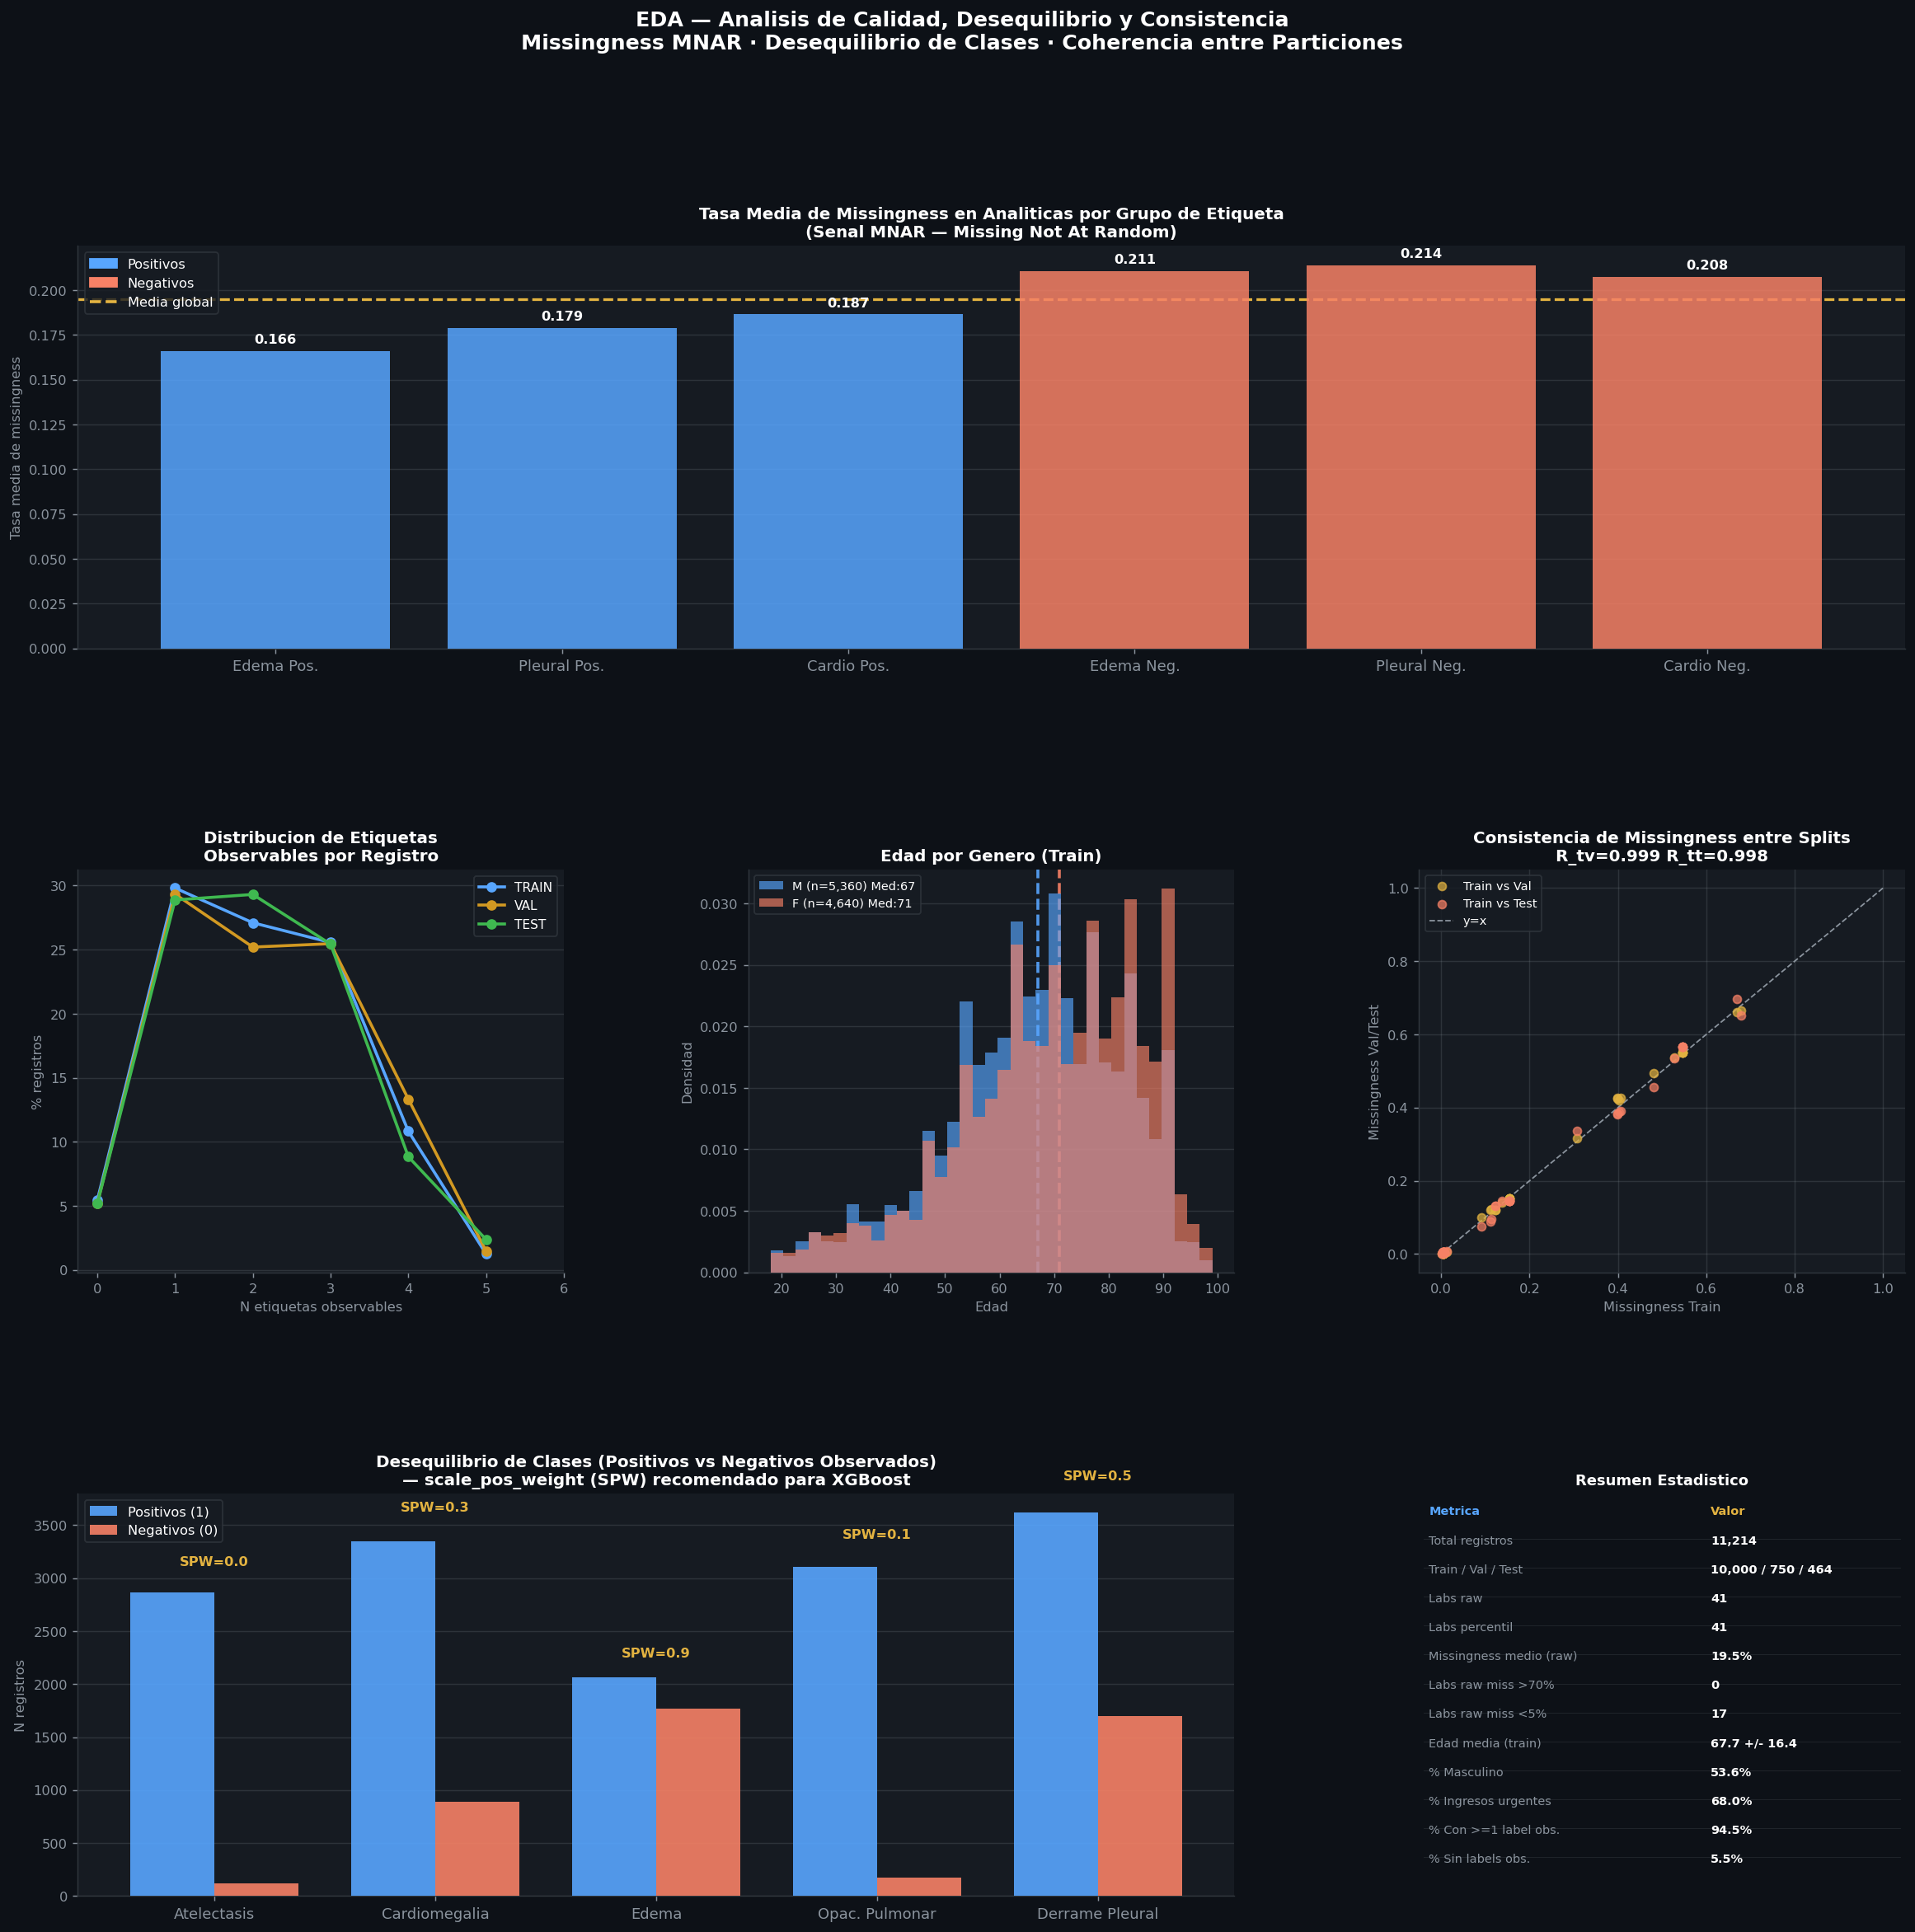

Bloque 8 guardado.


In [11]:
fig = plt.figure(figsize=(22, 20), facecolor=DARK_BG)
fig.suptitle('EDA — Analisis de Calidad, Desequilibrio y Consistencia\n'
             'Missingness MNAR · Desequilibrio de Clases · Coherencia entre Particiones',
             fontsize=14, fontweight='bold', color='white', y=0.99)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

raw_arr  = train[LAB_RAW_COLS].values.astype(float)
miss_raw = train[LAB_RAW_COLS].isnull().mean().values

ax0 = fig.add_subplot(gs[0, 0:3], facecolor=PANEL_BG)
label_miss_pos, label_miss_neg = [], []
target_labels = ['Edema', 'Pleural Effusion', 'Cardiomegaly']
for lc in target_labels:
    pos_mask = (train[lc]==1).values; neg_mask = (train[lc]==0).values
    label_miss_pos.append(np.isnan(raw_arr[pos_mask]).mean())
    label_miss_neg.append(np.isnan(raw_arr[neg_mask]).mean())
xlabels_mm = [f'{lc} Pos.' for lc in ['Edema','Pleural','Cardio']] + [f'{lc} Neg.' for lc in ['Edema','Pleural','Cardio']]
vals_mm = label_miss_pos + label_miss_neg; colors_mm = [C_CYAN]*3 + [C_PINK]*3
bars_mm = ax0.bar(range(6), vals_mm, color=colors_mm, edgecolor='none', zorder=3, alpha=0.85)
for bar_, v_ in zip(bars_mm, vals_mm):
    ax0.text(bar_.get_x()+bar_.get_width()/2, v_+0.003, f'{v_:.3f}', ha='center', va='bottom', fontsize=9, color='white', fontweight='bold')
global_miss = np.isnan(raw_arr).mean()
ax0.axhline(global_miss, color=C_YELLOW, lw=1.8, linestyle='--', label=f'Media global {global_miss:.3f}')
ax0.set_xticks(range(6)); ax0.set_xticklabels(xlabels_mm, fontsize=10, color=C_GREY)
ax0.set_ylabel('Tasa media de missingness', color=C_GREY)
ax0.set_title('Tasa Media de Missingness en Analiticas por Grupo de Etiqueta\n(Senal MNAR — Missing Not At Random)', color='white', fontsize=11)
leg_mm = [mpatches.Patch(color=C_CYAN, label='Positivos'), mpatches.Patch(color=C_PINK, label='Negativos'),
          Line2D([0],[0], color=C_YELLOW, lw=2, linestyle='--', label='Media global')]
ax0.legend(handles=leg_mm, fontsize=9, labelcolor='white')
ax0.yaxis.grid(True, alpha=0.2, color=C_GREY); ax0.tick_params(colors=C_GREY)

ax1 = fig.add_subplot(gs[1, 0], facecolor=PANEL_BG)
for sp, col_ in SPLIT_COLORS.items():
    df_sp = dfs[sp]
    obs_r = df_sp[LABEL_COLS].apply(lambda x: ((x==0)|(x==1)).sum(), axis=1)
    vc = obs_r.value_counts().sort_index()
    ax1.plot(vc.index, vc.values/len(df_sp)*100, marker='o', lw=2, color=col_, label=sp.upper(), zorder=4)
ax1.set_xlabel('N etiquetas observables', color=C_GREY); ax1.set_ylabel('% registros', color=C_GREY)
ax1.set_title('Distribucion de Etiquetas\nObservables por Registro', color='white')
ax1.legend(fontsize=8.5, labelcolor='white'); ax1.yaxis.grid(True, alpha=0.2, color=C_GREY)
ax1.tick_params(colors=C_GREY); ax1.set_xticks(range(7))

ax2 = fig.add_subplot(gs[1, 1], facecolor=PANEL_BG)
data_m2 = train.loc[train['gender']==1, 'age'].dropna().values
data_f2 = train.loc[train['gender']==0, 'age'].dropna().values
ax2.hist(data_m2, bins=35, color=C_CYAN, alpha=0.65, density=True, edgecolor='none', label=f'M (n={len(data_m2):,}) Med:{np.median(data_m2):.0f}', zorder=3)
ax2.hist(data_f2, bins=35, color=C_PINK, alpha=0.65, density=True, edgecolor='none', label=f'F (n={len(data_f2):,}) Med:{np.median(data_f2):.0f}', zorder=3)
ax2.axvline(np.median(data_m2), color=C_CYAN, lw=2, linestyle='--', alpha=0.9)
ax2.axvline(np.median(data_f2), color=C_PINK, lw=2, linestyle='--', alpha=0.9)
ax2.set_xlabel('Edad', color=C_GREY); ax2.set_ylabel('Densidad', color=C_GREY)
ax2.set_title('Edad por Genero (Train)', color='white')
ax2.legend(fontsize=8, labelcolor='white'); ax2.tick_params(colors=C_GREY); ax2.yaxis.grid(True, alpha=0.2, color=C_GREY)

ax3 = fig.add_subplot(gs[1, 2], facecolor=PANEL_BG)
miss_train = train[LAB_RAW_COLS].isnull().mean().values
miss_val   = val[LAB_RAW_COLS].isnull().mean().values
miss_test  = test[LAB_RAW_COLS].isnull().mean().values
ax3.scatter(miss_train, miss_val,  color=C_YELLOW, s=30, alpha=0.7, label='Train vs Val', zorder=4)
ax3.scatter(miss_train, miss_test, color=C_PINK, s=30, alpha=0.7, label='Train vs Test', zorder=4)
ax3.plot([0,1],[0,1], color=C_GREY, lw=1, linestyle='--', label='y=x')
r_tv = np.corrcoef(miss_train, miss_val)[0,1]; r_tt = np.corrcoef(miss_train, miss_test)[0,1]
ax3.set_xlabel('Missingness Train', color=C_GREY); ax3.set_ylabel('Missingness Val/Test', color=C_GREY)
ax3.set_title(f'Consistencia de Missingness entre Splits\nR_tv={r_tv:.3f} R_tt={r_tt:.3f}', color='white')
ax3.legend(fontsize=8, labelcolor='white'); ax3.tick_params(colors=C_GREY)
ax3.yaxis.grid(True, alpha=0.2, color=C_GREY); ax3.xaxis.grid(True, alpha=0.2, color=C_GREY)

ax4 = fig.add_subplot(gs[2, 0:2], facecolor=PANEL_BG)
label_cols_nof2 = [lc for lc in LABEL_COLS if lc != 'No Finding']
label_disp_nof2 = [ld for lc, ld in zip(LABEL_COLS, LABEL_DISPLAY) if lc != 'No Finding']
x_des = np.arange(len(label_cols_nof2)); w_des = 0.38
pos_counts = [int((train[lc]==1).sum()) for lc in label_cols_nof2]
neg_counts = [int((train[lc]==0).sum()) for lc in label_cols_nof2]
spw_vals   = [n/p if p>0 else 0 for p, n in zip(pos_counts, neg_counts)]
ax4.bar(x_des - w_des/2, pos_counts, w_des, color=C_CYAN, edgecolor='none', label='Positivos (1)', alpha=0.9, zorder=3)
ax4.bar(x_des + w_des/2, neg_counts, w_des, color=C_PINK, edgecolor='none', label='Negativos (0)', alpha=0.9, zorder=3)
for i, (x_s, spw) in enumerate(zip(x_des, spw_vals)):
    ax4.text(x_s, max(pos_counts[i], neg_counts[i])*1.08, f'SPW={spw:.1f}', ha='center', va='bottom', fontsize=9, color=C_YELLOW, fontweight='bold')
ax4.set_xticks(x_des); ax4.set_xticklabels(label_disp_nof2, fontsize=10, color=C_GREY)
ax4.set_ylabel('N registros', color=C_GREY)
ax4.set_title('Desequilibrio de Clases (Positivos vs Negativos Observados)\n— scale_pos_weight (SPW) recomendado para XGBoost', color='white', fontsize=11)
ax4.legend(fontsize=9, labelcolor='white'); ax4.yaxis.grid(True, alpha=0.2, color=C_GREY); ax4.tick_params(colors=C_GREY)

ax5 = fig.add_subplot(gs[2, 2], facecolor=PANEL_BG)
ax5.axis('off')
obs_any_train = train[LABEL_COLS].apply(lambda x: ((x==0)|(x==1)).sum(), axis=1)
total = sum(len(dfs[s]) for s in dfs)
summary_q = [('Metrica', 'Valor'), ('Total registros', f'{total:,}'),
    ('Train / Val / Test', f'{len(train):,} / {len(val):,} / {len(test):,}'),
    ('Labs raw', f'{len(LAB_RAW_COLS)}'), ('Labs percentil', f'{len(LAB_PCTILE_COLS)}'),
    ('Missingness medio (raw)', f'{miss_train.mean()*100:.1f}%'),
    ('Labs raw miss >70%', f'{(miss_train>0.7).sum()}'), ('Labs raw miss <5%', f'{(miss_train<0.05).sum()}'),
    ('Edad media (train)', f'{train["age"].mean():.1f} +/- {train["age"].std():.1f}'),
    ('% Masculino', f'{(train["gender"]==1).mean()*100:.1f}%'),
    ('% Ingresos urgentes', f'{(train["admission_type"]=="EMERGENCY").mean()*100:.1f}%'),
    ('% Con >=1 label obs.', f'{(obs_any_train>=1).mean()*100:.1f}%'),
    ('% Sin labels obs.', f'{(obs_any_train==0).mean()*100:.1f}%')]
for i, (metric, value) in enumerate(summary_q):
    y = 0.97 - i * 0.072
    cm_ = C_CYAN if i==0 else C_GREY; cv_ = C_YELLOW if i==0 else 'white'
    ax5.text(0.02, y, metric, fontsize=8, color=cm_, va='top', fontweight='bold' if i==0 else 'normal')
    ax5.text(0.60, y, value, fontsize=8, color=cv_, va='top', fontweight='bold')
    if i > 0: ax5.axhline(y-0.01, xmin=0.01, xmax=0.99, color='#21262d', lw=0.5)
ax5.set_title('Resumen Estadistico', color='white', fontsize=10)

plt.savefig(out('block8_quality.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 8 guardado.")


---
## Bloque 9 — Inferencia Estadística: Forest Plot y Heatmap p-valores

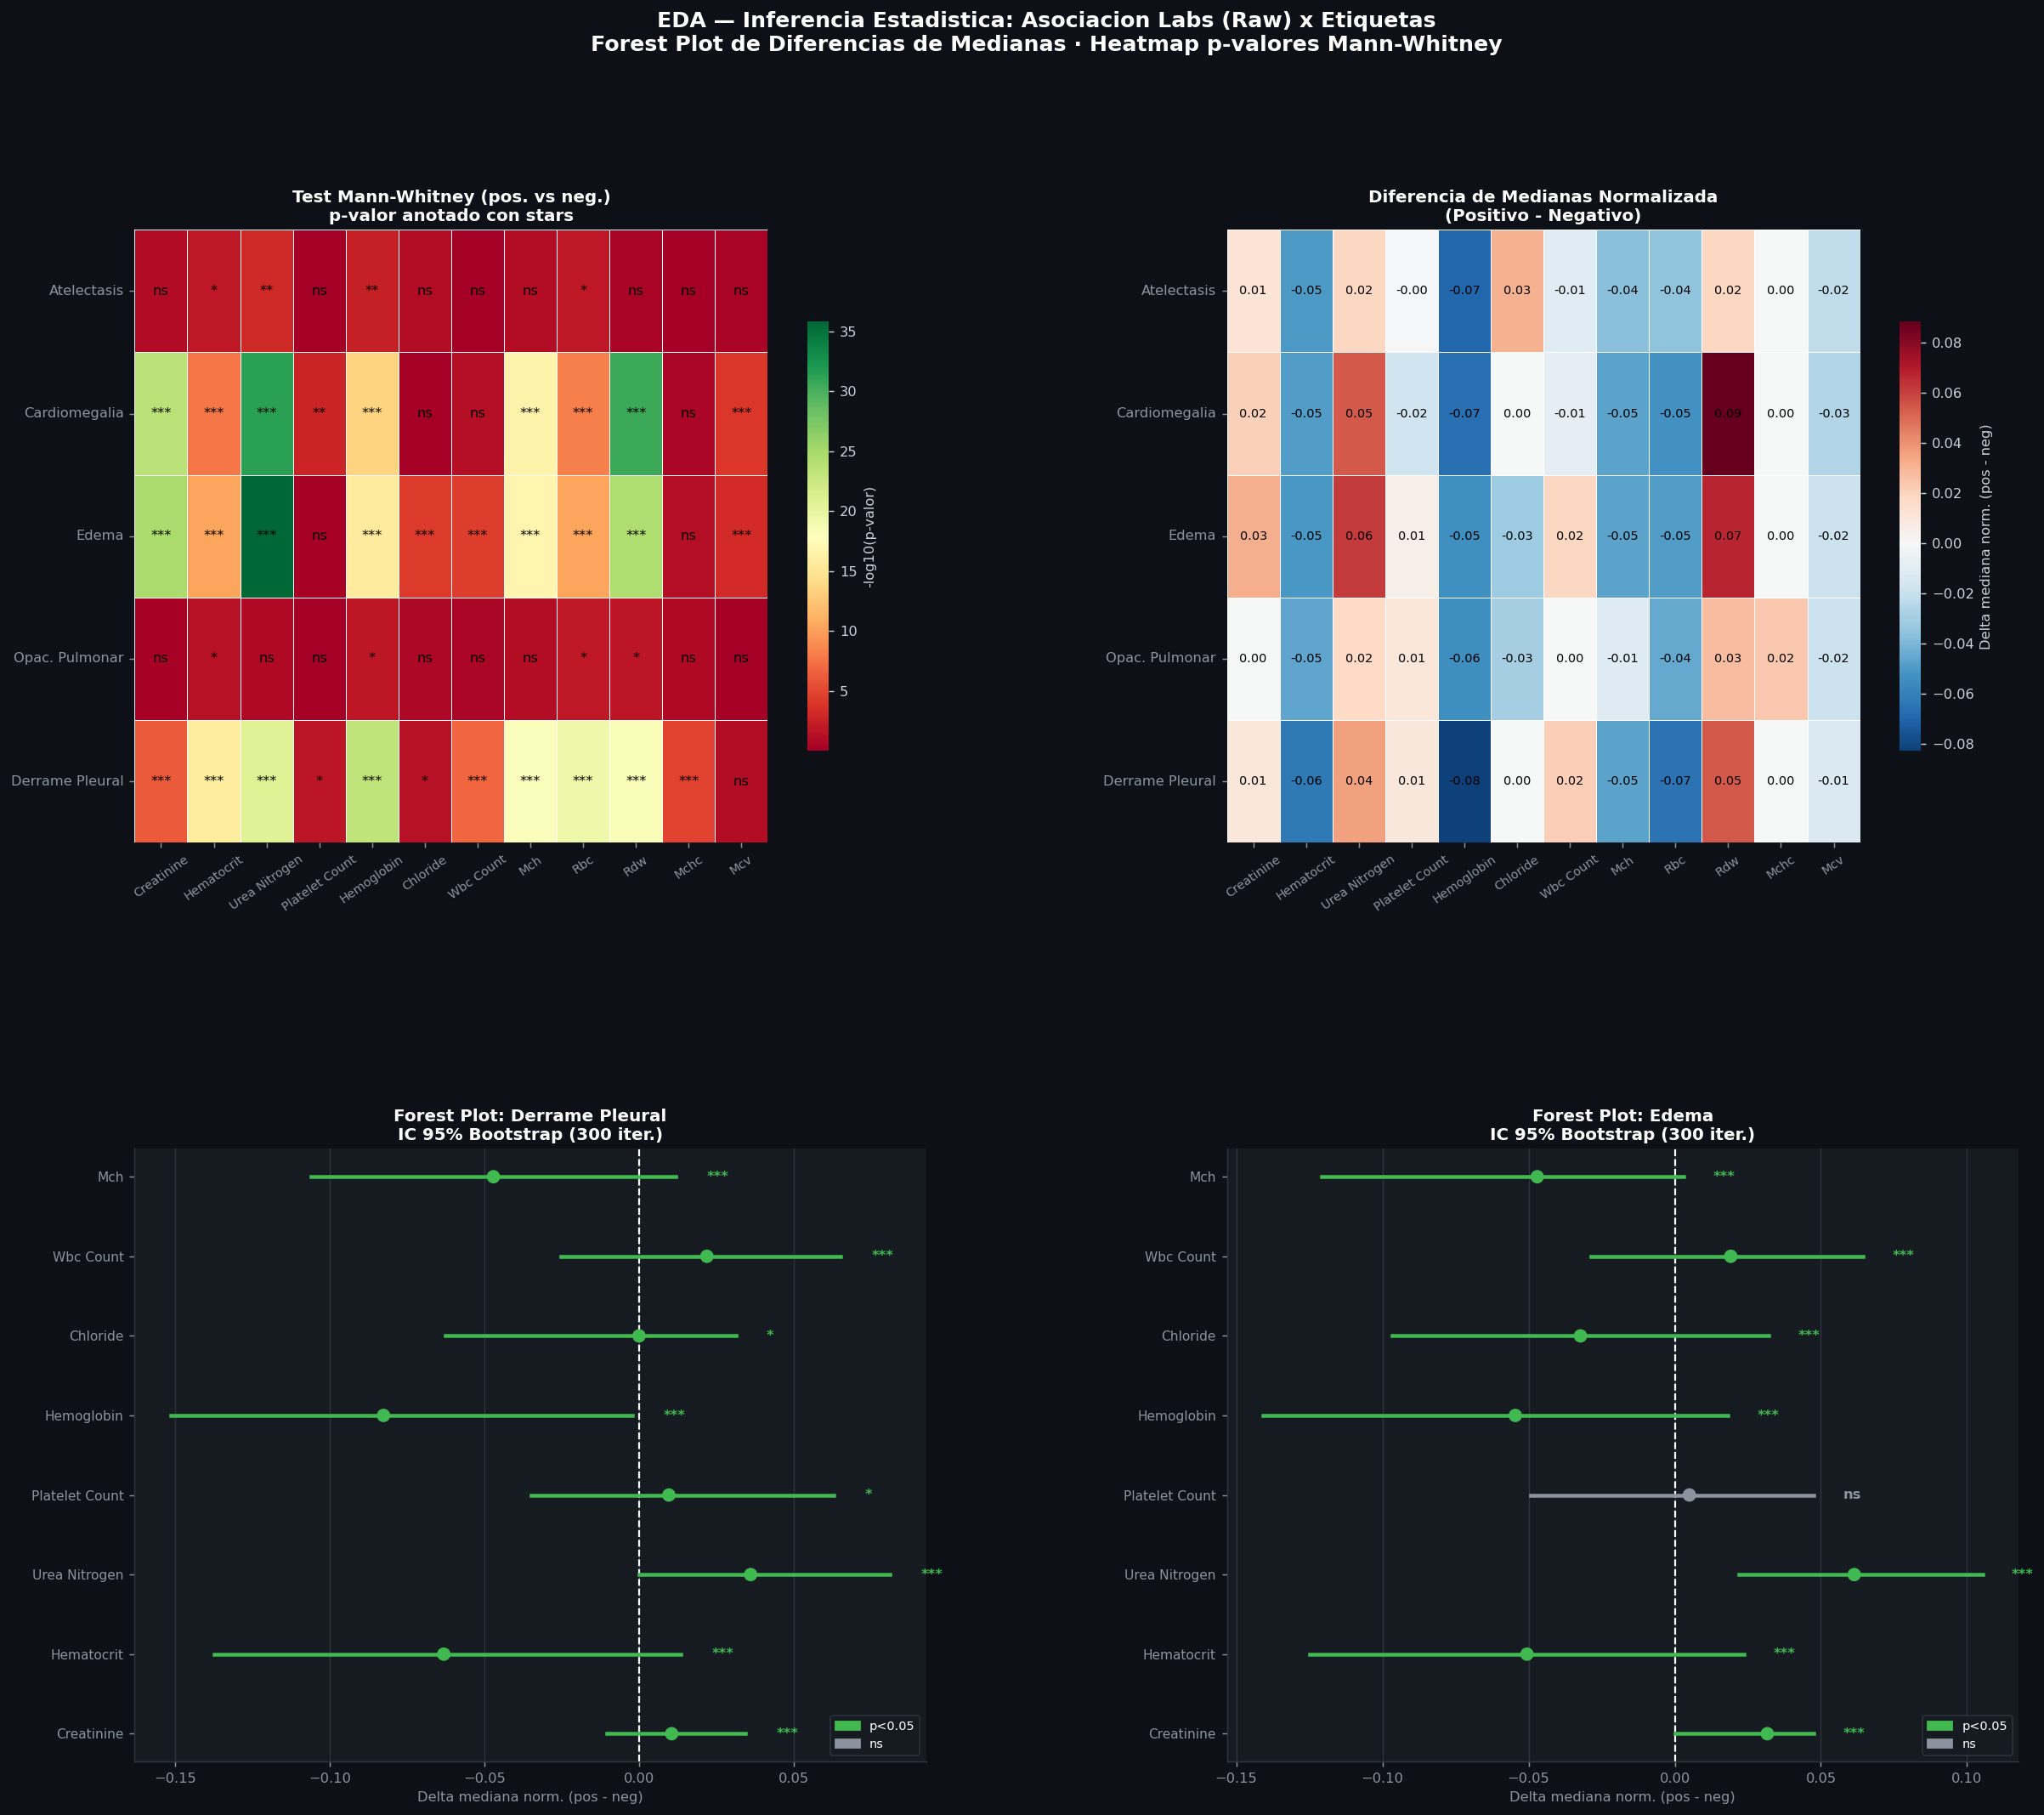

Bloque 9 guardado.


In [12]:
fig = plt.figure(figsize=(22, 18), facecolor=DARK_BG)
fig.suptitle('EDA — Inferencia Estadistica: Asociacion Labs (Raw) x Etiquetas\n'
             'Forest Plot de Diferencias de Medianas · Heatmap p-valores Mann-Whitney',
             fontsize=14, fontweight='bold', color='white', y=0.99)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.50, wspace=0.38)

raw_arr  = train[LAB_RAW_COLS].values.astype(float)
miss_raw = train[LAB_RAW_COLS].isnull().mean().values
top12_idx  = np.argsort(miss_raw)[:12]
top12_disp = [LAB_RAW_DISP[i] for i in top12_idx]
label_cols_nof3 = [lc for lc in LABEL_COLS if lc != 'No Finding']
label_disp_nof3 = [ld for lc, ld in zip(LABEL_COLS, LABEL_DISPLAY) if lc != 'No Finding']

ax0 = fig.add_subplot(gs[0, 0], facecolor=PANEL_BG)
pmat = pd.DataFrame(np.nan, index=label_disp_nof3, columns=top12_disp)
dmed_mat = pd.DataFrame(np.nan, index=label_disp_nof3, columns=top12_disp)
star_pmat = pd.DataFrame('', index=label_disp_nof3, columns=top12_disp)
for lc, ld in zip(label_cols_nof3, label_disp_nof3):
    for idx, lab_d in zip(top12_idx, top12_disp):
        pos_v = raw_arr[(train[lc]==1).values, idx]; pos_v = pos_v[~np.isnan(pos_v)]
        neg_v = raw_arr[(train[lc]==0).values, idx]; neg_v = neg_v[~np.isnan(neg_v)]
        if len(pos_v) >= 5 and len(neg_v) >= 5:
            u, p = stats.mannwhitneyu(pos_v, neg_v, alternative='two-sided')
            pmat.loc[ld, lab_d] = p
            all_v = np.concatenate([pos_v, neg_v])
            rng_v = np.nanpercentile(all_v, 99) - np.nanpercentile(all_v, 1) + 1e-9
            dmed_mat.loc[ld, lab_d] = (np.median(pos_v) - np.median(neg_v)) / rng_v
            star_pmat.loc[ld, lab_d] = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
log_p = -np.log10(pmat.astype(float) + 1e-300)
sns.heatmap(log_p, annot=star_pmat, fmt='', cmap='RdYlGn', ax=ax0, linewidths=0.5,
            cbar_kws={'shrink':0.7, 'label':'-log10(p-valor)'}, annot_kws={'size':9, 'color':'black'})
ax0.set_title('Test Mann-Whitney (pos. vs neg.)\np-valor anotado con stars', color='white')
ax0.tick_params(axis='x', rotation=35, labelsize=8, colors=C_GREY)
ax0.tick_params(axis='y', rotation=0, labelsize=9, colors=C_GREY)

ax1 = fig.add_subplot(gs[0, 1], facecolor=PANEL_BG)
sns.heatmap(dmed_mat.astype(float), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax1, linewidths=0.5,
            cbar_kws={'shrink':0.7, 'label':'Delta mediana norm. (pos - neg)'}, annot_kws={'size':8, 'color':'black'})
ax1.set_title('Diferencia de Medianas Normalizada\n(Positivo - Negativo)', color='white')
ax1.tick_params(axis='x', rotation=35, labelsize=8, colors=C_GREY)
ax1.tick_params(axis='y', rotation=0, labelsize=9, colors=C_GREY)

for ax_i, (lc, ld) in enumerate(zip(['Pleural Effusion','Edema'], ['Derrame Pleural','Edema'])):
    ax_f = fig.add_subplot(gs[1, ax_i], facecolor=PANEL_BG)
    top8_idx2 = np.argsort(miss_raw)[:8]
    deltas_f, lo_ci_f, hi_ci_f, pvals_f, labs_f = [], [], [], [], []
    for idx in top8_idx2:
        pos_v = raw_arr[(train[lc]==1).values, idx]; pos_v = pos_v[~np.isnan(pos_v)]
        neg_v = raw_arr[(train[lc]==0).values, idx]; neg_v = neg_v[~np.isnan(neg_v)]
        if len(pos_v) < 5 or len(neg_v) < 5: continue
        all_v = np.concatenate([pos_v, neg_v])
        rng_v = np.nanpercentile(all_v, 99) - np.nanpercentile(all_v, 1) + 1e-9
        d_f = (np.median(pos_v) - np.median(neg_v)) / rng_v
        _, p_f = stats.mannwhitneyu(pos_v, neg_v, alternative='two-sided')
        np.random.seed(42); bs_diffs = []
        for _ in range(300):
            bp_ = np.random.choice(pos_v, size=min(len(pos_v),100), replace=True)
            bn_ = np.random.choice(neg_v, size=min(len(neg_v),100), replace=True)
            bs_diffs.append((np.median(bp_) - np.median(bn_)) / rng_v)
        lo_ = np.percentile(bs_diffs, 2.5); hi_ = np.percentile(bs_diffs, 97.5)
        deltas_f.append(d_f); lo_ci_f.append(lo_); hi_ci_f.append(hi_)
        pvals_f.append(p_f); labs_f.append(LAB_RAW_DISP[idx])
    y_f = np.arange(len(labs_f)); colors_f = [C_GREEN if p < 0.05 else C_GREY for p in pvals_f]
    ax_f.scatter(deltas_f, y_f, color=colors_f, s=60, zorder=5)
    for i, (d_, lo_, hi_, p_) in enumerate(zip(deltas_f, lo_ci_f, hi_ci_f, pvals_f)):
        ax_f.plot([lo_, hi_], [i, i], color=colors_f[i], lw=2.5, zorder=4)
        sig_ = '***' if p_<0.001 else '**' if p_<0.01 else '*' if p_<0.05 else 'ns'
        ax_f.text(hi_+0.01, i, sig_, fontsize=9, va='center', color=colors_f[i], fontweight='bold')
    ax_f.axvline(0, color='white', lw=1.2, linestyle='--')
    ax_f.set_yticks(y_f); ax_f.set_yticklabels(labs_f, fontsize=8.5, color=C_GREY)
    ax_f.set_xlabel('Delta mediana norm. (pos - neg)', color=C_GREY)
    ax_f.set_title(f'Forest Plot: {ld}\nIC 95% Bootstrap (300 iter.)', color='white')
    ax_f.xaxis.grid(True, alpha=0.2, color=C_GREY); ax_f.tick_params(colors=C_GREY)
    leg_f = [mpatches.Patch(color=C_GREEN, label='p<0.05'), mpatches.Patch(color=C_GREY, label='ns')]
    ax_f.legend(handles=leg_f, fontsize=8, labelcolor='white', loc='lower right')

plt.savefig(out('block9_inference.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 9 guardado.")


---
## Bloque 10 — Clustering Jerárquico de Analíticas y Distribuciones Detalladas

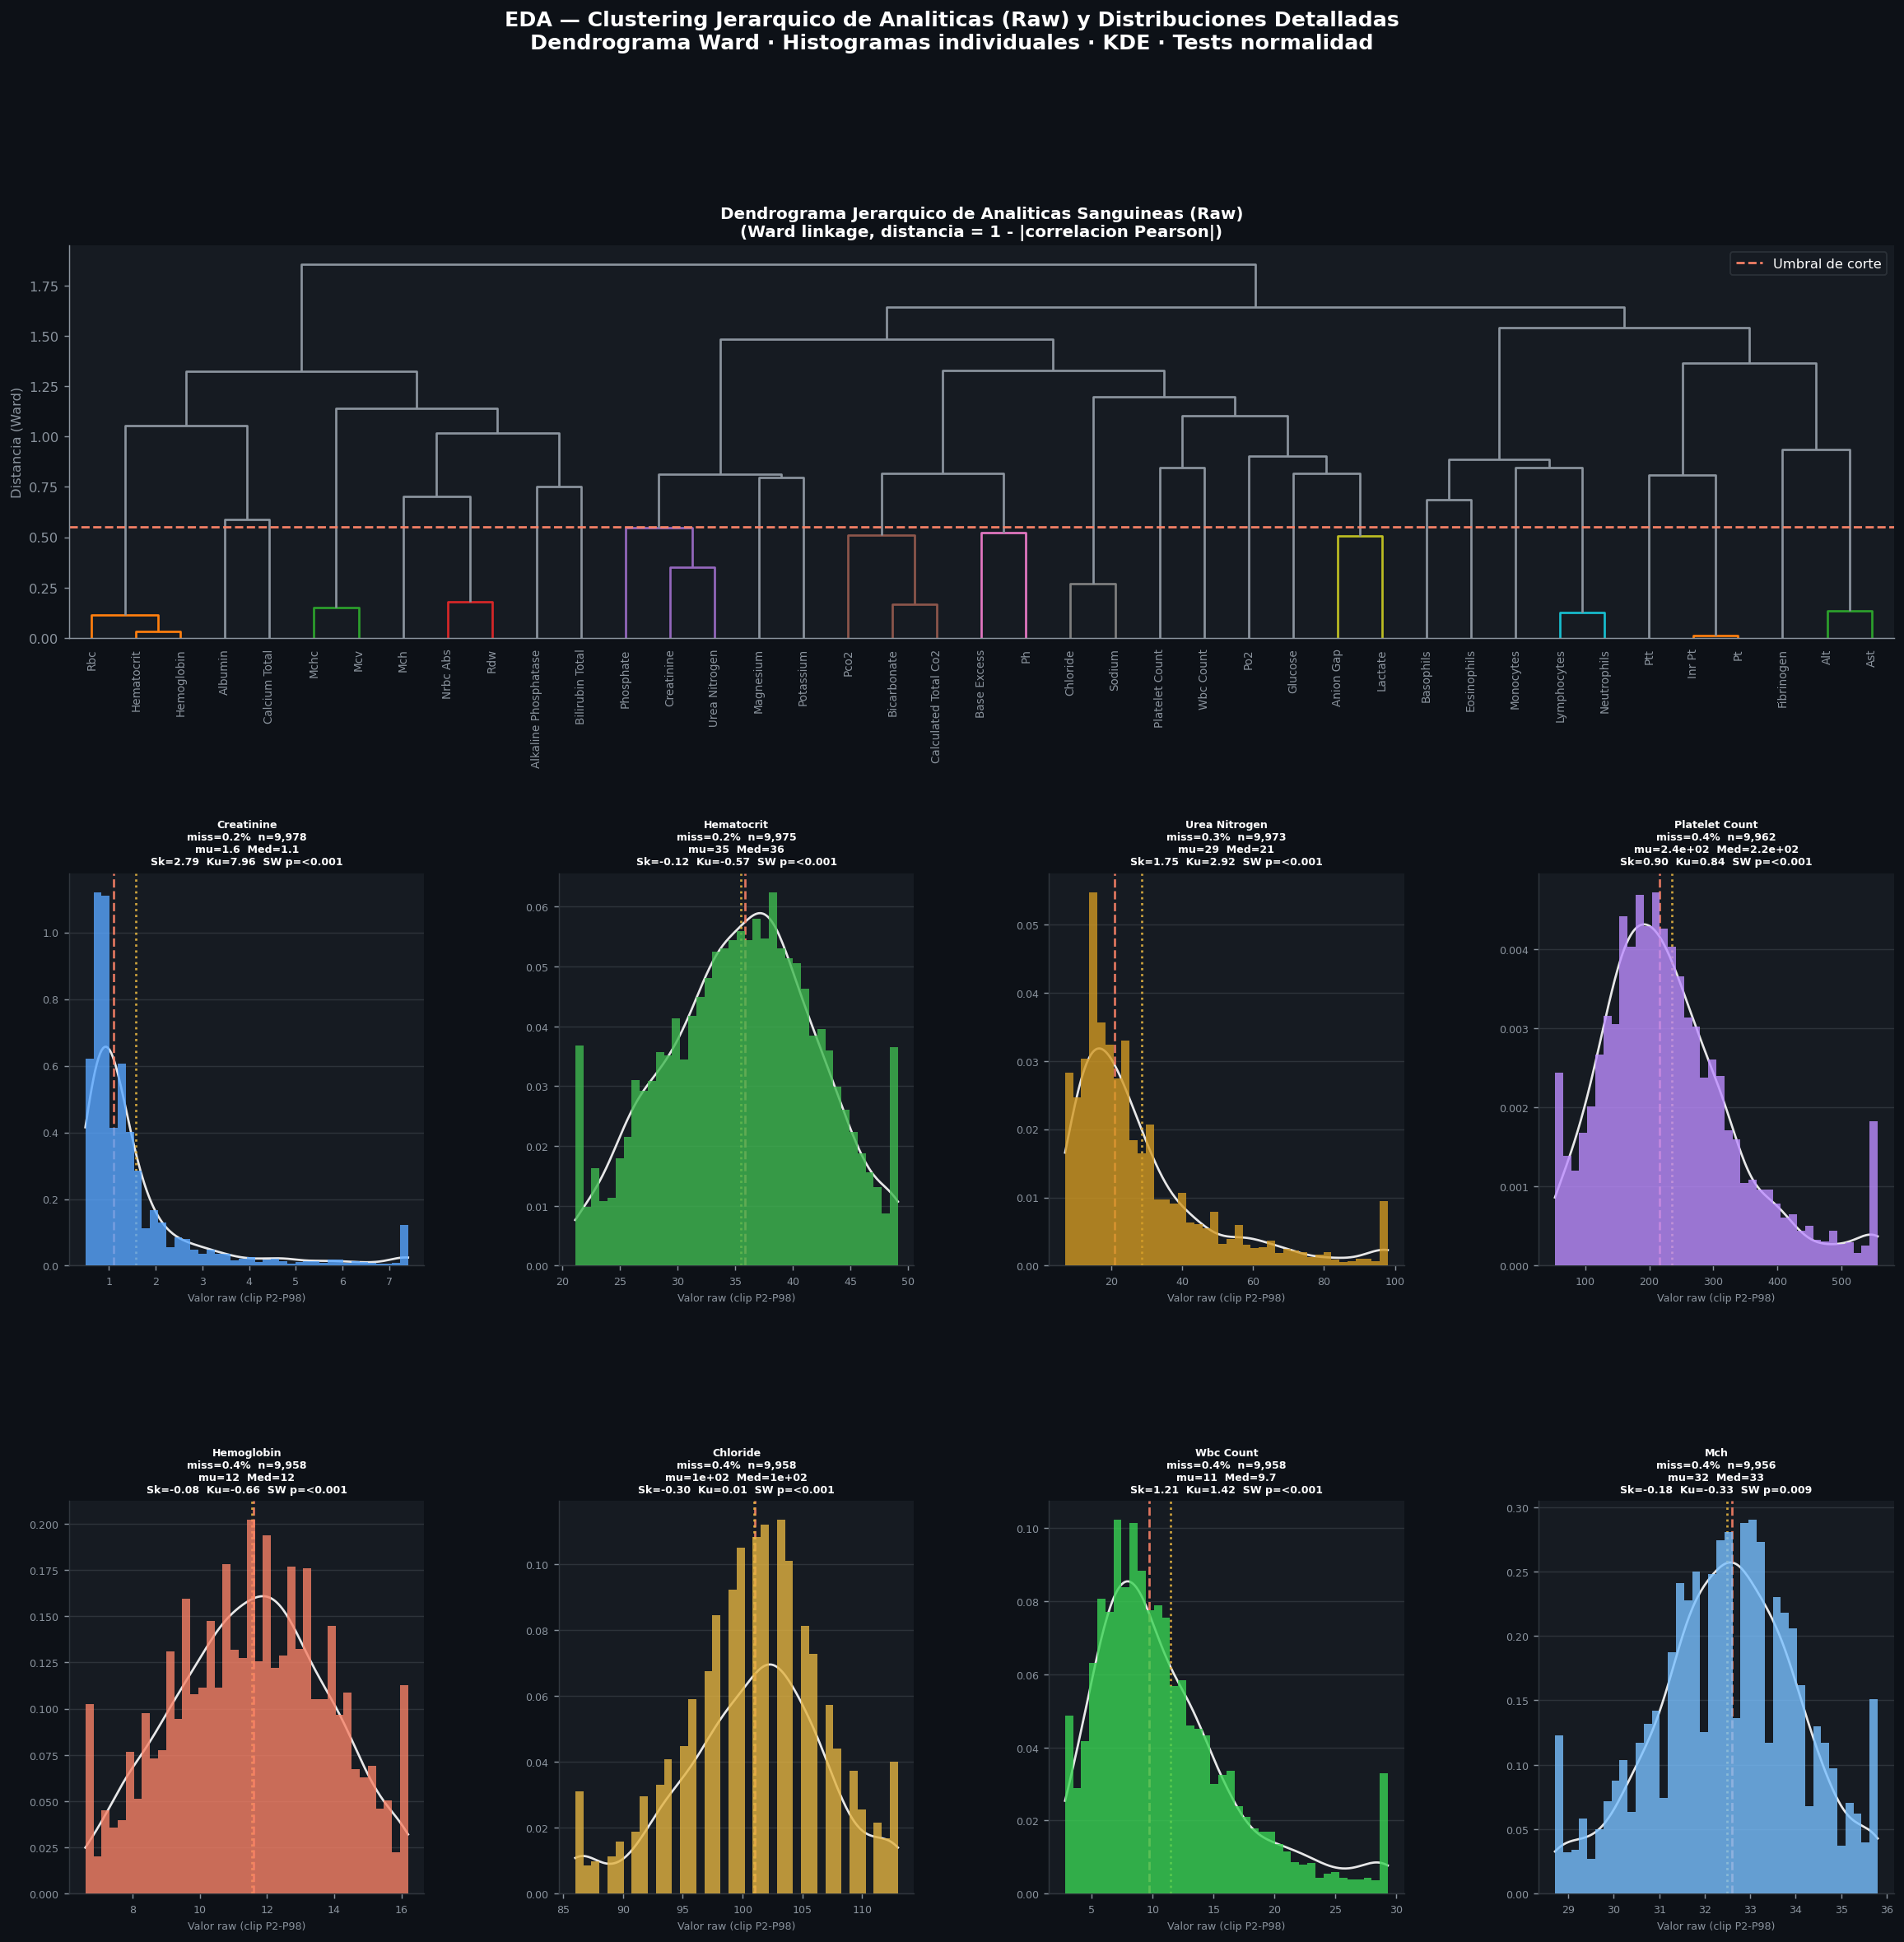

Bloque 10 guardado.


In [13]:
fig = plt.figure(figsize=(22, 20), facecolor=DARK_BG)
fig.suptitle('EDA — Clustering Jerarquico de Analiticas (Raw) y Distribuciones Detalladas\n'
             'Dendrograma Ward · Histogramas individuales · KDE · Tests normalidad',
             fontsize=14, fontweight='bold', color='white', y=0.99)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.6, wspace=0.38)

raw_arr  = train[LAB_RAW_COLS].values.astype(float)
miss_raw = train[LAB_RAW_COLS].isnull().mean().values

ax0 = fig.add_subplot(gs[0, 0:4], facecolor=PANEL_BG)
df_labs_raw = pd.DataFrame(raw_arr, columns=LAB_RAW_DISP)
corr_all = df_labs_raw.corr()
dist_mat = 1 - corr_all.abs().values
np.fill_diagonal(dist_mat, 0)
condensed = squareform(dist_mat, checks=False)
linkage_m = hierarchy.linkage(condensed, method='ward')
hierarchy.dendrogram(linkage_m, labels=LAB_RAW_DISP, ax=ax0,
                     color_threshold=0.55, leaf_rotation=90, leaf_font_size=7.5,
                     above_threshold_color=C_GREY)
ax0.set_title('Dendrograma Jerarquico de Analiticas Sanguineas (Raw)\n(Ward linkage, distancia = 1 - |correlacion Pearson|)', color='white')
ax0.set_ylabel('Distancia (Ward)', color=C_GREY)
ax0.axhline(0.55, color=C_PINK, linestyle='--', lw=1.5, label='Umbral de corte')
ax0.legend(fontsize=9, labelcolor='white')
ax0.tick_params(colors=C_GREY)
ax0.spines['bottom'].set_color(C_GREY); ax0.spines['left'].set_color(C_GREY)

low8_idx = np.argsort(miss_raw)[:8]
pal_hist = [C_CYAN, C_GREEN, C_ORANGE, C_PURPLE, C_PINK, C_YELLOW, C_TEAL, C_LBLUE]
rng_r = np.random.default_rng(42)
for ii, (idx, col_h) in enumerate(zip(low8_idx, pal_hist)):
    row_ = 1 + ii // 4; col_ = ii % 4
    ax_h = fig.add_subplot(gs[row_, col_], facecolor=PANEL_BG)
    obs = raw_arr[~np.isnan(raw_arr[:,idx]), idx]
    lo_, hi_ = np.percentile(obs, [2,98]); obs_c = np.clip(obs, lo_, hi_)
    ax_h.hist(obs_c, bins=40, color=col_h, edgecolor='none', alpha=0.8, density=True, zorder=3)
    try:
        from scipy.stats import gaussian_kde as gkde2
        sample_kde = obs_c[rng_r.choice(len(obs_c), min(1000, len(obs_c)), replace=False)]
        kde_h = gkde2(sample_kde)
        kx_h = np.linspace(lo_, hi_, 200)
        ax_h.plot(kx_h, kde_h(kx_h), color='white', lw=1.5, alpha=0.9)
    except Exception: pass
    ax_h.axvline(np.nanmedian(obs), color=C_PINK, lw=1.5, linestyle='--', alpha=0.9)
    ax_h.axvline(np.nanmean(obs), color=C_YELLOW, lw=1.5, linestyle=':', alpha=0.9)
    sk_h = stats.skew(obs_c); ku_h = stats.kurtosis(obs_c)
    sample_sw = obs_c[rng_r.choice(len(obs_c), min(500, len(obs_c)), replace=False)]
    _, p_sw_h = stats.shapiro(sample_sw)
    sw_t = '<0.001' if p_sw_h < 0.001 else f'{p_sw_h:.3f}'
    ax_h.set_title(f'{LAB_RAW_DISP[idx]}\nmiss={miss_raw[idx]*100:.1f}%  n={len(obs):,}\n'
                   f'mu={np.mean(obs):.2g}  Med={np.median(obs):.2g}\n'
                   f'Sk={sk_h:.2f}  Ku={ku_h:.2f}  SW p={sw_t}', color='white', fontsize=7)
    ax_h.set_xlabel('Valor raw (clip P2-P98)', color=C_GREY, fontsize=7)
    ax_h.tick_params(labelsize=7, colors=C_GREY); ax_h.yaxis.grid(True, alpha=0.2, color=C_GREY)

plt.savefig(out('block10_dendrogram.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 10 guardado.")


---
## Bloque 11 — 🆕 PCA y t-SNE sobre Labs Raw
> **Objetivo:** visualizar el espacio latente de las analíticas e identificar si los diagnósticos forman
> agrupaciones separables en dimensiones reducidas.  
> Se añade el scree plot para guiar la elección de dimensionalidad en el modelo multimodal.


Bloque 11: PCA + t-SNE sobre Labs Raw
  Calculando t-SNE...


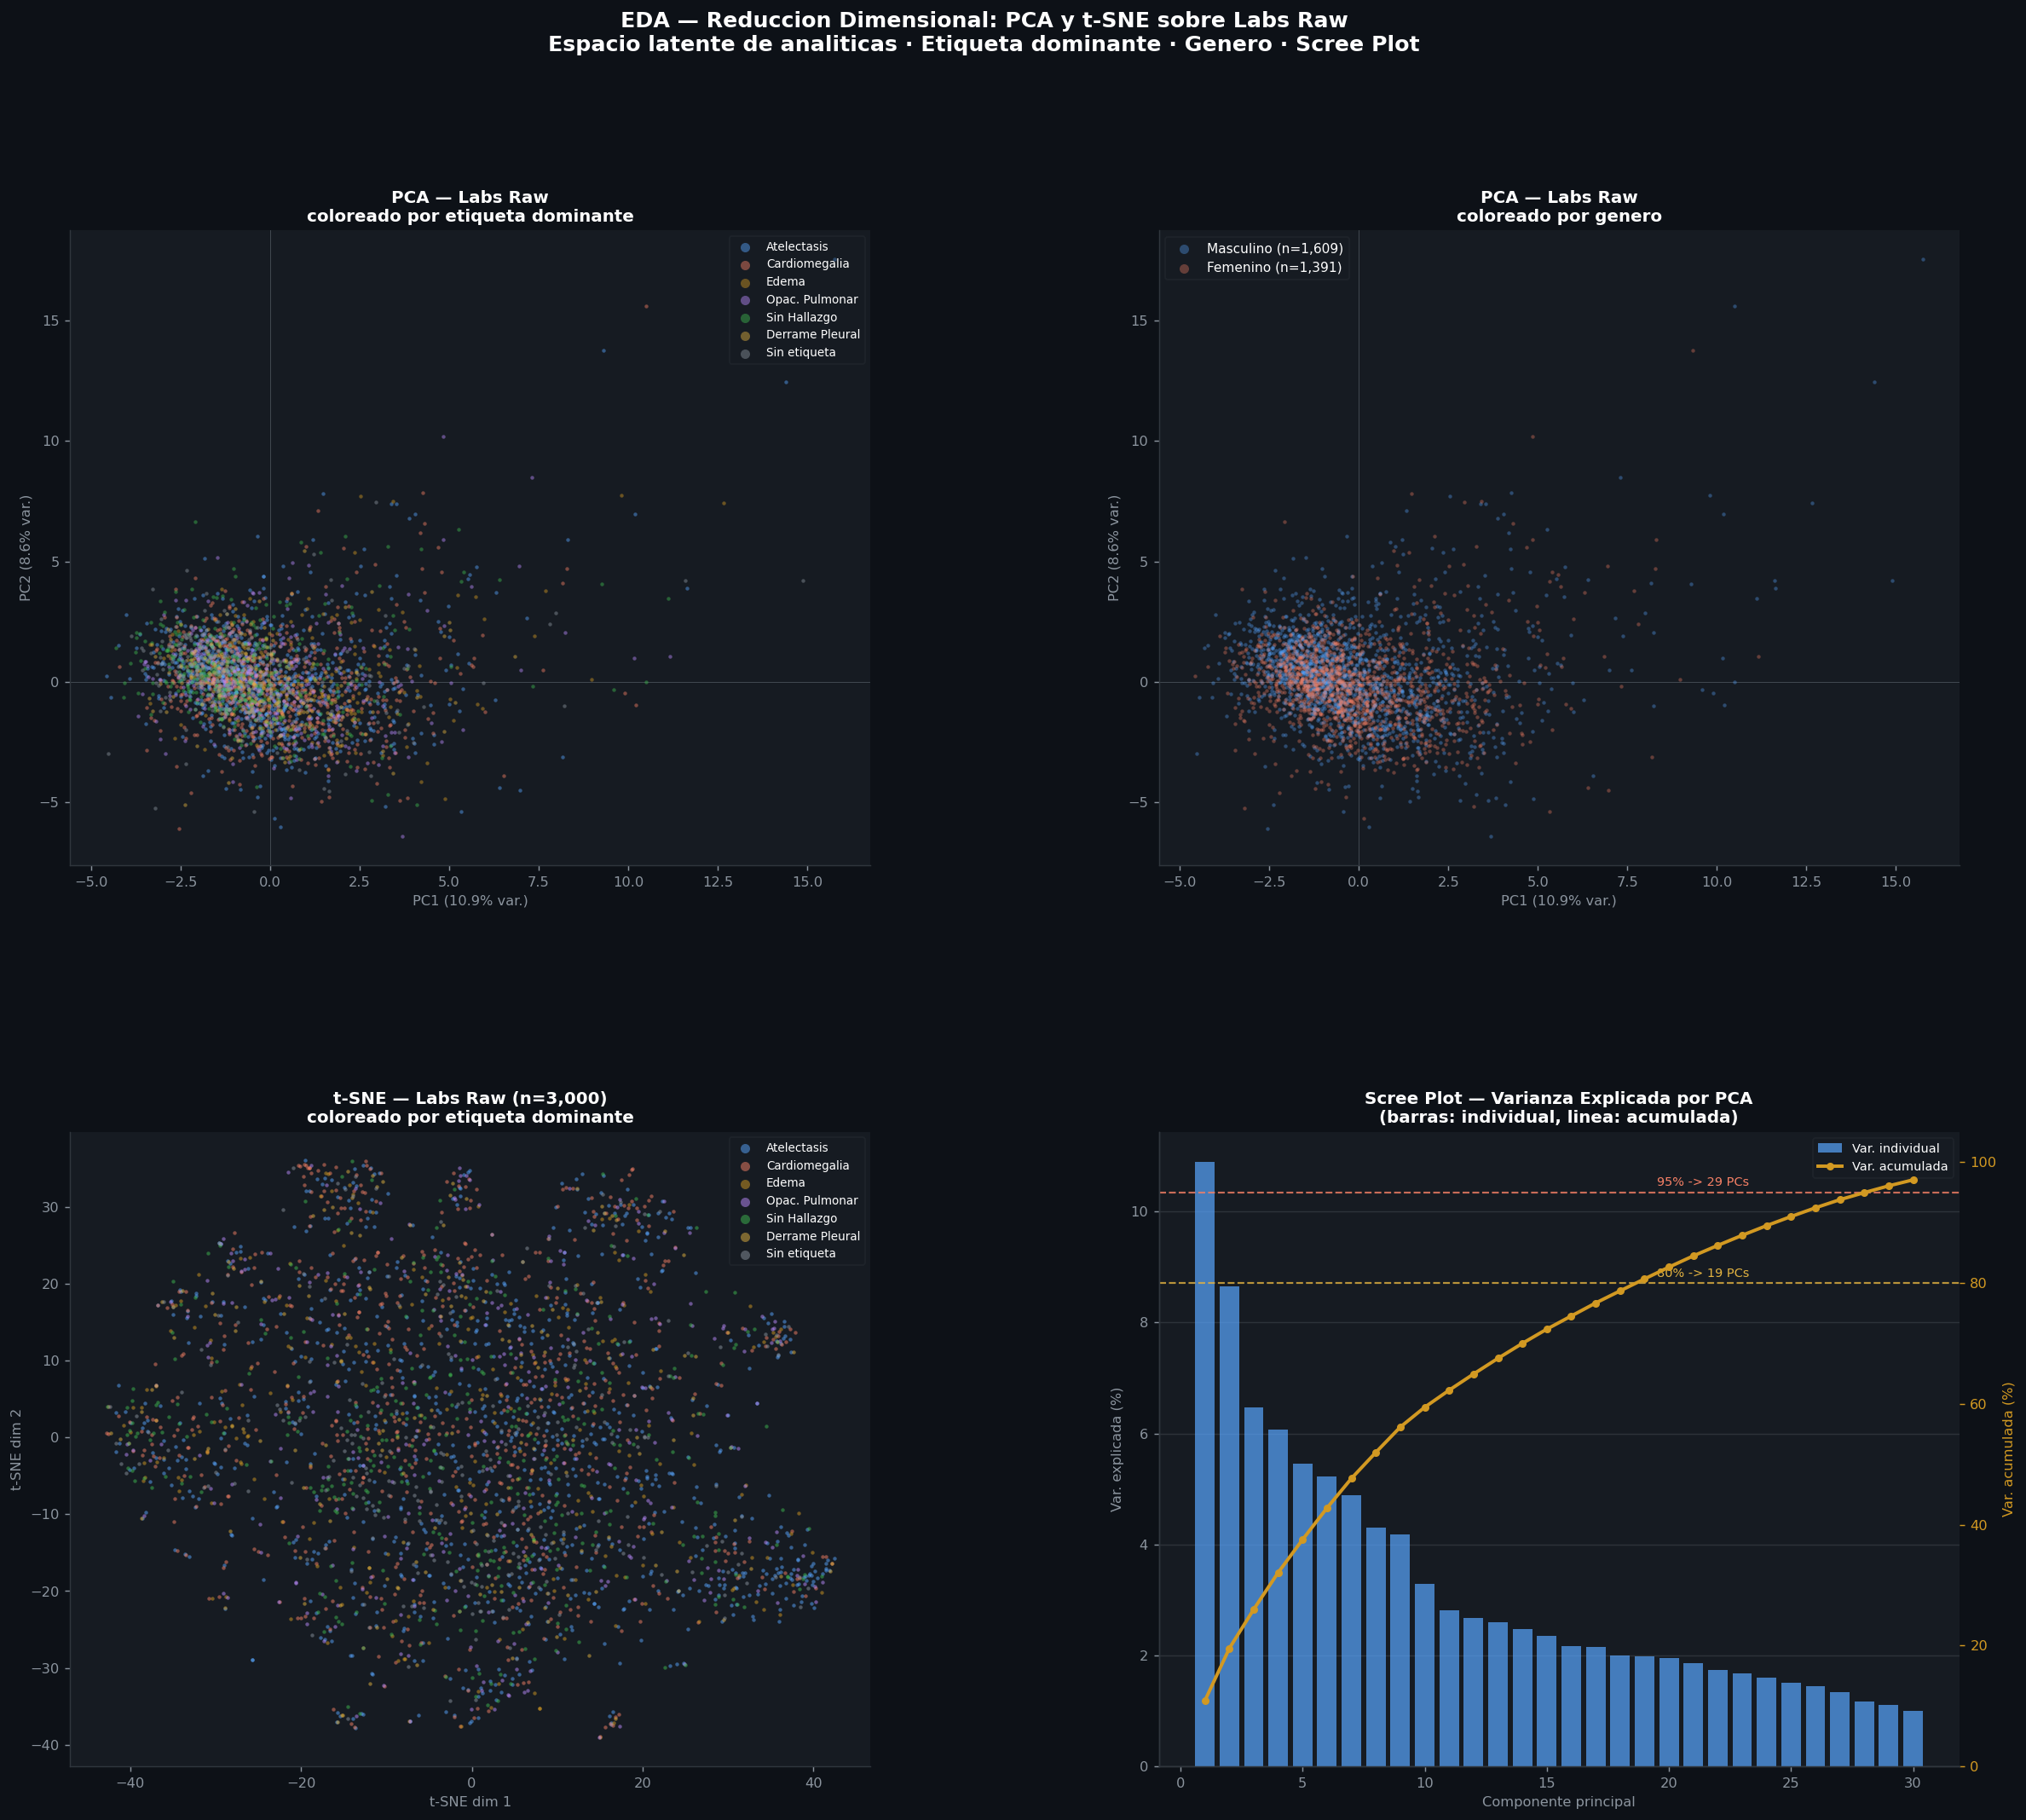

Bloque 11 guardado.


In [14]:
print("Bloque 11: PCA + t-SNE sobre Labs Raw")

# ── Preparación compartida (reutilizable) ──
_imp     = SimpleImputer(strategy='median')
X_imp    = _imp.fit_transform(train[LAB_RAW_COLS].astype(float))
X_scaled = StandardScaler().fit_transform(X_imp)

def etiqueta_dominante(row):
    for lc in LABEL_COLS:
        if row[lc] == 1:
            return lc
    return 'Ninguna'

dom_label = train.apply(etiqueta_dominante, axis=1).values

LAB_COLORS_MAP = {
    'Atelectasis':      C_CYAN,
    'Cardiomegaly':     C_PINK,
    'Edema':            C_ORANGE,
    'Lung Opacity':     C_PURPLE,
    'No Finding':       C_GREEN,
    'Pleural Effusion': C_YELLOW,
    'Ninguna':          C_GREY,
}
LAB_DISPLAY_MAP = dict(zip(LABEL_COLS, LABEL_DISPLAY))
LAB_DISPLAY_MAP['Ninguna'] = 'Sin etiqueta'

rng      = np.random.default_rng(42)
N_SUB    = min(3000, len(X_scaled))
idx_sub  = rng.choice(len(X_scaled), size=N_SUB, replace=False)
X_sub    = X_scaled[idx_sub]
dom_sub  = dom_label[idx_sub]
gen_sub  = train['gender'].values[idx_sub]

pca = PCA(n_components=2, random_state=42)
Z_pca = pca.fit_transform(X_scaled)
Z_pca_sub = Z_pca[idx_sub]
var1, var2 = pca.explained_variance_ratio_ * 100

print("  Calculando t-SNE...")
tsne  = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=800, init='pca')
Z_tsne = tsne.fit_transform(X_sub)

fig = plt.figure(figsize=(22, 18), facecolor=DARK_BG)
fig.suptitle('EDA — Reduccion Dimensional: PCA y t-SNE sobre Labs Raw\n'
             'Espacio latente de analiticas · Etiqueta dominante · Genero · Scree Plot',
             fontsize=14, fontweight='bold', color='white', y=0.99)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.36)

ax0 = fig.add_subplot(gs[0, 0], facecolor=PANEL_BG)
for lbl, col in LAB_COLORS_MAP.items():
    mask = dom_sub == lbl
    if mask.sum() == 0: continue
    ax0.scatter(Z_pca_sub[mask, 0], Z_pca_sub[mask, 1], s=6, alpha=0.45, color=col, linewidths=0,
                label=LAB_DISPLAY_MAP.get(lbl, lbl), zorder=3)
ax0.set_xlabel(f'PC1 ({var1:.1f}% var.)', color=C_GREY); ax0.set_ylabel(f'PC2 ({var2:.1f}% var.)', color=C_GREY)
ax0.set_title('PCA — Labs Raw\ncoloreado por etiqueta dominante', color='white')
ax0.legend(fontsize=7.5, labelcolor='white', markerscale=2.5, loc='upper right', framealpha=0.3)
ax0.tick_params(colors=C_GREY); ax0.axhline(0, color=C_GREY, lw=0.5, alpha=0.4); ax0.axvline(0, color=C_GREY, lw=0.5, alpha=0.4)

ax1 = fig.add_subplot(gs[0, 1], facecolor=PANEL_BG)
for g_val, g_lbl, g_col in [(1, 'Masculino', C_CYAN), (0, 'Femenino', C_PINK)]:
    mask = gen_sub == g_val
    ax1.scatter(Z_pca_sub[mask, 0], Z_pca_sub[mask, 1], s=6, alpha=0.35, color=g_col, linewidths=0,
                label=f'{g_lbl} (n={mask.sum():,})', zorder=3)
ax1.set_xlabel(f'PC1 ({var1:.1f}% var.)', color=C_GREY); ax1.set_ylabel(f'PC2 ({var2:.1f}% var.)', color=C_GREY)
ax1.set_title('PCA — Labs Raw\ncoloreado por genero', color='white')
ax1.legend(fontsize=8.5, labelcolor='white', markerscale=2.5, framealpha=0.3)
ax1.tick_params(colors=C_GREY); ax1.axhline(0, color=C_GREY, lw=0.5, alpha=0.4); ax1.axvline(0, color=C_GREY, lw=0.5, alpha=0.4)

ax2 = fig.add_subplot(gs[1, 0], facecolor=PANEL_BG)
for lbl, col in LAB_COLORS_MAP.items():
    mask = dom_sub == lbl
    if mask.sum() == 0: continue
    ax2.scatter(Z_tsne[mask, 0], Z_tsne[mask, 1], s=6, alpha=0.5, color=col, linewidths=0,
                label=LAB_DISPLAY_MAP.get(lbl, lbl), zorder=3)
ax2.set_xlabel('t-SNE dim 1', color=C_GREY); ax2.set_ylabel('t-SNE dim 2', color=C_GREY)
ax2.set_title(f't-SNE — Labs Raw (n={N_SUB:,})\ncoloreado por etiqueta dominante', color='white')
ax2.legend(fontsize=7.5, labelcolor='white', markerscale=2.5, loc='upper right', framealpha=0.3)
ax2.tick_params(colors=C_GREY)

ax3 = fig.add_subplot(gs[1, 1], facecolor=PANEL_BG)
pca_full = PCA(random_state=42).fit(X_scaled)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_comp_80 = np.searchsorted(cum_var, 80) + 1; n_comp_95 = np.searchsorted(cum_var, 95) + 1
N_SHOW = min(30, len(cum_var))
ax3.bar(range(1, N_SHOW + 1), pca_full.explained_variance_ratio_[:N_SHOW] * 100,
        color=C_CYAN, edgecolor='none', alpha=0.7, label='Var. individual', zorder=3)
ax3_r = ax3.twinx()
ax3_r.plot(range(1, N_SHOW + 1), cum_var[:N_SHOW], color=C_ORANGE, lw=2.2, marker='o', markersize=4,
           label='Var. acumulada', zorder=5)
ax3_r.axhline(80, color=C_YELLOW, lw=1.2, linestyle='--', alpha=0.8)
ax3_r.axhline(95, color=C_PINK, lw=1.2, linestyle='--', alpha=0.8)
ax3_r.text(N_SHOW * 0.65, 81, f'80% -> {n_comp_80} PCs', color=C_YELLOW, fontsize=8)
ax3_r.text(N_SHOW * 0.65, 96, f'95% -> {n_comp_95} PCs', color=C_PINK, fontsize=8)
ax3_r.set_ylabel('Var. acumulada (%)', color=C_ORANGE); ax3_r.tick_params(colors=C_ORANGE)
ax3_r.set_ylim(0, 105); ax3_r.spines['right'].set_color(C_ORANGE)
ax3.set_xlabel('Componente principal', color=C_GREY); ax3.set_ylabel('Var. explicada (%)', color=C_GREY)
ax3.set_title('Scree Plot — Varianza Explicada por PCA\n(barras: individual, linea: acumulada)', color='white')
ax3.tick_params(colors=C_GREY); ax3.yaxis.grid(True, alpha=0.2, color=C_GREY)
lines1, labels1 = ax3.get_legend_handles_labels(); lines2, labels2 = ax3_r.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=8, labelcolor='white', framealpha=0.3)

plt.savefig(out('block11_pca_tsne.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 11 guardado.")


---
## Bloque 12 — 🆕 Co-ocurrencia ampliada, Jaccard y Correlación Spearman Labs × Etiquetas
> Complementa el Bloque 3 con métricas de asociación más detalladas:
> prevalencias relativas de co-diagnóstico, índice Jaccard fuera de diagonal
> y correlación Spearman entre los labs de mayor varianza y cada etiqueta.
> El panel de género × etiqueta añade el test χ² con Δ prevalencia.


Bloque 12: Co-ocurrencia + Spearman + Genero x Etiqueta


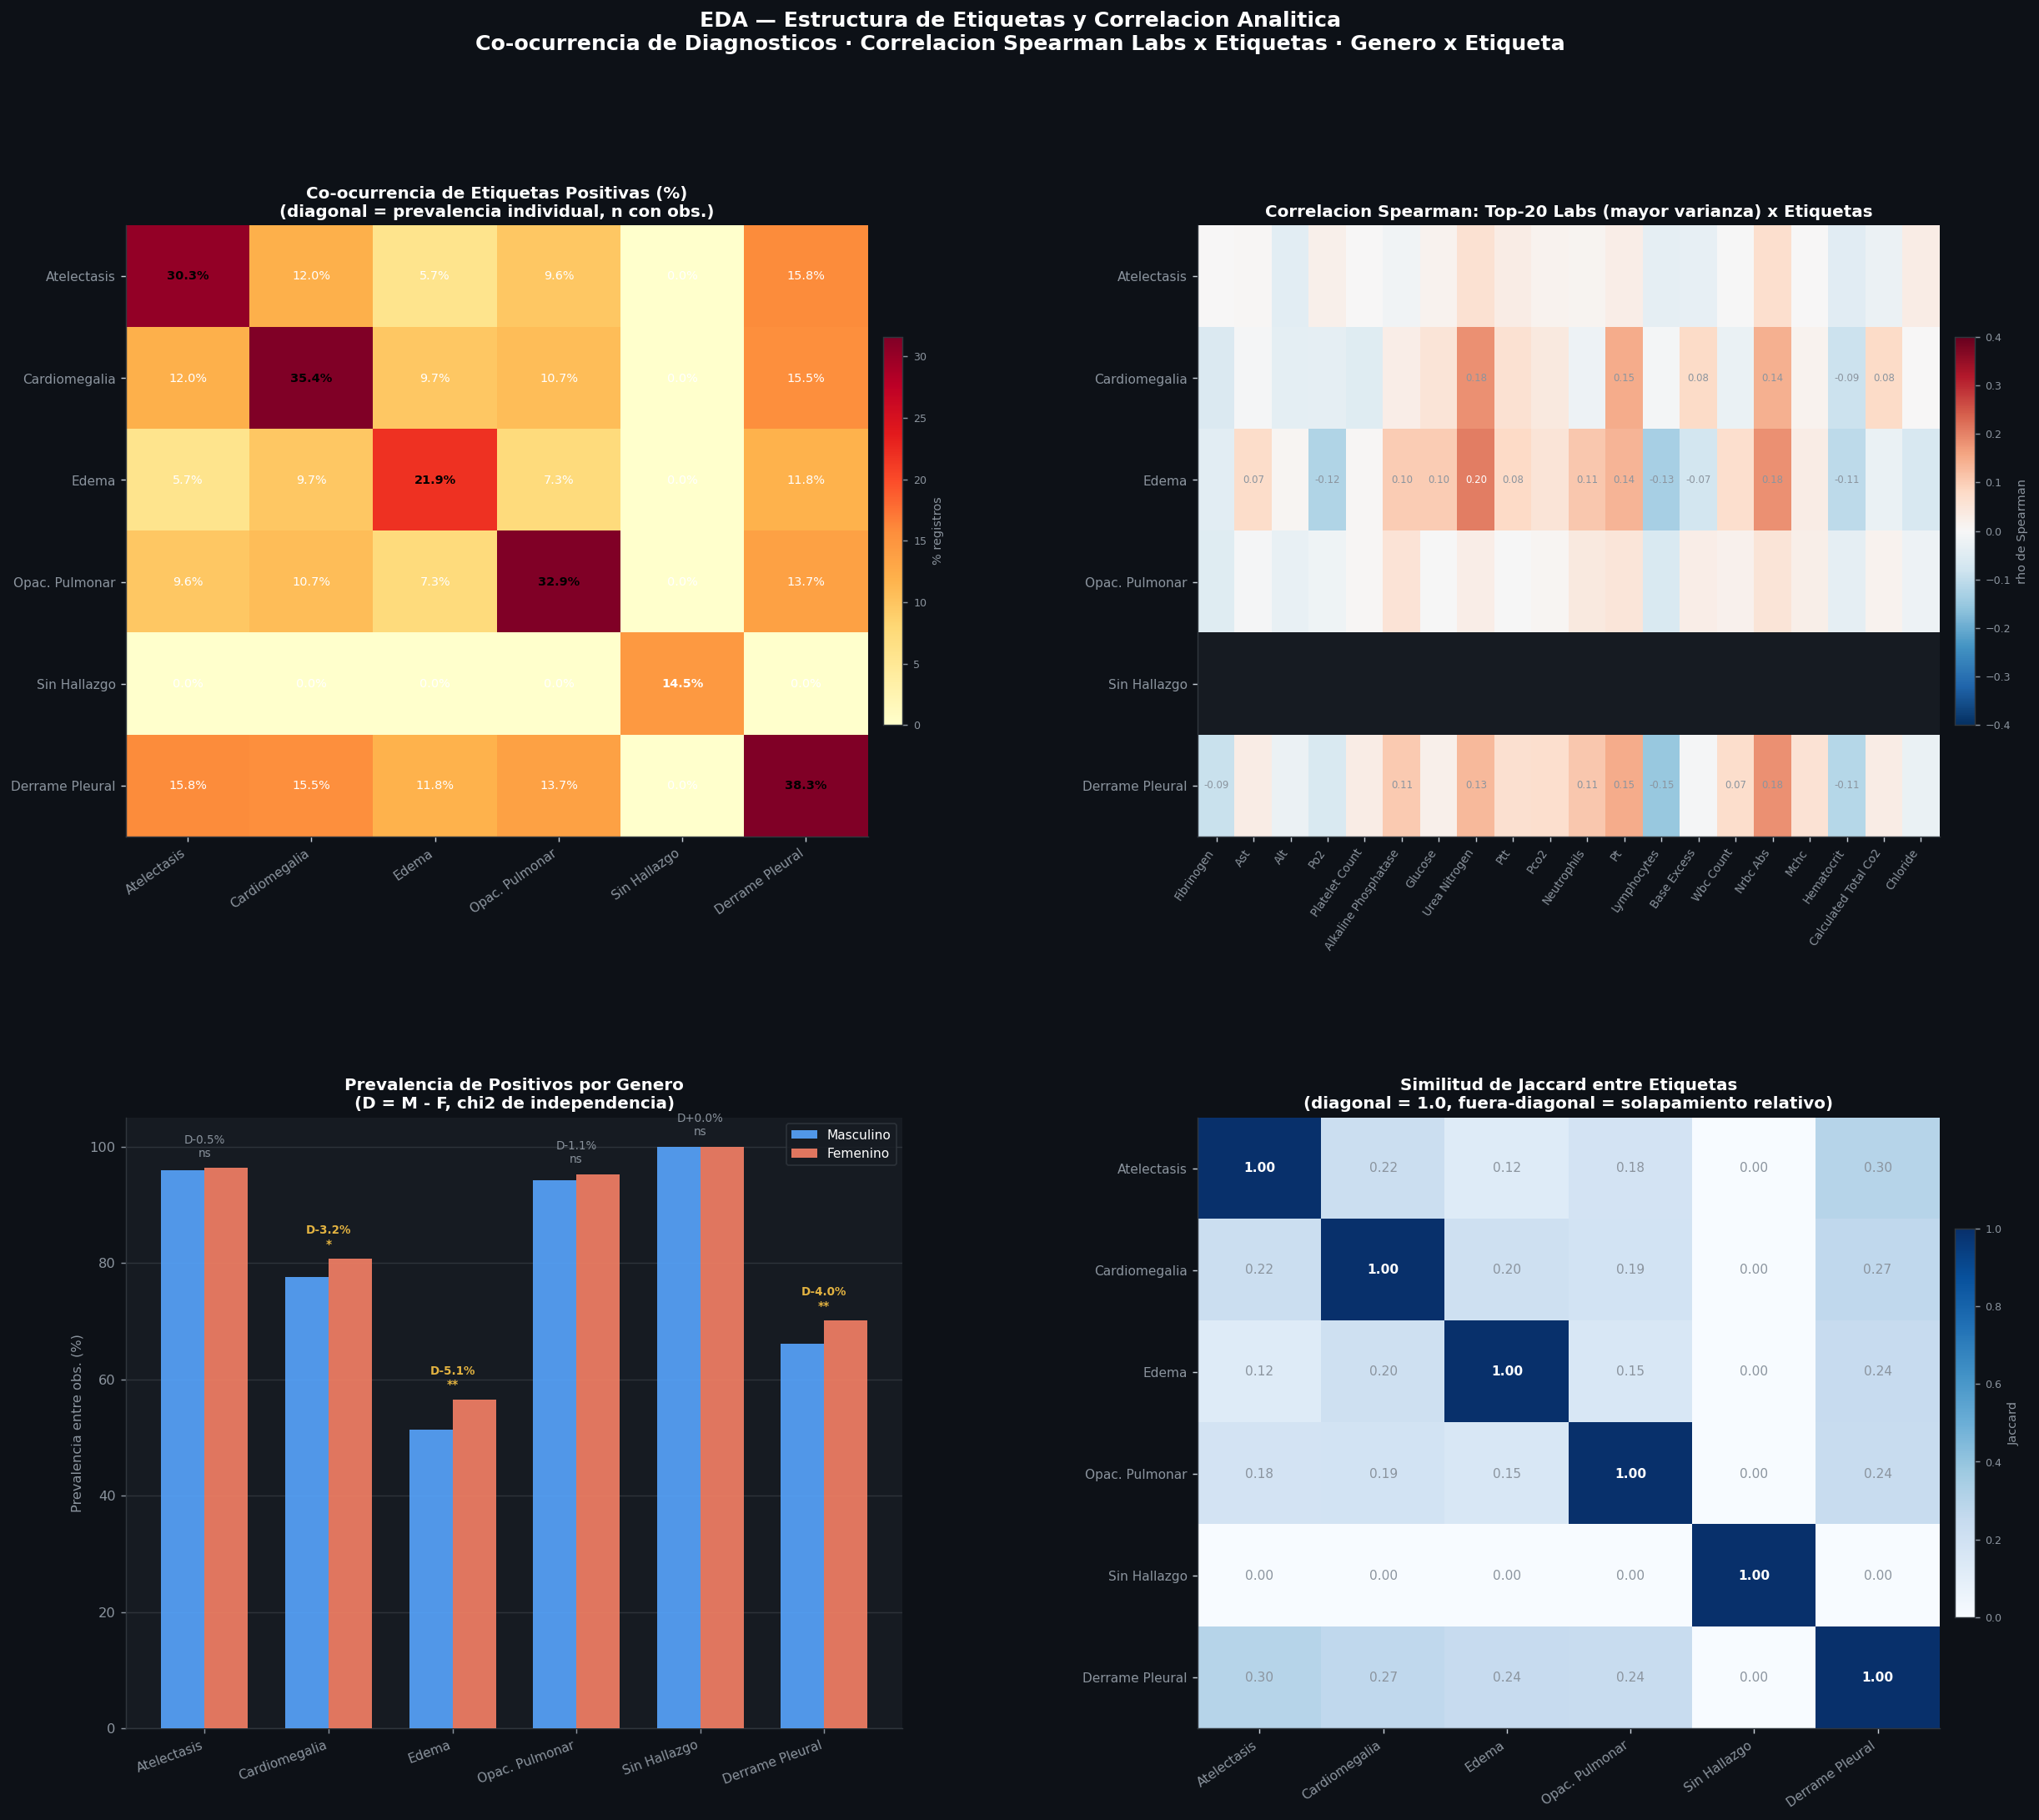

Bloque 12 guardado.


In [15]:
print("Bloque 12: Co-ocurrencia + Spearman + Genero x Etiqueta")

fig = plt.figure(figsize=(22, 18), facecolor=DARK_BG)
fig.suptitle('EDA — Estructura de Etiquetas y Correlacion Analitica\n'
             'Co-ocurrencia de Diagnosticos · Correlacion Spearman Labs x Etiquetas · Genero x Etiqueta',
             fontsize=14, fontweight='bold', color='white', y=0.99)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.46, wspace=0.38)

# ── Panel 1: Matriz de co-ocurrencia (% sobre observados) ─────────────────
ax0 = fig.add_subplot(gs[0, 0], facecolor=PANEL_BG)
has_obs  = train[LABEL_COLS].apply(lambda row: ((row == 0) | (row == 1)).any(), axis=1)
df_cooc  = train[has_obs]; n_cooc = len(df_cooc)
cooc_mat = np.zeros((len(LABEL_COLS), len(LABEL_COLS)), dtype=float)
for i, lc_i in enumerate(LABEL_COLS):
    for j, lc_j in enumerate(LABEL_COLS):
        if i == j:
            cooc_mat[i, j] = (df_cooc[lc_i] == 1).sum() / n_cooc * 100
        else:
            cooc_mat[i, j] = ((df_cooc[lc_i] == 1) & (df_cooc[lc_j] == 1)).sum() / n_cooc * 100
vmax_cooc = np.percentile(cooc_mat[cooc_mat > 0], 90)
im0 = ax0.imshow(cooc_mat, aspect='auto', cmap='YlOrRd', vmin=0, vmax=vmax_cooc)
ax0.set_xticks(range(len(LABEL_COLS))); ax0.set_xticklabels(LABEL_DISPLAY, rotation=35, ha='right', fontsize=8.5, color=C_GREY)
ax0.set_yticks(range(len(LABEL_COLS))); ax0.set_yticklabels(LABEL_DISPLAY, fontsize=8.5, color=C_GREY)
ax0.set_title('Co-ocurrencia de Etiquetas Positivas (%)\n(diagonal = prevalencia individual, n con obs.)', color='white')
for i in range(len(LABEL_COLS)):
    for j in range(len(LABEL_COLS)):
        v = cooc_mat[i, j]
        ax0.text(j, i, f'{v:.1f}%', ha='center', va='center', fontsize=8,
                 color='black' if v > vmax_cooc * 0.65 else 'white', fontweight='bold' if i == j else 'normal')
cbar0 = fig.colorbar(im0, ax=ax0, fraction=0.025, pad=0.02)
cbar0.ax.tick_params(colors=C_GREY, labelsize=7); cbar0.set_label('% registros', color=C_GREY, fontsize=8)

# ── Panel 2: Heatmap Spearman Top-20 Labs x Etiquetas ────────────────────
ax1 = fig.add_subplot(gs[0, 1], facecolor=PANEL_BG)
raw_arr  = train[LAB_RAW_COLS].values.astype(float)
N_LABS_HM   = 20
lab_var      = train[LAB_RAW_COLS].var(ddof=1)
top_labs_idx = lab_var.nlargest(N_LABS_HM).index.tolist()
top_labs_disp = [LAB_RAW_DISP[LAB_RAW_COLS.index(c)] for c in top_labs_idx]
corr_mat = np.full((len(LABEL_COLS), N_LABS_HM), np.nan)
for i, lc in enumerate(LABEL_COLS):
    mask_obs = train[lc].isin([0, 1])
    y_bin    = train.loc[mask_obs, lc].values
    for j, lab in enumerate(top_labs_idx):
        x_lab = train.loc[mask_obs, lab].values; valid = ~np.isnan(x_lab)
        if valid.sum() >= 10:
            r, _ = stats.spearmanr(x_lab[valid], y_bin[valid])
            corr_mat[i, j] = r
im1 = ax1.imshow(corr_mat, aspect='auto', cmap='RdBu_r', vmin=-0.4, vmax=0.4)
ax1.set_xticks(range(N_LABS_HM)); ax1.set_xticklabels(top_labs_disp, rotation=55, ha='right', fontsize=7.5, color=C_GREY)
ax1.set_yticks(range(len(LABEL_COLS))); ax1.set_yticklabels(LABEL_DISPLAY, fontsize=8.5, color=C_GREY)
ax1.set_title(f'Correlacion Spearman: Top-{N_LABS_HM} Labs (mayor varianza) x Etiquetas', color='white')
for i in range(len(LABEL_COLS)):
    for j in range(N_LABS_HM):
        v = corr_mat[i, j]
        if not np.isnan(v) and abs(v) >= 0.07:
            ax1.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6.5,
                     color='white' if abs(v) > 0.2 else C_GREY, fontweight='bold' if abs(v) > 0.25 else 'normal')
cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.025, pad=0.02)
cbar1.ax.tick_params(colors=C_GREY, labelsize=7); cbar1.set_label('rho de Spearman', color=C_GREY, fontsize=8)

# ── Panel 3: Diferencia de prevalencia por genero x etiqueta ──────────────
ax2 = fig.add_subplot(gs[1, 0], facecolor=PANEL_BG)
prev_m, prev_f, diff_gf, p_vals_gf = [], [], [], []
for lc in LABEL_COLS:
    mask_obs = train[lc].isin([0, 1])
    sub_m = train[mask_obs & (train['gender'] == 1)]; sub_f = train[mask_obs & (train['gender'] == 0)]
    pm = (sub_m[lc] == 1).sum() / len(sub_m) * 100 if len(sub_m) > 0 else 0
    pf = (sub_f[lc] == 1).sum() / len(sub_f) * 100 if len(sub_f) > 0 else 0
    prev_m.append(pm); prev_f.append(pf); diff_gf.append(pm - pf)
    ct = pd.crosstab(train.loc[mask_obs, 'gender'], train.loc[mask_obs, lc])
    if ct.shape == (2, 2):
        chi2, p_chi, *_ = stats.chi2_contingency(ct); p_vals_gf.append(p_chi)
    else: p_vals_gf.append(1.0)
x2 = np.arange(len(LABEL_COLS)); w2 = 0.35
ax2.bar(x2 - w2 / 2, prev_m, w2, color=C_CYAN, edgecolor='none', alpha=0.9, label='Masculino', zorder=3)
ax2.bar(x2 + w2 / 2, prev_f, w2, color=C_PINK, edgecolor='none', alpha=0.9, label='Femenino', zorder=3)
for i, (xp, pm, pf, d, p) in enumerate(zip(x2, prev_m, prev_f, diff_gf, p_vals_gf)):
    top_y = max(pm, pf) + 1.5; stars = sig_stars(p); col_star = C_YELLOW if stars != 'ns' else C_GREY
    ax2.text(xp, top_y, f'D{d:+.1f}%\n{stars}', ha='center', va='bottom', fontsize=7.5,
             color=col_star, fontweight='bold' if stars != 'ns' else 'normal')
ax2.set_xticks(x2); ax2.set_xticklabels(LABEL_DISPLAY, rotation=20, ha='right', fontsize=8.5, color=C_GREY)
ax2.set_ylabel('Prevalencia entre obs. (%)', color=C_GREY)
ax2.set_title('Prevalencia de Positivos por Genero\n(D = M - F, chi2 de independencia)', color='white')
ax2.legend(fontsize=8.5, labelcolor='white'); ax2.yaxis.grid(True, alpha=0.2, color=C_GREY); ax2.tick_params(colors=C_GREY)

# ── Panel 4: Indice Jaccard entre etiquetas ────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1], facecolor=PANEL_BG)
jacc_mat = np.zeros((len(LABEL_COLS), len(LABEL_COLS)))
for i, lc_i in enumerate(LABEL_COLS):
    for j, lc_j in enumerate(LABEL_COLS):
        a = (df_cooc[lc_i] == 1); b = (df_cooc[lc_j] == 1)
        inter = (a & b).sum(); union = (a | b).sum()
        jacc_mat[i, j] = inter / union if union > 0 else 0.0
im3 = ax3.imshow(jacc_mat, aspect='auto', cmap='Blues', vmin=0, vmax=jacc_mat.max())
ax3.set_xticks(range(len(LABEL_COLS))); ax3.set_xticklabels(LABEL_DISPLAY, rotation=35, ha='right', fontsize=8.5, color=C_GREY)
ax3.set_yticks(range(len(LABEL_COLS))); ax3.set_yticklabels(LABEL_DISPLAY, fontsize=8.5, color=C_GREY)
ax3.set_title('Similitud de Jaccard entre Etiquetas\n(diagonal = 1.0, fuera-diagonal = solapamiento relativo)', color='white')
for i in range(len(LABEL_COLS)):
    for j in range(len(LABEL_COLS)):
        v = jacc_mat[i, j]
        ax3.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8.5,
                 color='white' if v > jacc_mat.max() * 0.6 else C_GREY, fontweight='bold' if i == j else 'normal')
cbar3 = fig.colorbar(im3, ax=ax3, fraction=0.025, pad=0.02)
cbar3.ax.tick_params(colors=C_GREY, labelsize=7); cbar3.set_label('Jaccard', color=C_GREY, fontsize=8)

plt.savefig(out('block12_cooc_spearman.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 12 guardado.")


---
## Bloque 13 — 🆕 Perfiles Analíticos: Radar + Distribuciones + AUC-MW Agregado
> Se seleccionan los labs con **mayor poder discriminativo global** (suma |AUC-0.5| sobre todas
> las etiquetas patológicas) y se visualizan sus perfiles medios normalizados en radar chart.
> Los paneles de distribución permiten interpretar qué rango de valores distingue cada diagnóstico.


Bloque 13: Perfiles Radar + Distribuciones


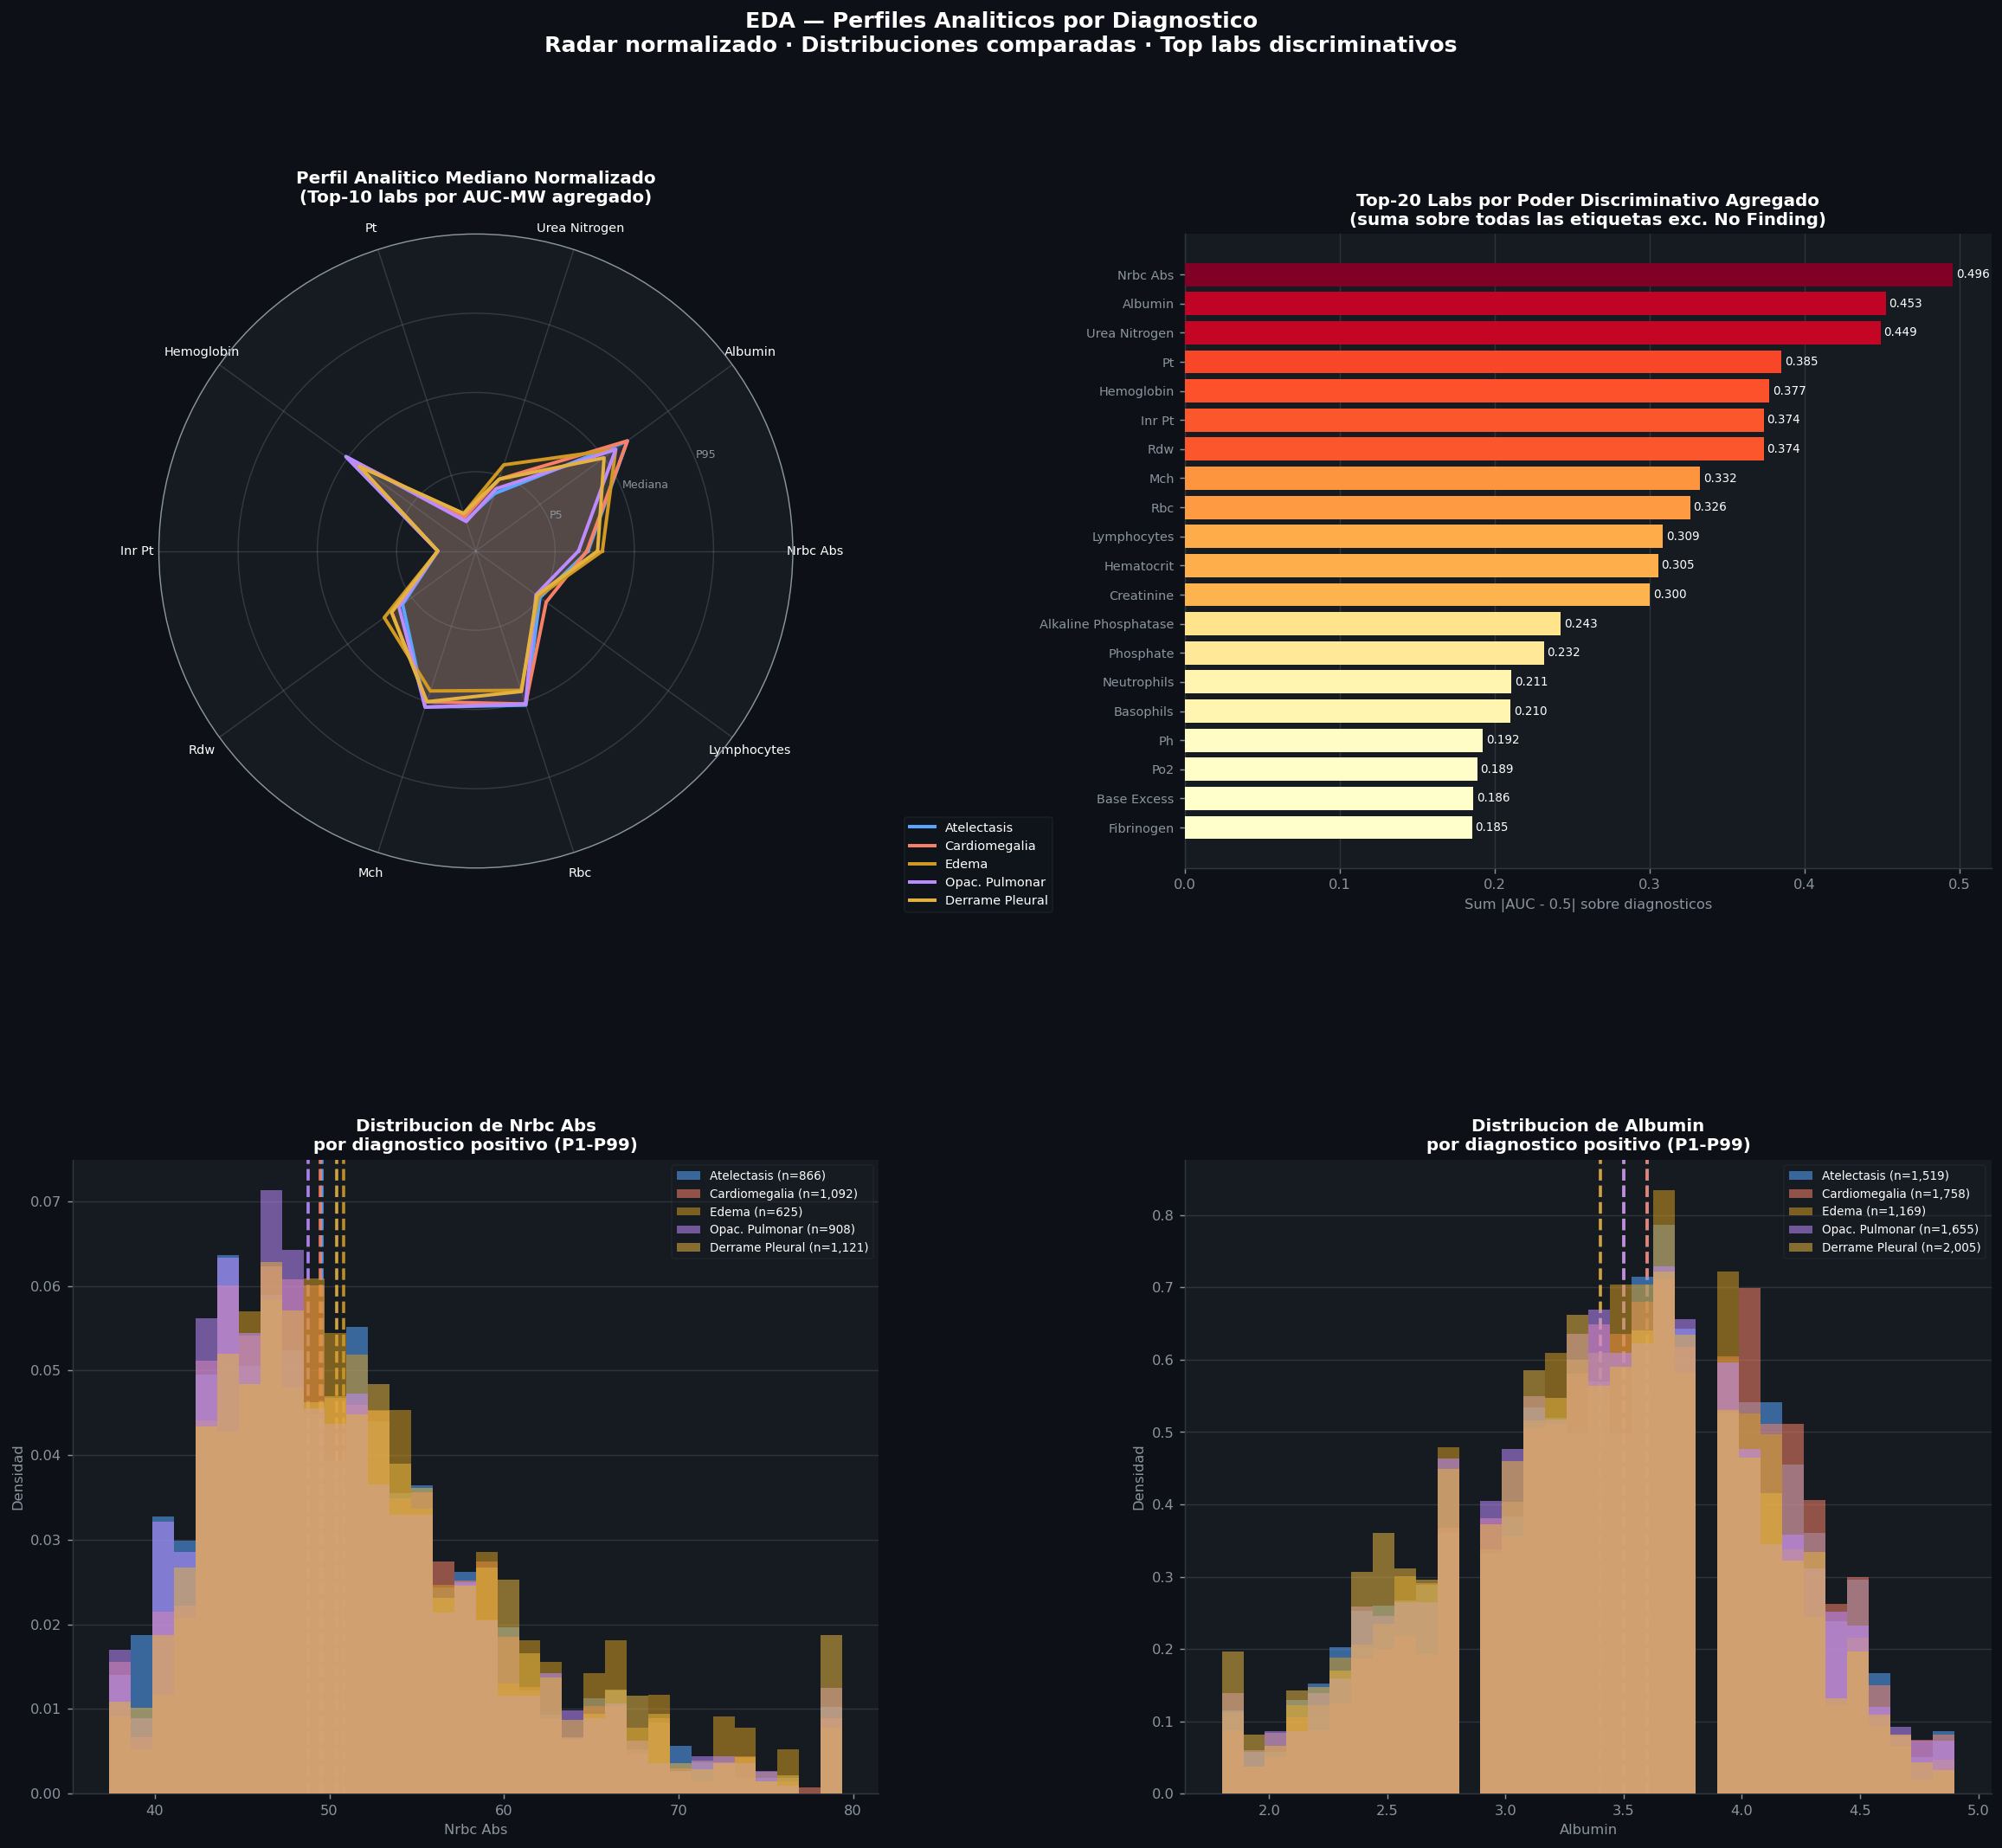

Bloque 13 guardado.


In [16]:
print("Bloque 13: Perfiles Radar + Distribuciones")

raw_arr = train[LAB_RAW_COLS].values.astype(float)
label_cols_nof = [lc for lc in LABEL_COLS if lc != 'No Finding']
label_disp_nof = [ld for lc, ld in zip(LABEL_COLS, LABEL_DISPLAY) if lc != 'No Finding']

# ── Seleccion de labs con mayor AUC-MW agregado ──
auc_agg = {}
for k, (lab_col, lab_disp) in enumerate(zip(LAB_RAW_COLS, LAB_RAW_DISP)):
    s = 0.0
    for lc in label_cols_nof:
        pos_v = raw_arr[(train[lc] == 1).values, k]; pos_v = pos_v[~np.isnan(pos_v)]
        neg_v = raw_arr[(train[lc] == 0).values, k]; neg_v = neg_v[~np.isnan(neg_v)]
        if len(pos_v) >= 5 and len(neg_v) >= 5:
            u, _ = stats.mannwhitneyu(pos_v, neg_v, alternative='two-sided')
            s += abs(u / (len(pos_v) * len(neg_v)) - 0.5)
    auc_agg[lab_col] = s

N_RADAR      = 10
top_r_cols   = sorted(auc_agg, key=auc_agg.get, reverse=True)[:N_RADAR]
top_r_disp   = [LAB_RAW_DISP[LAB_RAW_COLS.index(c)] for c in top_r_cols]
col_min = train[top_r_cols].quantile(0.05); col_max = train[top_r_cols].quantile(0.95)
col_rng = (col_max - col_min).replace(0, np.nan)

RADAR_LBLS   = ['Atelectasis', 'Cardiomegaly', 'Edema', 'Lung Opacity', 'Pleural Effusion']
RADAR_DISP   = [ld for lc, ld in zip(LABEL_COLS, LABEL_DISPLAY) if lc in RADAR_LBLS]
RADAR_COLORS = [C_CYAN, C_PINK, C_ORANGE, C_PURPLE, C_YELLOW]
angles = np.linspace(0, 2 * np.pi, N_RADAR, endpoint=False).tolist()
angles_closed = angles + angles[:1]

fig = plt.figure(figsize=(22, 18), facecolor=DARK_BG)
fig.suptitle('EDA — Perfiles Analiticos por Diagnostico\n'
             'Radar normalizado · Distribuciones comparadas · Top labs discriminativos',
             fontsize=14, fontweight='bold', color='white', y=0.99)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.46, wspace=0.38)

# ── Panel 1: Radar chart ──────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0], facecolor=PANEL_BG, projection='polar')
ax0.set_facecolor(PANEL_BG)
for lc, ld, col in zip(RADAR_LBLS, RADAR_DISP, RADAR_COLORS):
    sub = train[train[lc] == 1][top_r_cols]
    med_norm = ((sub.median() - col_min) / col_rng).clip(0, 1).fillna(0.5)
    vals = med_norm.tolist() + med_norm.tolist()[:1]
    ax0.plot(angles_closed, vals, color=col, lw=2.2, label=ld, zorder=4)
    ax0.fill(angles_closed, vals, color=col, alpha=0.09)
ax0.set_xticks(angles); ax0.set_xticklabels(top_r_disp, fontsize=8, color='white')
ax0.set_ylim(0, 1); ax0.set_yticks([0.25, 0.5, 0.75]); ax0.set_yticklabels(['P5', 'Mediana', 'P95'], fontsize=7, color=C_GREY)
ax0.set_title(f'Perfil Analitico Mediano Normalizado\n(Top-{N_RADAR} labs por AUC-MW agregado)', color='white', pad=20)
ax0.legend(fontsize=8, labelcolor='white', loc='lower right', bbox_to_anchor=(1.42, -0.08), framealpha=0.3)
ax0.spines['polar'].set_color(C_GREY); ax0.grid(color=C_GREY, alpha=0.25)

# ── Panel 2: Ranking AUC agregado ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1], facecolor=PANEL_BG)
N_RANK = 20
top_rank_cols = sorted(auc_agg, key=auc_agg.get, reverse=True)[:N_RANK]
top_rank_disp = [LAB_RAW_DISP[LAB_RAW_COLS.index(c)] for c in top_rank_cols]
top_rank_vals = [auc_agg[c] for c in top_rank_cols]
cmap_rank = plt.cm.YlOrRd; norm_rank = plt.Normalize(min(top_rank_vals), max(top_rank_vals))
bar_colors = [cmap_rank(norm_rank(v)) for v in top_rank_vals]
ax1.barh(range(N_RANK), top_rank_vals[::-1], color=bar_colors[::-1], edgecolor='none', zorder=3)
ax1.set_yticks(range(N_RANK)); ax1.set_yticklabels(top_rank_disp[::-1], fontsize=8, color=C_GREY)
for i, v in enumerate(top_rank_vals[::-1]): ax1.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=7.5, color='white')
ax1.set_xlabel('Sum |AUC - 0.5| sobre diagnosticos', color=C_GREY)
ax1.set_title(f'Top-{N_RANK} Labs por Poder Discriminativo Agregado\n(suma sobre todas las etiquetas exc. No Finding)', color='white')
ax1.tick_params(colors=C_GREY); ax1.xaxis.grid(True, alpha=0.2, color=C_GREY)

# ── Panel 3: Distribuciones del lab mas discriminativo ───────────────────
ax2 = fig.add_subplot(gs[1, 0], facecolor=PANEL_BG)
best_lab_col = top_rank_cols[0]; best_lab_disp = top_rank_disp[0]; best_idx = LAB_RAW_COLS.index(best_lab_col)
for lc, ld, col in zip(RADAR_LBLS, RADAR_DISP, RADAR_COLORS):
    grp = raw_arr[(train[lc] == 1).values, best_idx]; grp = grp[~np.isnan(grp)]
    if len(grp) < 5: continue
    lo, hi = np.nanpercentile(raw_arr[:, best_idx], [1, 99])
    bins_ = np.linspace(lo, hi, 35)
    ax2.hist(np.clip(grp, lo, hi), bins=bins_, color=col, alpha=0.55, density=True, edgecolor='none',
             label=f'{ld} (n={len(grp):,})', zorder=3)
    ax2.axvline(np.median(grp), color=col, lw=2, linestyle='--', alpha=0.9)
ax2.set_xlabel(best_lab_disp, color=C_GREY); ax2.set_ylabel('Densidad', color=C_GREY)
ax2.set_title(f'Distribucion de {best_lab_disp}\npor diagnostico positivo (P1-P99)', color='white')
ax2.legend(fontsize=7.5, labelcolor='white', framealpha=0.3); ax2.tick_params(colors=C_GREY); ax2.yaxis.grid(True, alpha=0.2, color=C_GREY)

# ── Panel 4: Distribuciones del 2.o lab mas discriminativo ───────────────
ax3 = fig.add_subplot(gs[1, 1], facecolor=PANEL_BG)
best2_lab_col = top_rank_cols[1]; best2_lab_disp = top_rank_disp[1]; best2_idx = LAB_RAW_COLS.index(best2_lab_col)
for lc, ld, col in zip(RADAR_LBLS, RADAR_DISP, RADAR_COLORS):
    grp = raw_arr[(train[lc] == 1).values, best2_idx]; grp = grp[~np.isnan(grp)]
    if len(grp) < 5: continue
    lo, hi = np.nanpercentile(raw_arr[:, best2_idx], [1, 99])
    bins_ = np.linspace(lo, hi, 35)
    ax3.hist(np.clip(grp, lo, hi), bins=bins_, color=col, alpha=0.55, density=True, edgecolor='none',
             label=f'{ld} (n={len(grp):,})', zorder=3)
    ax3.axvline(np.median(grp), color=col, lw=2, linestyle='--', alpha=0.9)
ax3.set_xlabel(best2_lab_disp, color=C_GREY); ax3.set_ylabel('Densidad', color=C_GREY)
ax3.set_title(f'Distribucion de {best2_lab_disp}\npor diagnostico positivo (P1-P99)', color='white')
ax3.legend(fontsize=7.5, labelcolor='white', framealpha=0.3); ax3.tick_params(colors=C_GREY); ax3.yaxis.grid(True, alpha=0.2, color=C_GREY)

plt.savefig(out('block13_perfiles_radar.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 13 guardado.")


---
## Bloque 14 — 🆕 Missingness Estructural (MNAR vs MCAR)
> ¿El hecho de que un lab sea NaN es aleatorio (MCAR) o depende del estado clínico del paciente (MNAR)?  
> Un Δ missingness positivo (más nulos en positivos) sugiere que los pacientes más enfermos tienen
> más analíticas pedidas o, paradójicamente, menos, según el flujo clínico.  
> La correlación entre patrones de nulos revela qué analíticas se piden o no piden de forma conjunta.


Bloque 14: Missingness estructural


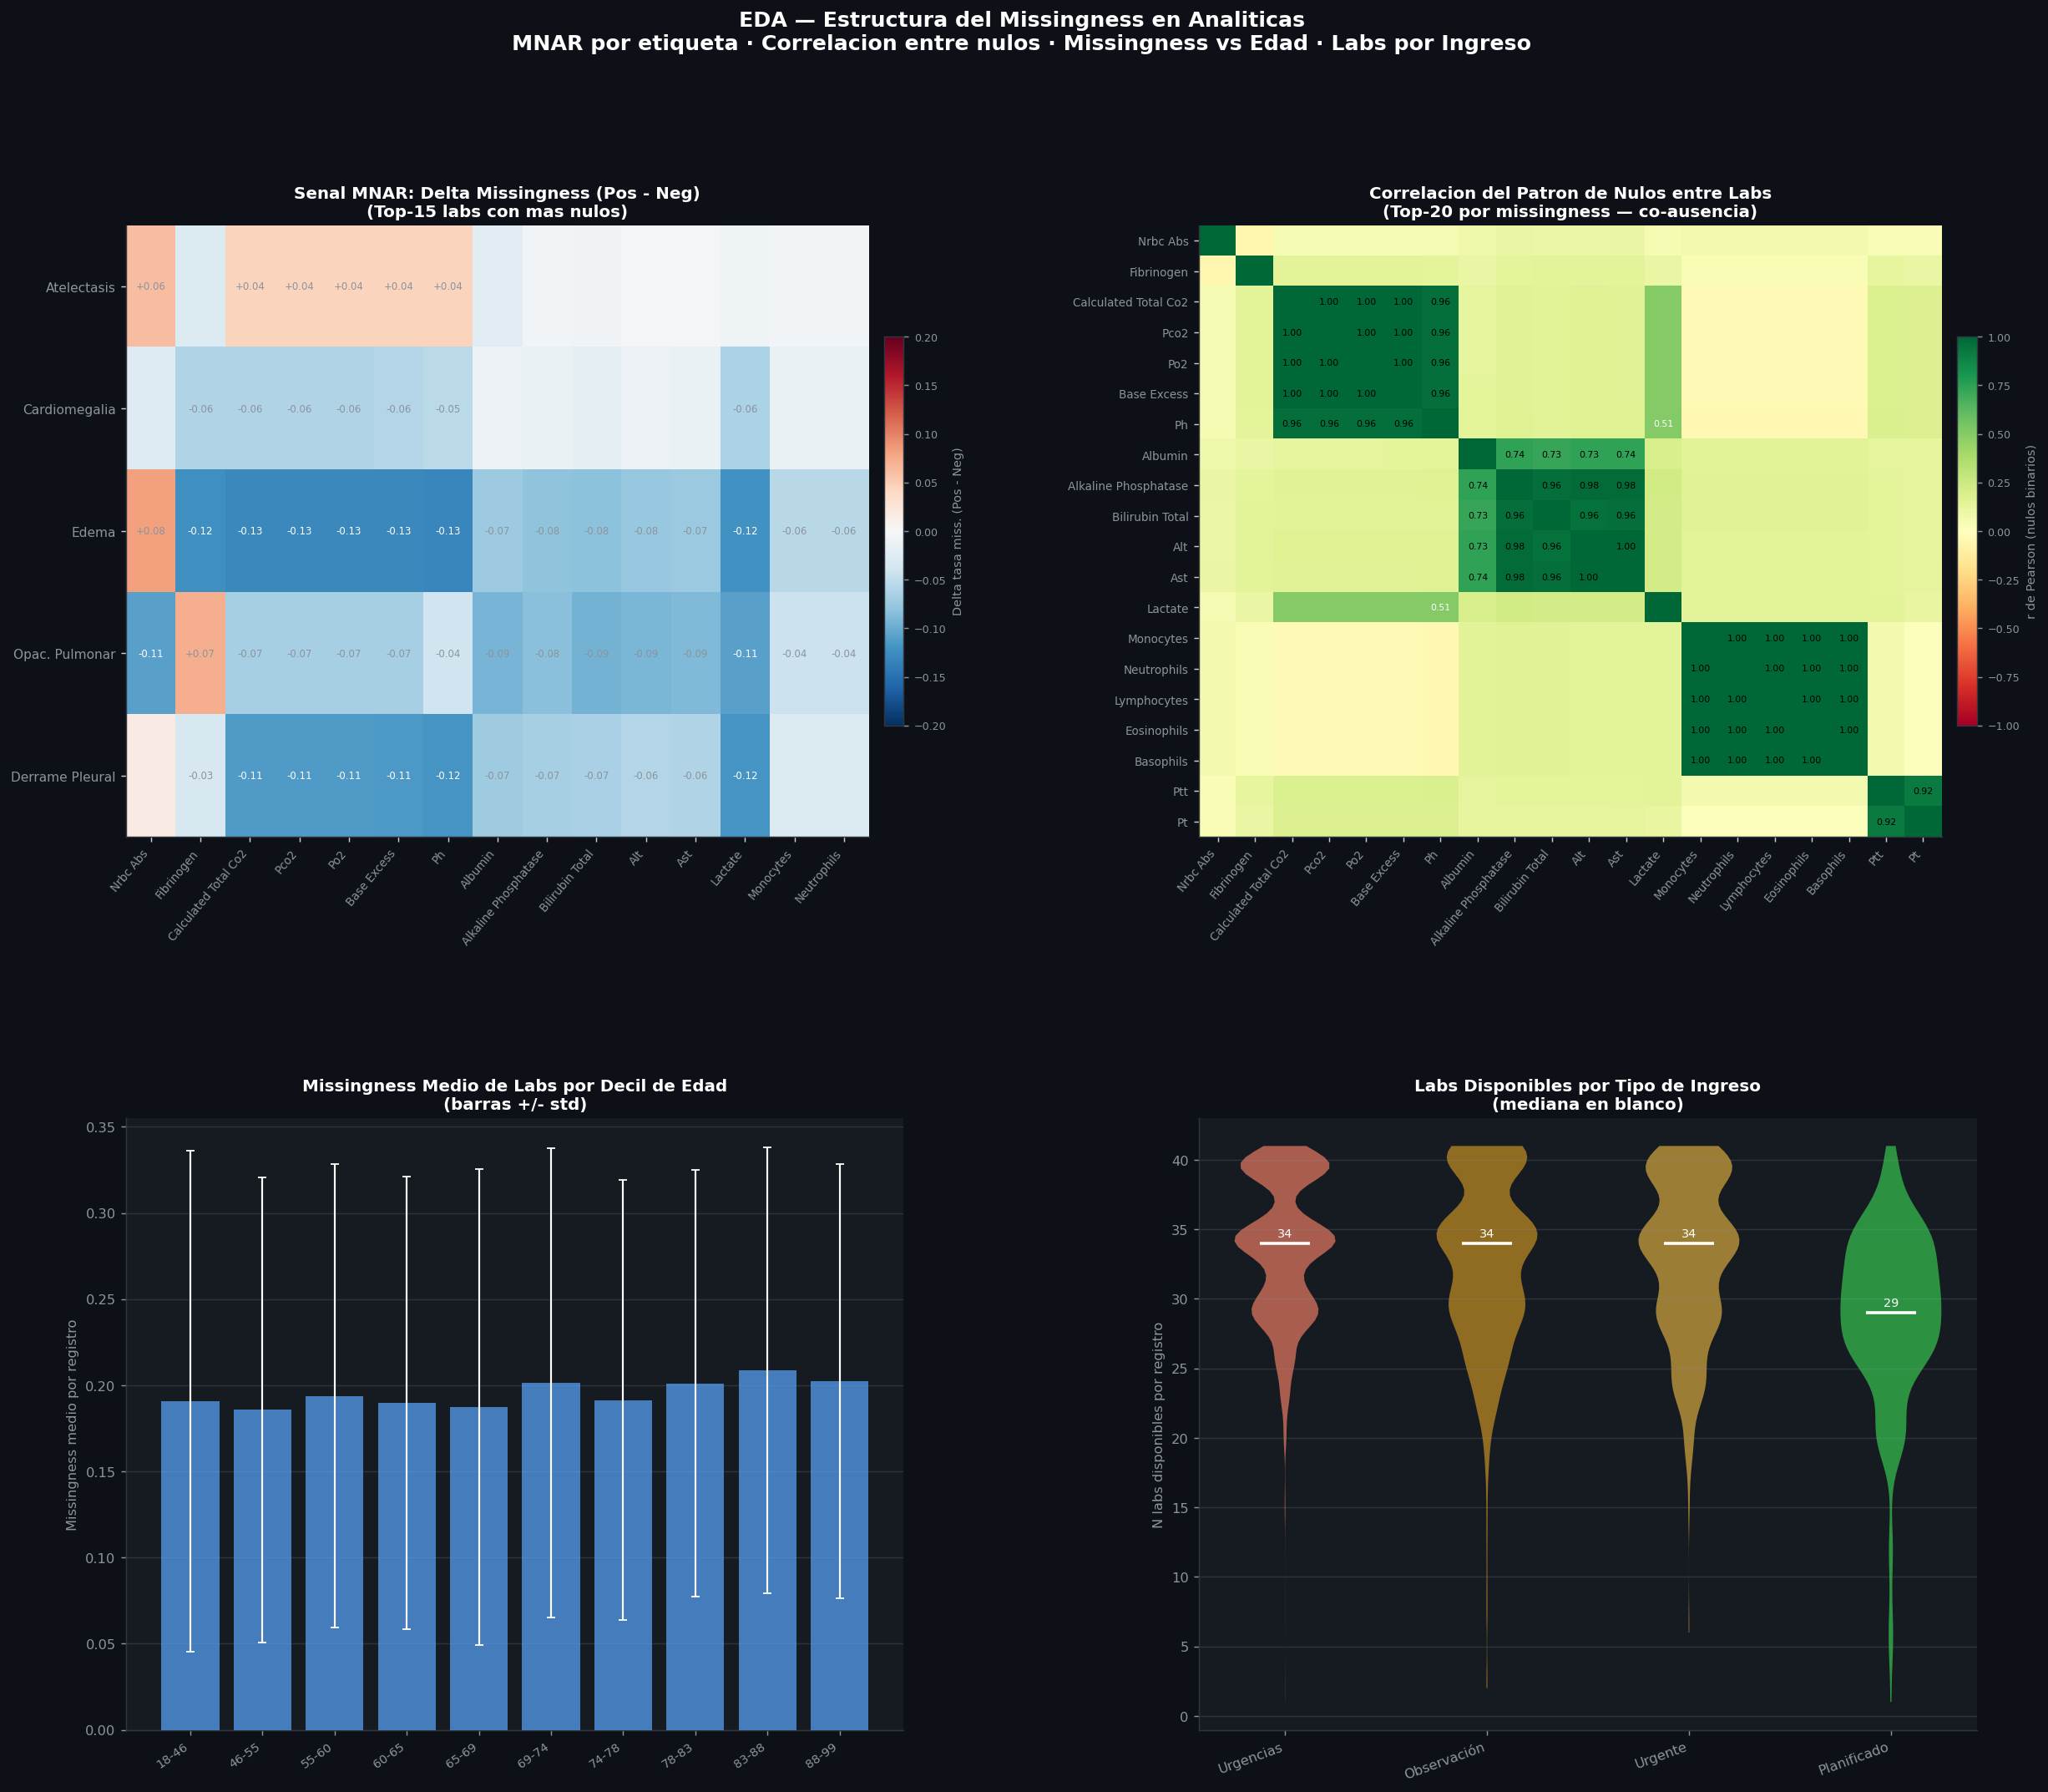

Bloque 14 guardado.


In [17]:
print("Bloque 14: Missingness estructural")

raw_arr  = train[LAB_RAW_COLS].values.astype(float)
miss_raw = train[LAB_RAW_COLS].isnull().mean().values

fig = plt.figure(figsize=(22, 18), facecolor=DARK_BG)
fig.suptitle('EDA — Estructura del Missingness en Analiticas\n'
             'MNAR por etiqueta · Correlacion entre nulos · Missingness vs Edad · Labs por Ingreso',
             fontsize=14, fontweight='bold', color='white', y=0.99)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.46, wspace=0.38)

label_cols_nof = [lc for lc in LABEL_COLS if lc != 'No Finding']
label_disp_nof = [ld for lc, ld in zip(LABEL_COLS, LABEL_DISPLAY) if lc != 'No Finding']

# ── Panel 1: Senal MNAR (Delta missingness Pos - Neg) ────────────────────
ax0 = fig.add_subplot(gs[0, 0], facecolor=PANEL_BG)
N_LABS_MN = 15
top_miss_idx  = np.argsort(miss_raw)[-N_LABS_MN:][::-1]
top_miss_disp = [LAB_RAW_DISP[i] for i in top_miss_idx]
mnar_mat = np.zeros((len(label_cols_nof), N_LABS_MN))
for i, lc in enumerate(label_cols_nof):
    pos_mask = (train[lc] == 1).values; neg_mask = (train[lc] == 0).values
    for j, lab_i in enumerate(top_miss_idx):
        miss_pos = np.isnan(raw_arr[pos_mask, lab_i]).mean()
        miss_neg = np.isnan(raw_arr[neg_mask, lab_i]).mean()
        mnar_mat[i, j] = miss_pos - miss_neg
im0 = ax0.imshow(mnar_mat, aspect='auto', cmap='RdBu_r', vmin=-0.2, vmax=0.2)
ax0.set_xticks(range(N_LABS_MN)); ax0.set_xticklabels(top_miss_disp, rotation=50, ha='right', fontsize=7.5, color=C_GREY)
ax0.set_yticks(range(len(label_cols_nof))); ax0.set_yticklabels(label_disp_nof, fontsize=8.5, color=C_GREY)
ax0.set_title(f'Senal MNAR: Delta Missingness (Pos - Neg)\n(Top-{N_LABS_MN} labs con mas nulos)', color='white')
for i in range(len(label_cols_nof)):
    for j in range(N_LABS_MN):
        v = mnar_mat[i, j]
        if abs(v) >= 0.03:
            ax0.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=6.5,
                     color='white' if abs(v) > 0.10 else C_GREY)
cbar0 = fig.colorbar(im0, ax=ax0, fraction=0.025, pad=0.02)
cbar0.ax.tick_params(colors=C_GREY, labelsize=7); cbar0.set_label('Delta tasa miss. (Pos - Neg)', color=C_GREY, fontsize=8)

# ── Panel 2: Correlacion de missingness entre labs ────────────────────────
ax1 = fig.add_subplot(gs[0, 1], facecolor=PANEL_BG)
N_MISS_HM = 20
top20_miss_idx  = np.argsort(miss_raw)[-N_MISS_HM:][::-1]
top20_miss_disp = [LAB_RAW_DISP[i] for i in top20_miss_idx]
miss_binary = np.isnan(raw_arr[:, top20_miss_idx]).astype(float)
corr_miss = np.corrcoef(miss_binary.T)
im1 = ax1.imshow(corr_miss, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1)
ax1.set_xticks(range(N_MISS_HM)); ax1.set_xticklabels(top20_miss_disp, rotation=50, ha='right', fontsize=7.5, color=C_GREY)
ax1.set_yticks(range(N_MISS_HM)); ax1.set_yticklabels(top20_miss_disp, fontsize=7.5, color=C_GREY)
ax1.set_title(f'Correlacion del Patron de Nulos entre Labs\n(Top-{N_MISS_HM} por missingness — co-ausencia)', color='white')
for i in range(N_MISS_HM):
    for j in range(N_MISS_HM):
        v = corr_miss[i, j]
        if i != j and abs(v) >= 0.5:
            ax1.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6, color='black' if v > 0.7 else 'white')
cbar1 = fig.colorbar(im1, ax=ax1, fraction=0.025, pad=0.02)
cbar1.ax.tick_params(colors=C_GREY, labelsize=7); cbar1.set_label('r de Pearson (nulos binarios)', color=C_GREY, fontsize=8)

# ── Panel 3: Missingness medio vs. decil de edad ──────────────────────────
ax2 = fig.add_subplot(gs[1, 0], facecolor=PANEL_BG)
age_vals    = train['age'].values
miss_per_r  = np.isnan(raw_arr).mean(axis=1)
age_bins    = np.percentile(age_vals[~np.isnan(age_vals)], np.arange(0, 101, 10))
age_bins    = np.unique(age_bins)
age_labels  = [f'{age_bins[i]:.0f}-{age_bins[i+1]:.0f}' for i in range(len(age_bins)-1)]
age_groups  = pd.cut(pd.Series(age_vals), bins=age_bins, labels=age_labels, include_lowest=True)
miss_by_age = pd.Series(miss_per_r).groupby(age_groups).agg(['mean', 'std'])
ax2.bar(range(len(miss_by_age)), miss_by_age['mean'].values, color=C_CYAN, edgecolor='none', alpha=0.7, zorder=3)
ax2.errorbar(range(len(miss_by_age)), miss_by_age['mean'].values, yerr=miss_by_age['std'].values,
             fmt='none', color='white', lw=1.2, capsize=3, zorder=4)
ax2.set_xticks(range(len(miss_by_age))); ax2.set_xticklabels(miss_by_age.index.tolist(), rotation=35, ha='right', fontsize=8, color=C_GREY)
ax2.set_ylabel('Missingness medio por registro', color=C_GREY)
ax2.set_title('Missingness Medio de Labs por Decil de Edad\n(barras +/- std)', color='white')
ax2.tick_params(colors=C_GREY); ax2.yaxis.grid(True, alpha=0.2, color=C_GREY)

# ── Panel 4: N labs disponibles por tipo de ingreso ───────────────────────
ax3 = fig.add_subplot(gs[1, 1], facecolor=PANEL_BG)
train_adm = train.copy()
train_adm['adm_display'] = train_adm['admission_type'].map(ADM_TYPE_MAP).fillna(train_adm['admission_type'])
train_adm['n_labs_obs']  = (~train_adm[LAB_RAW_COLS].isnull()).sum(axis=1)
adm_order  = train_adm['adm_display'].value_counts().index.tolist()
adm_colors = [C_PINK, C_ORANGE, C_YELLOW, C_TEAL, C_CYAN, C_PURPLE]
data_vl2, pos_vl2, col_vl2 = [], [], []
for k, adm in enumerate(adm_order):
    grp_obs = train_adm.loc[train_adm['adm_display'] == adm, 'n_labs_obs'].values
    if len(grp_obs) < 5: continue
    data_vl2.append(grp_obs); pos_vl2.append(k + 1); col_vl2.append(adm_colors[k % len(adm_colors)])
if data_vl2:
    parts = ax3.violinplot(data_vl2, positions=pos_vl2, showmedians=True, showextrema=False)
    for pc, c in zip(parts['bodies'], col_vl2): pc.set_facecolor(c); pc.set_alpha(0.65)
    parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)
    for k, (pos, grp) in enumerate(zip(pos_vl2, data_vl2)):
        ax3.text(pos, np.median(grp) + 0.3, f'{np.median(grp):.0f}', ha='center', va='bottom', fontsize=8, color='white')
ax3.set_xticks(pos_vl2); ax3.set_xticklabels(adm_order[:len(pos_vl2)], rotation=20, ha='right', fontsize=9, color=C_GREY)
ax3.set_ylabel('N labs disponibles por registro', color=C_GREY)
ax3.set_title('Labs Disponibles por Tipo de Ingreso\n(mediana en blanco)', color='white')
ax3.tick_params(colors=C_GREY); ax3.yaxis.grid(True, alpha=0.2, color=C_GREY)

plt.savefig(out('block14_missingness_structural.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 14 guardado.")


---
## Bloque 15 — 🆕 IVF: Importancia de Variables por Feature

Tres métodos complementarios:
- **Random Forest Gini importance** (no-lineal, captura interacciones)
- **Mutual Information** (captura dependencias no lineales arbitrarias)
- **ANOVA F-score** (lineal, rápido, referencia univariante)

Se calcula para las **6 etiquetas** usando solo los labs **raw** como features (+ age, gender como referencia demográfica). Se usa imputación media para NaN.

In [18]:
DEMO_FEAT = ['age', 'gender']
IVF_FEATURE_COLS  = DEMO_FEAT + LAB_RAW_COLS
IVF_FEATURE_NAMES = ['Edad', 'Genero'] + LAB_RAW_DISP

X_raw = train[IVF_FEATURE_COLS].values.astype(float)
imp = SimpleImputer(strategy='mean')
X_imp = imp.fit_transform(X_raw)

print(f"Shape para IVF: {X_imp.shape}")
print("Calculando importancias... (~1-2 min)")


Shape para IVF: (10000, 43)
Calculando importancias... (~1-2 min)


In [19]:
ivf_results = {}

for lc, ld in zip(LABEL_COLS, LABEL_DISPLAY):
    mask_obs = train[lc].isin([0, 1])
    y_obs    = (train.loc[mask_obs, lc] == 1).astype(int).values
    X_obs    = X_imp[mask_obs.values]
    if y_obs.sum() < 20 or (1-y_obs).sum() < 20: print(f"  {ld}: insuficientes muestras."); continue
    rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=5,
                                class_weight='balanced', random_state=42, n_jobs=-1)
    rf.fit(X_obs, y_obs)
    mi      = mutual_info_classif(X_obs, y_obs, discrete_features=False, random_state=42)
    f_scores, p_f = f_classif(X_obs, y_obs)
    f_scores = np.nan_to_num(f_scores, nan=0.0)
    ivf_results[lc] = {'label_display': ld, 'rf_imp': rf.feature_importances_, 'mi': mi,
                       'f_score': f_scores, 'p_f': p_f, 'n_pos': int(y_obs.sum()), 'n_neg': int((1-y_obs).sum())}
    print(f"  ok {ld}  (n_pos={y_obs.sum():,}, n_neg={(1-y_obs).sum():,})")

print("Calculo completado.")


  ok Atelectasis  (n_pos=2,867, n_neg=118)
  ok Cardiomegalia  (n_pos=3,346, n_neg=886)
  ok Edema  (n_pos=2,067, n_neg=1,772)
  ok Opac. Pulmonar  (n_pos=3,108, n_neg=175)
  Sin Hallazgo: insuficientes muestras.
  ok Derrame Pleural  (n_pos=3,618, n_neg=1,701)
Calculo completado.


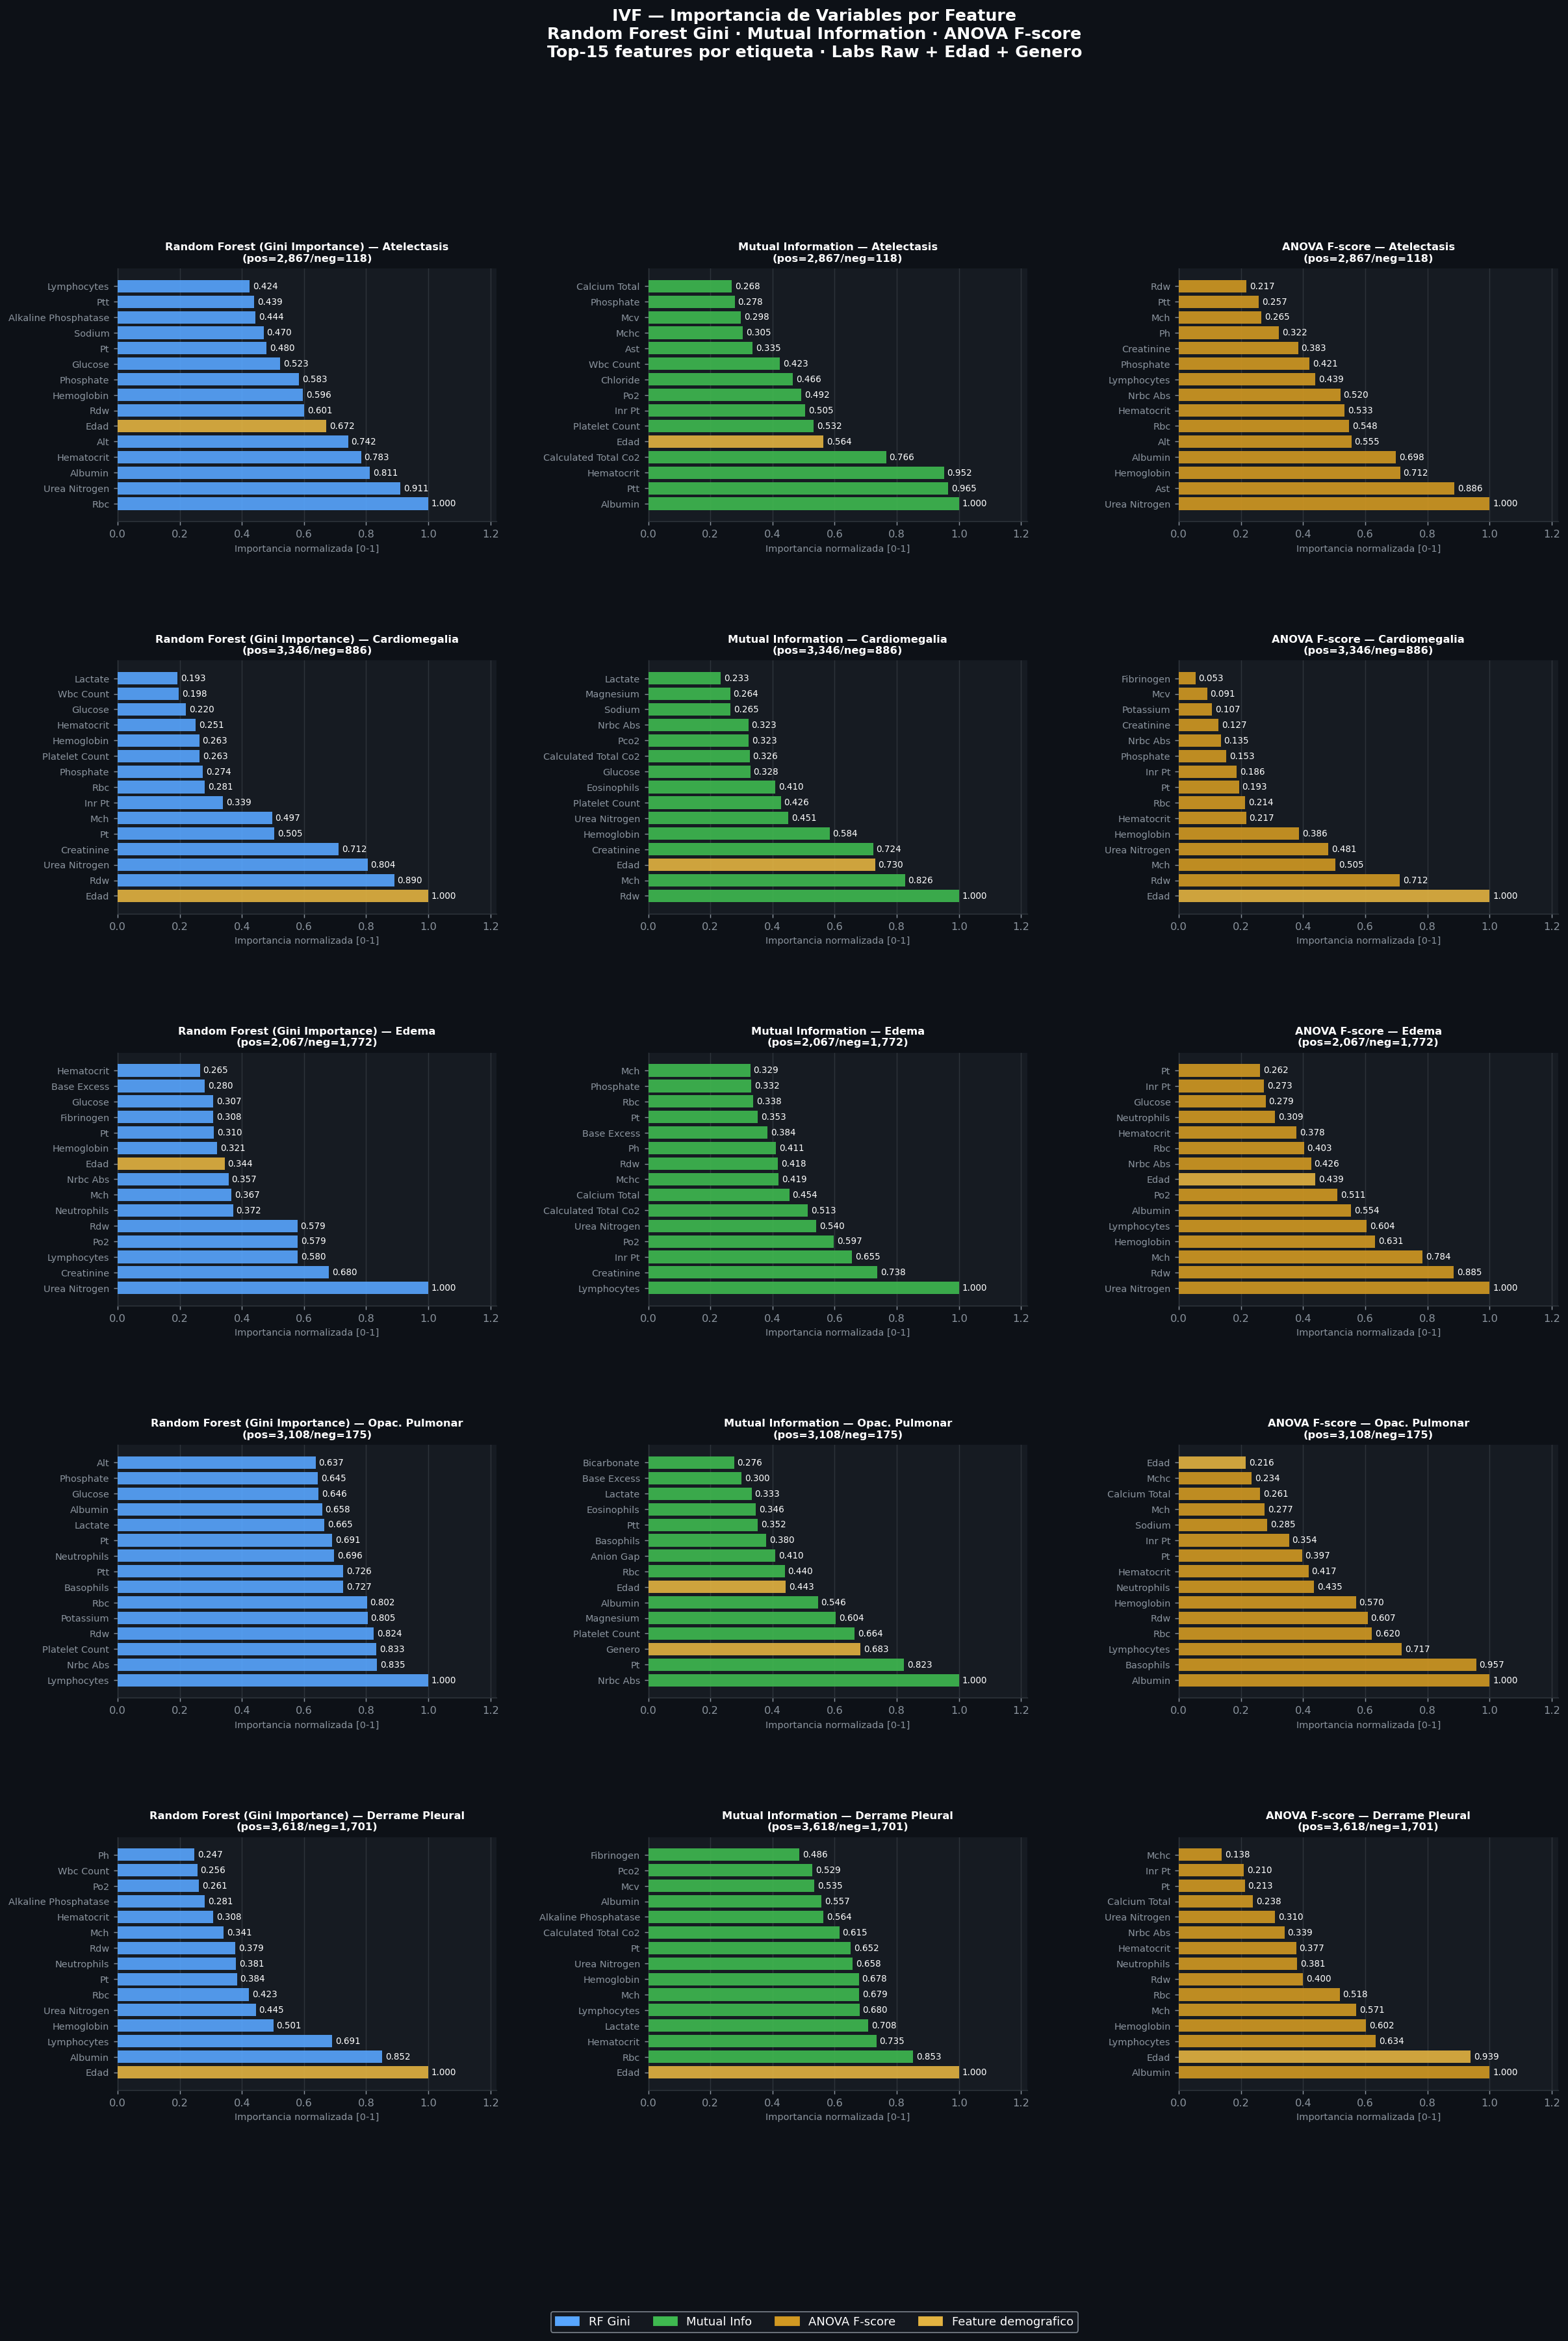

Bloque 15a guardado.


In [20]:
fig_ivf = plt.figure(figsize=(22, 28), facecolor=DARK_BG)
fig_ivf.suptitle('IVF — Importancia de Variables por Feature\n'
                 'Random Forest Gini · Mutual Information · ANOVA F-score\n'
                 'Top-15 features por etiqueta · Labs Raw + Edad + Genero',
                 fontsize=14, fontweight='bold', color='white', y=0.99)

n_labels = len(ivf_results)
gs_ivf   = gridspec.GridSpec(n_labels, 3, figure=fig_ivf, hspace=0.55, wspace=0.40)
method_labels = ['Random Forest\n(Gini Importance)', 'Mutual\nInformation', 'ANOVA F-score']
method_keys   = ['rf_imp', 'mi', 'f_score']
method_colors = [C_CYAN, C_GREEN, C_ORANGE]
TOP_N = 15

for row_i, (lc, res) in enumerate(ivf_results.items()):
    ld = res['label_display']
    for col_i, (mkey, mcol, mlabel) in enumerate(zip(method_keys, method_colors, method_labels)):
        ax_ivf = fig_ivf.add_subplot(gs_ivf[row_i, col_i], facecolor=PANEL_BG)
        scores = res[mkey]; s_max = scores.max()
        scores_norm = scores / s_max if s_max > 0 else scores
        sorted_idx  = np.argsort(scores_norm)[::-1][:TOP_N]
        names_top   = [IVF_FEATURE_NAMES[i] for i in sorted_idx]
        vals_top    = scores_norm[sorted_idx]
        bar_colors  = [C_YELLOW if IVF_FEATURE_NAMES[i] in ['Edad','Genero'] else mcol for i in sorted_idx]
        ax_ivf.barh(range(len(names_top)), vals_top, color=bar_colors, edgecolor='none', alpha=0.9, zorder=3)
        for i, (bar_, v_) in enumerate(zip([None]*len(vals_top), vals_top)):
            ax_ivf.text(v_+0.01, i, f'{v_:.3f}', va='center', fontsize=7.5, color='white')
        ax_ivf.set_yticks(range(len(names_top))); ax_ivf.set_yticklabels(names_top, fontsize=8, color=C_GREY)
        ax_ivf.set_xlabel('Importancia normalizada [0-1]', color=C_GREY, fontsize=8)
        ax_ivf.set_xlim(0, 1.22); ax_ivf.xaxis.grid(True, alpha=0.2, color=C_GREY); ax_ivf.tick_params(colors=C_GREY)
        ax_ivf.set_title(f'{mlabel.replace(chr(10)," ")} — {ld}\n(pos={res["n_pos"]:,}/neg={res["n_neg"]:,})', color='white', fontsize=9)

leg_ivf = [mpatches.Patch(color=C_CYAN, label='RF Gini'), mpatches.Patch(color=C_GREEN, label='Mutual Info'),
           mpatches.Patch(color=C_ORANGE, label='ANOVA F-score'), mpatches.Patch(color=C_YELLOW, label='Feature demografico')]
fig_ivf.legend(handles=leg_ivf, loc='lower center', ncol=4, fontsize=10, labelcolor='white',
               bbox_to_anchor=(0.5, 0.005), frameon=True, facecolor=PANEL_BG, edgecolor=C_GREY)

plt.savefig(out('block15a_ivf_per_label.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 15a guardado.")


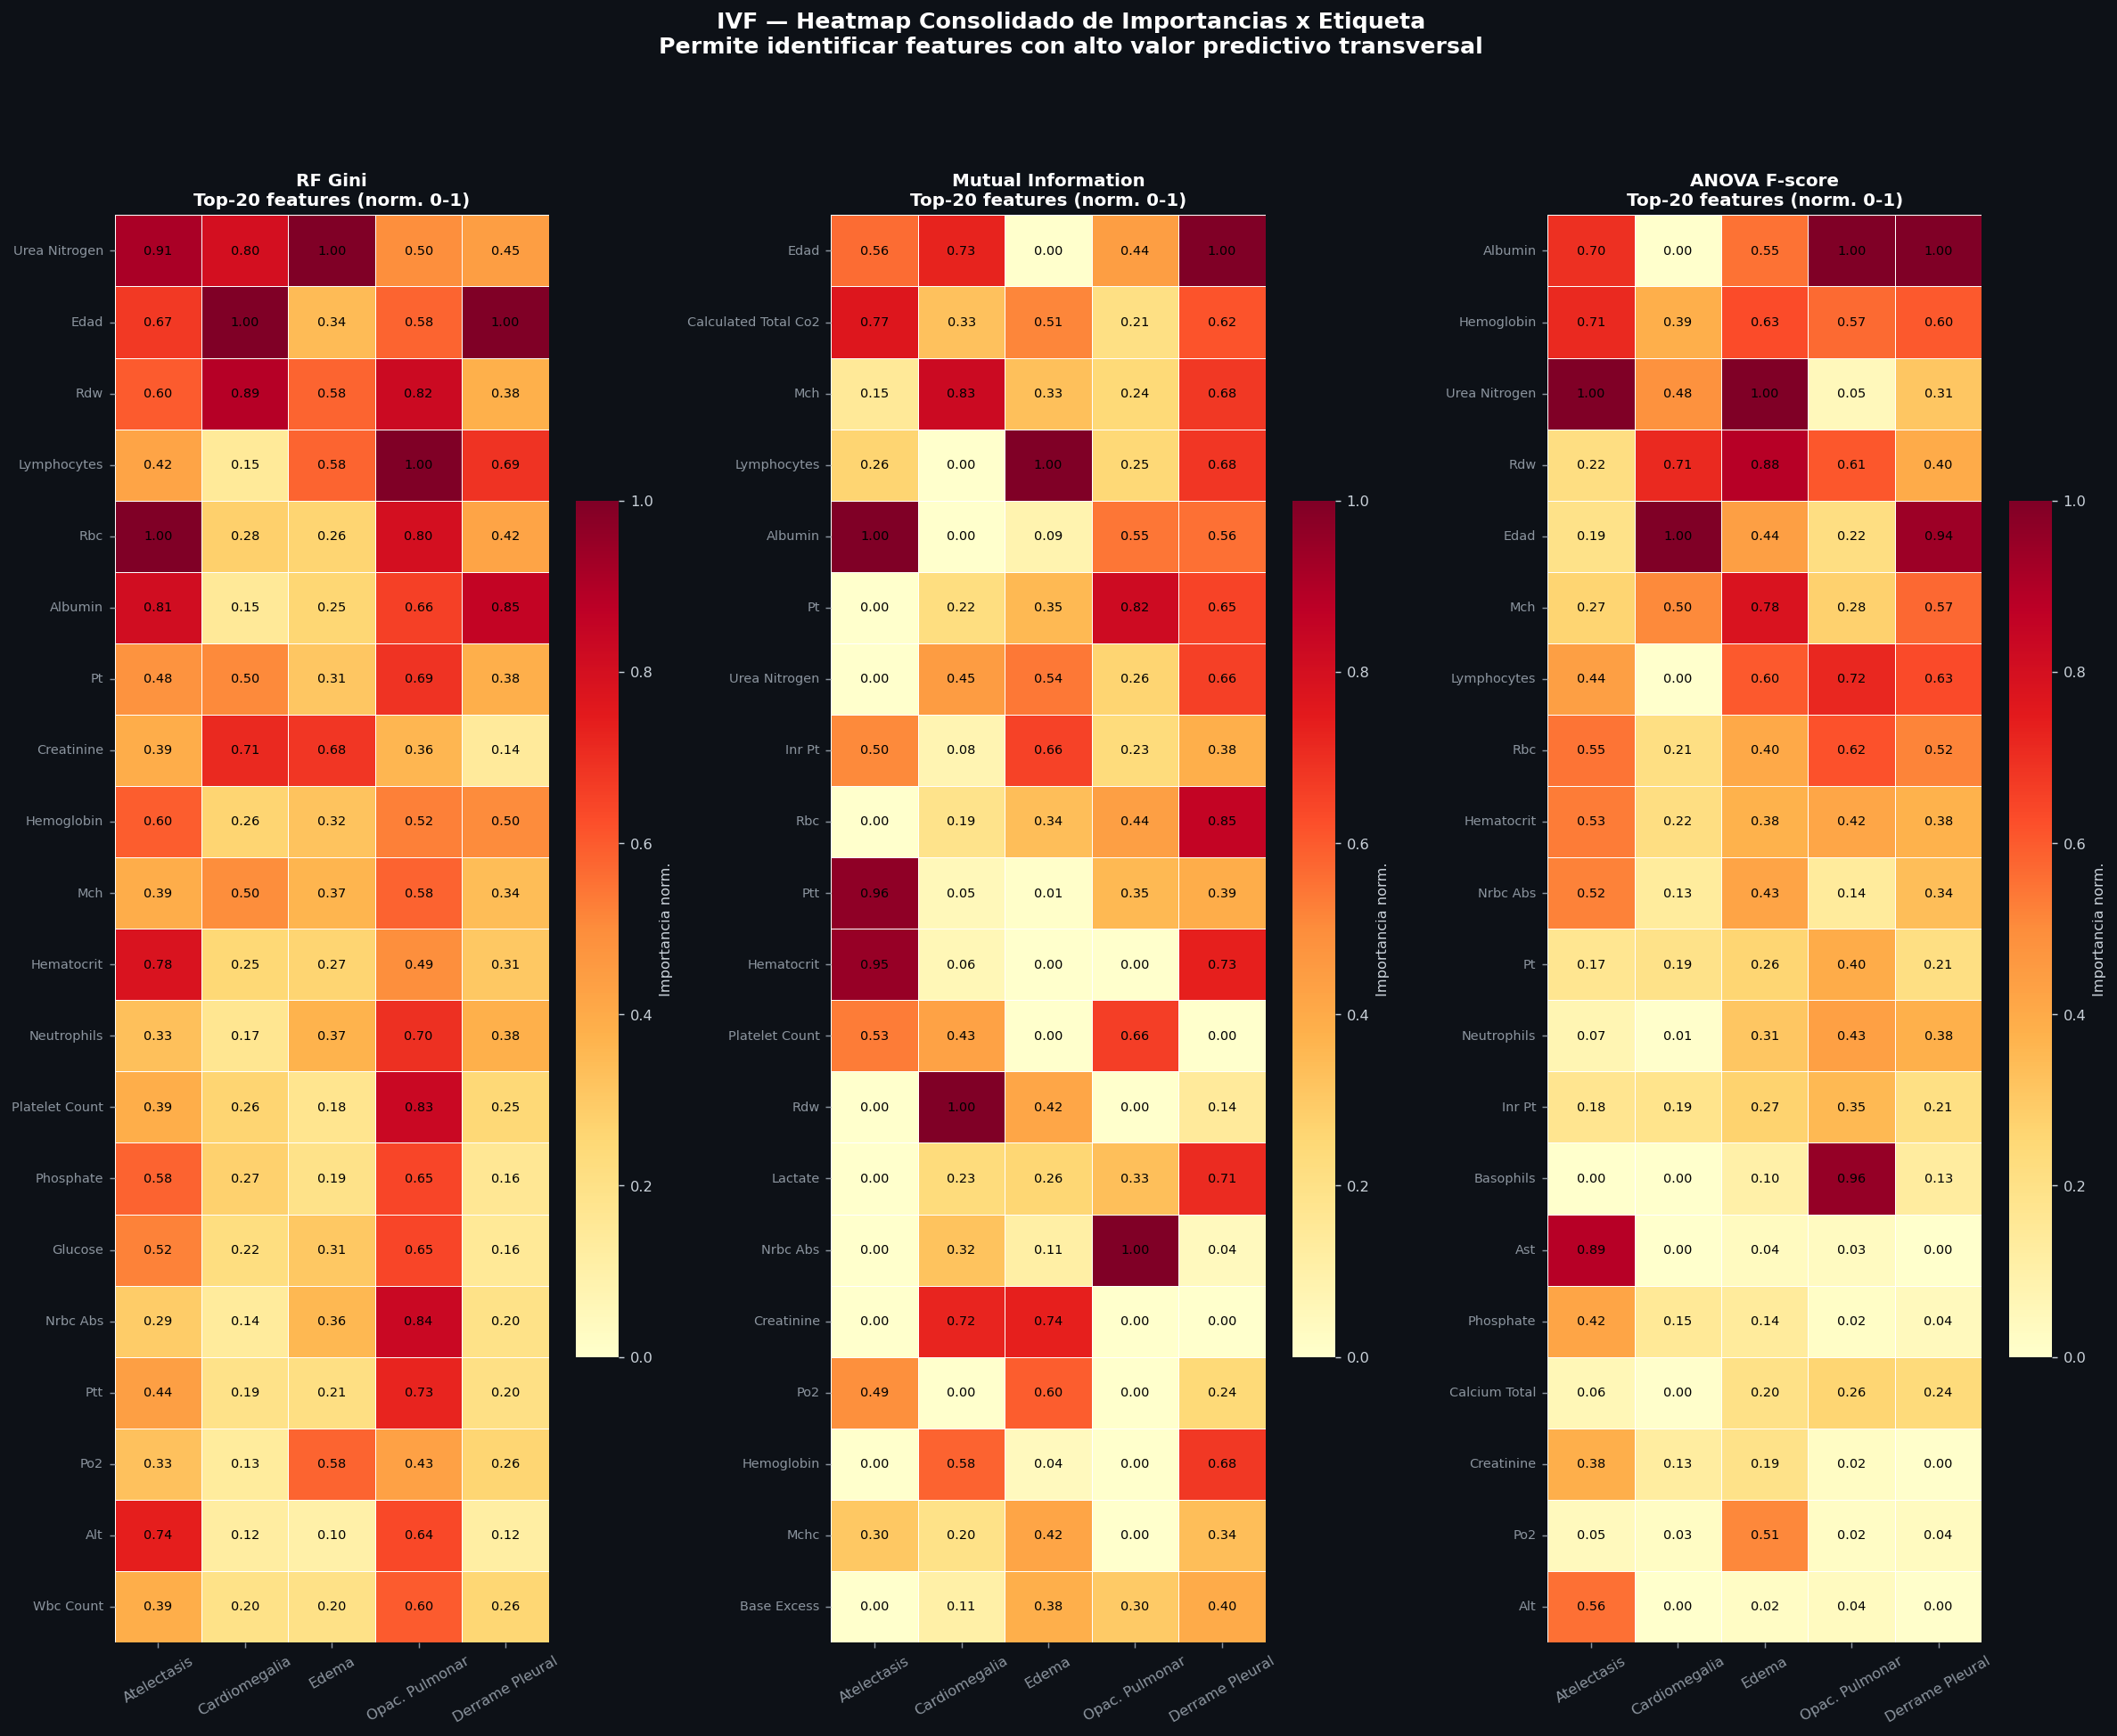

Bloque 15b guardado.


In [21]:
# ── Heatmap consolidado IVF ──
fig_h = plt.figure(figsize=(22, 16), facecolor=DARK_BG)
fig_h.suptitle('IVF — Heatmap Consolidado de Importancias x Etiqueta\n'
               'Permite identificar features con alto valor predictivo transversal',
               fontsize=14, fontweight='bold', color='white', y=0.99)
gs_h = gridspec.GridSpec(1, 3, figure=fig_h, hspace=0.3, wspace=0.32)

for ci, (mkey, mlabel) in enumerate(zip(['rf_imp', 'mi', 'f_score'], ['RF Gini', 'Mutual Information', 'ANOVA F-score'])):
    ax_h = fig_h.add_subplot(gs_h[0, ci], facecolor=PANEL_BG)
    label_names_plot = [res['label_display'] for res in ivf_results.values()]
    hm_data = pd.DataFrame(index=IVF_FEATURE_NAMES, columns=label_names_plot)
    for lc, res in ivf_results.items():
        scores = res[mkey]; s_max = scores.max()
        hm_data[res['label_display']] = scores / s_max if s_max > 0 else scores
    hm_data = hm_data.astype(float)
    hm_data['__mean__'] = hm_data.mean(axis=1)
    hm_data = hm_data.sort_values('__mean__', ascending=False).drop('__mean__', axis=1)
    sns.heatmap(hm_data.head(20), annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1, ax=ax_h, linewidths=0.3,
                cbar_kws={'shrink':0.6, 'label':'Importancia norm.'}, annot_kws={'size':8, 'color':'black'})
    ax_h.set_title(f'{mlabel}\nTop-20 features (norm. 0-1)', color='white', fontsize=11)
    ax_h.tick_params(axis='x', rotation=30, labelsize=9, colors=C_GREY)
    ax_h.tick_params(axis='y', rotation=0, labelsize=8, colors=C_GREY)

plt.savefig(out('block15b_ivf_heatmap.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 15b guardado.")


RANKING GLOBAL IVF — Top 25 features
Rank  Feature                               RF Gini  Mut.Info   ANOVA F     Media
----------------------------------------------------------------------
   1  Edad                                    0.719     0.547     0.557     0.608
   2  Urea Nitrogen                           0.731     0.382     0.568     0.560
   3  Albumin                                 0.545     0.438     0.651     0.545
   4  Rdw                                     0.655     0.312     0.564     0.510
   5  Lymphocytes                             0.568     0.439     0.479     0.495
   6  Rbc                                     0.554     0.364     0.461     0.460
   7  Mch                                     0.437     0.445     0.480     0.454
   8  Hemoglobin                              0.441     0.261     0.580     0.427
   9  Hematocrit                              0.420     0.349     0.384     0.385
  10  Pt                                      0.474     0.409     0.247 

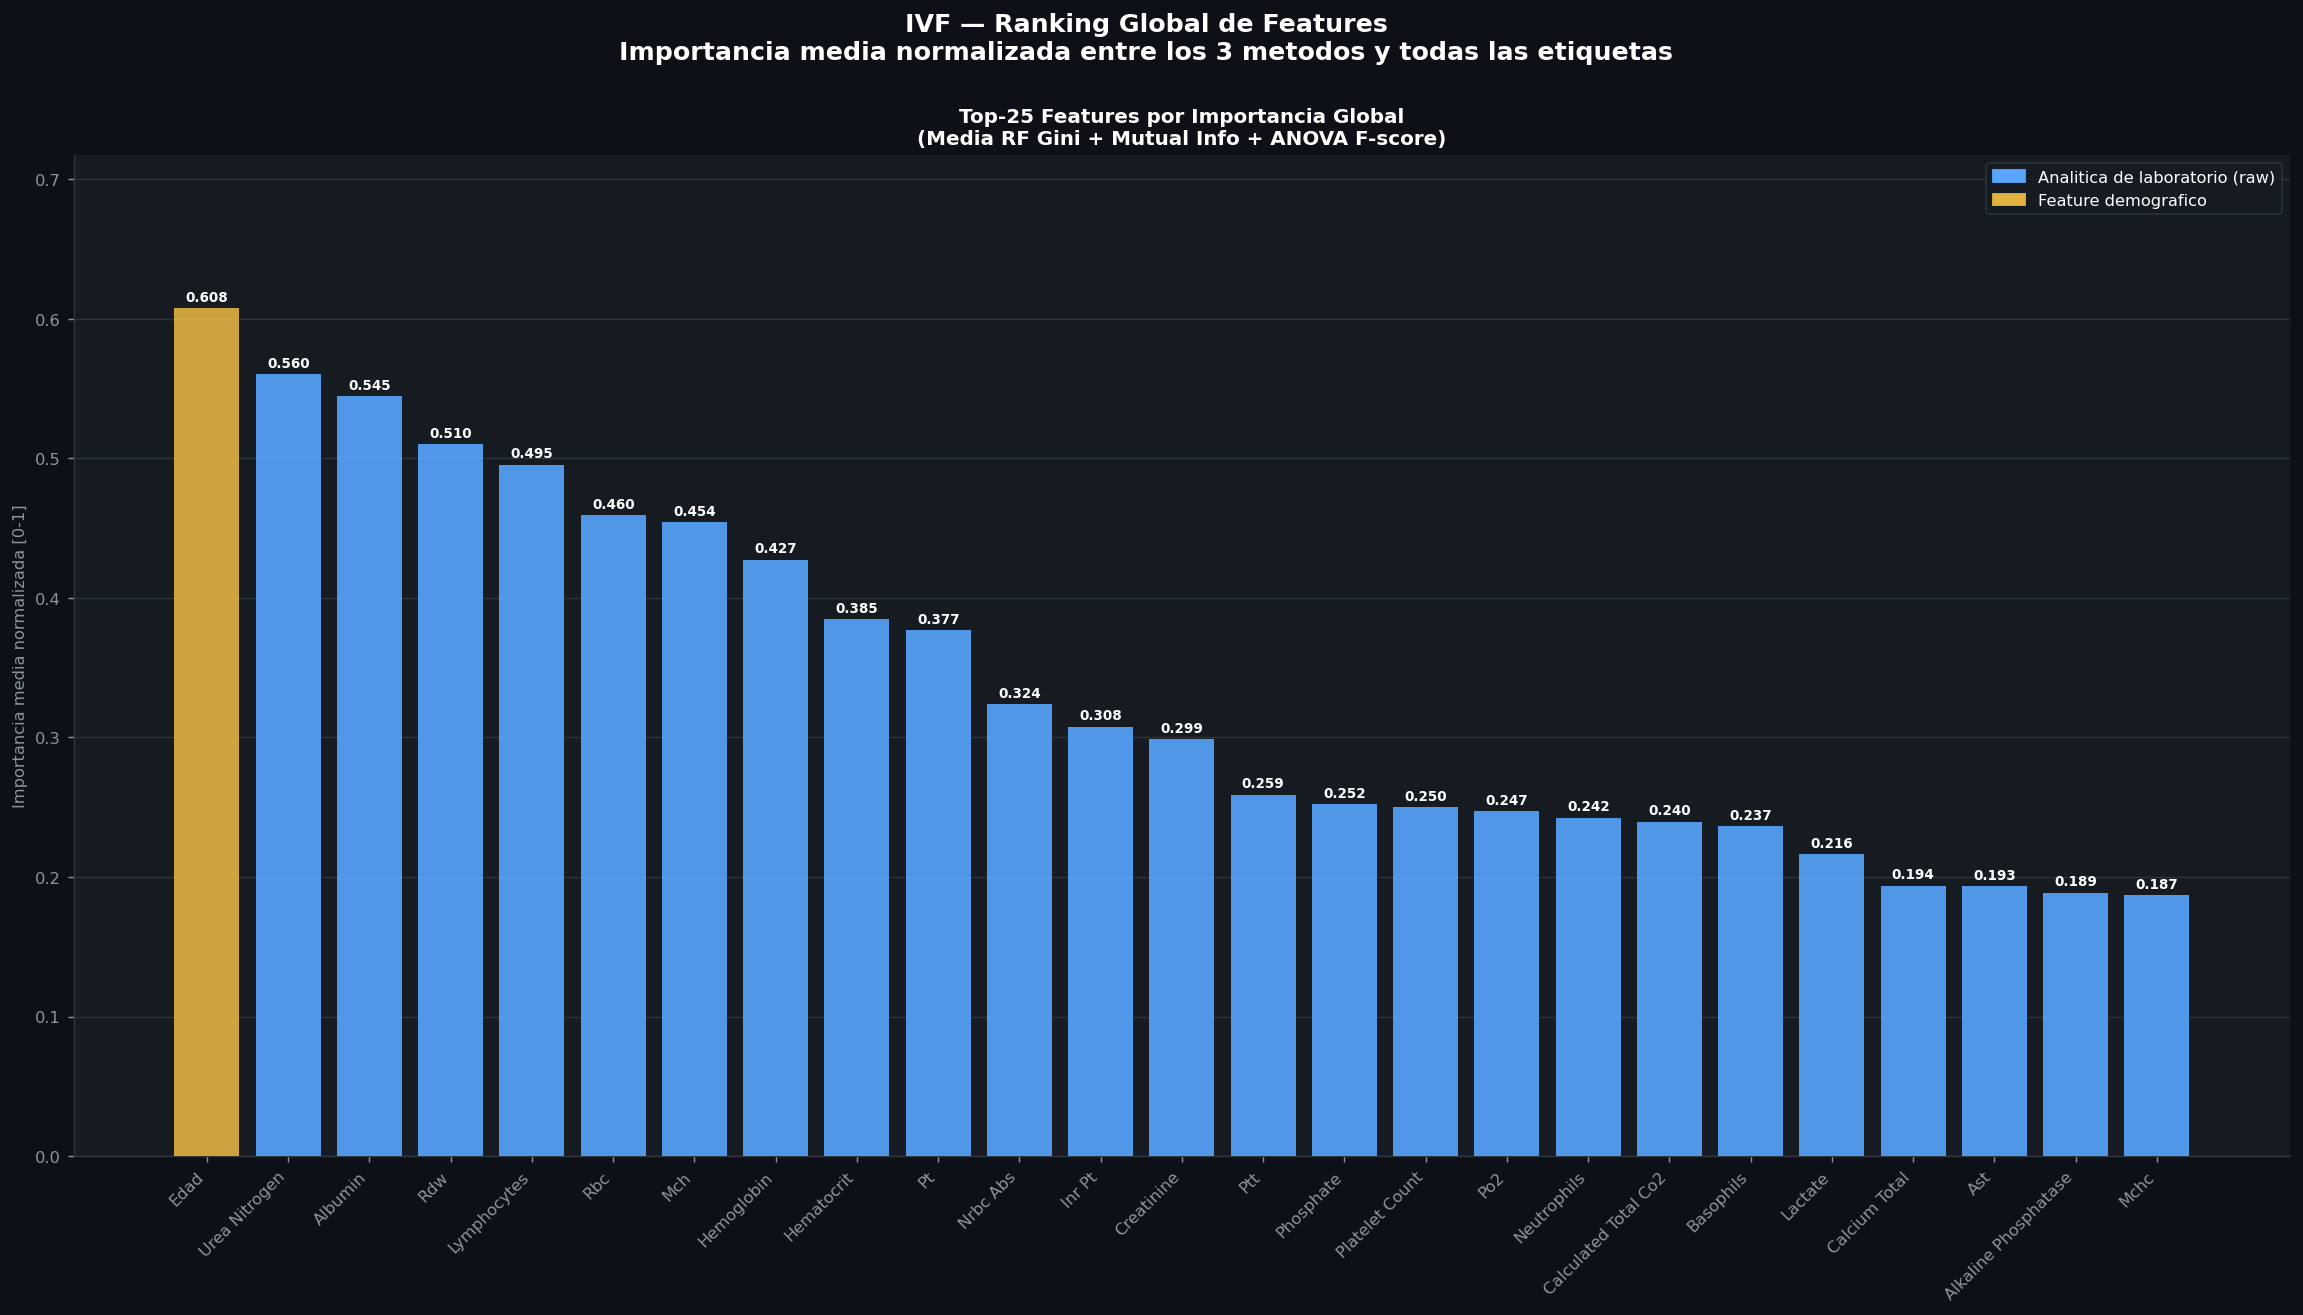

Bloque 15c guardado.


In [22]:
# ── Ranking global IVF ──
fig_rank = plt.figure(figsize=(22, 10), facecolor=DARK_BG)
fig_rank.suptitle('IVF — Ranking Global de Features\n'
                  'Importancia media normalizada entre los 3 metodos y todas las etiquetas',
                  fontsize=14, fontweight='bold', color='white', y=0.99)
gs_rank = gridspec.GridSpec(1, 1, figure=fig_rank)
ax_rank = fig_rank.add_subplot(gs_rank[0, 0], facecolor=PANEL_BG)

global_scores = np.zeros(len(IVF_FEATURE_COLS)); n_contributions = np.zeros(len(IVF_FEATURE_COLS))
for lc, res in ivf_results.items():
    for mkey in ['rf_imp', 'mi', 'f_score']:
        s = res[mkey]; s_max = s.max()
        global_scores += s / s_max if s_max > 0 else s; n_contributions += 1
global_scores_mean = global_scores / np.maximum(n_contributions, 1)
global_sorted_idx  = np.argsort(global_scores_mean)[::-1]
top_n_global = 25; x_rank = global_sorted_idx[:top_n_global]
names_rank = [IVF_FEATURE_NAMES[i] for i in x_rank]; vals_rank = global_scores_mean[x_rank]
bar_cols_rank = [C_YELLOW if n in ['Edad','Genero'] else C_CYAN for n in names_rank]
bars_rank = ax_rank.bar(range(top_n_global), vals_rank, color=bar_cols_rank, edgecolor='none', alpha=0.9, zorder=3)
for i, (bar_, v_) in enumerate(zip(bars_rank, vals_rank)):
    ax_rank.text(bar_.get_x()+bar_.get_width()/2, v_+0.003, f'{v_:.3f}',
                 ha='center', va='bottom', fontsize=7.5, color='white', fontweight='bold')
ax_rank.set_xticks(range(top_n_global)); ax_rank.set_xticklabels(names_rank, rotation=45, ha='right', fontsize=9, color=C_GREY)
ax_rank.set_ylabel('Importancia media normalizada [0-1]', color=C_GREY); ax_rank.set_ylim(0, max(vals_rank)*1.18)
ax_rank.set_title(f'Top-{top_n_global} Features por Importancia Global\n(Media RF Gini + Mutual Info + ANOVA F-score)', color='white', fontsize=11)
ax_rank.yaxis.grid(True, alpha=0.2, color=C_GREY); ax_rank.tick_params(colors=C_GREY)
leg_rank = [mpatches.Patch(color=C_CYAN, label='Analitica de laboratorio (raw)'), mpatches.Patch(color=C_YELLOW, label='Feature demografico')]
ax_rank.legend(handles=leg_rank, fontsize=9, labelcolor='white', loc='upper right')

print("="*70); print(f"RANKING GLOBAL IVF — Top {top_n_global} features"); print("="*70)
print(f"{'Rank':>4}  {'Feature':<35}  {'RF Gini':>8}  {'Mut.Info':>8}  {'ANOVA F':>8}  {'Media':>8}")
print("-"*70)
for rank, fi in enumerate(global_sorted_idx[:top_n_global], 1):
    rf_s = np.mean([res['rf_imp'][fi]/res['rf_imp'].max() for res in ivf_results.values() if res['rf_imp'].max()>0])
    mi_s = np.mean([res['mi'][fi]/res['mi'].max() for res in ivf_results.values() if res['mi'].max()>0])
    fs_s = np.mean([res['f_score'][fi]/res['f_score'].max() for res in ivf_results.values() if res['f_score'].max()>0])
    print(f"  {rank:>2}  {IVF_FEATURE_NAMES[fi]:<35}  {rf_s:>8.3f}  {mi_s:>8.3f}  {fs_s:>8.3f}  {global_scores_mean[fi]:>8.3f}")

plt.savefig(out('block15c_ivf_ranking.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 15c guardado.")


---
## Bloque 16 — Asociaciones Género × Etnia × Etiquetas

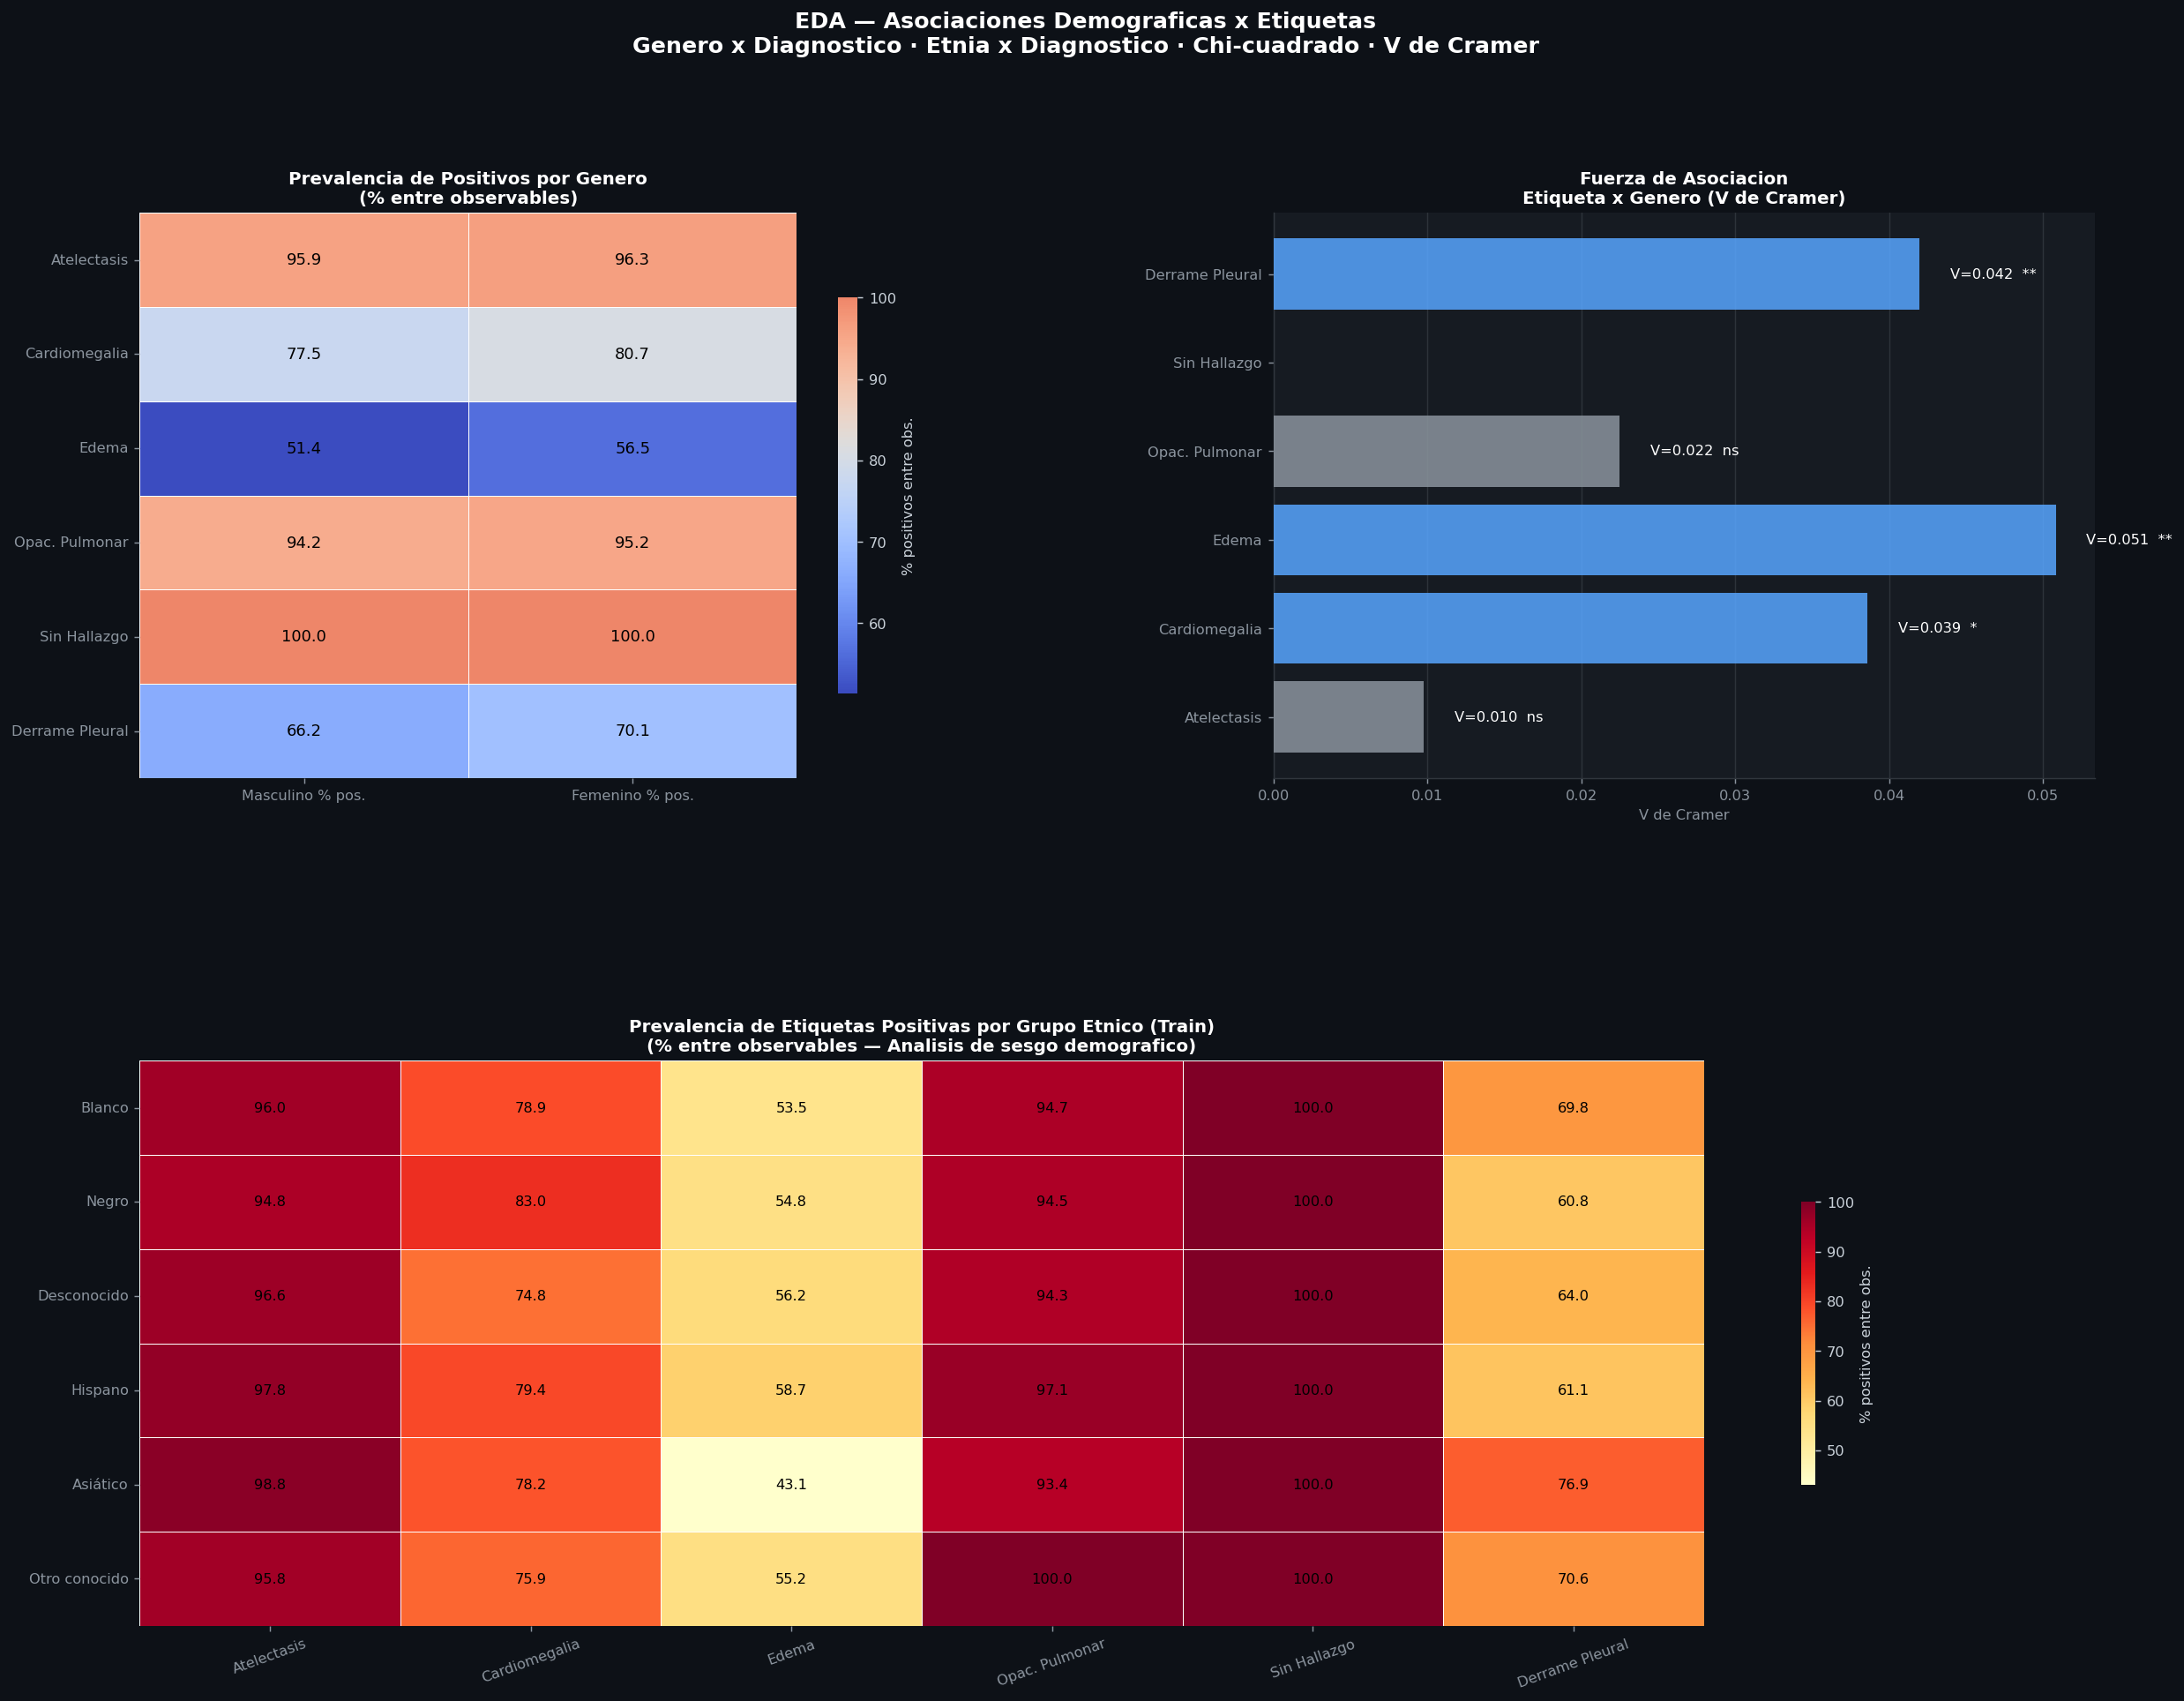

Bloque 16 guardado.


In [23]:
fig = plt.figure(figsize=(22, 16), facecolor=DARK_BG)
fig.suptitle('EDA — Asociaciones Demograficas x Etiquetas\n'
             'Genero x Diagnostico · Etnia x Diagnostico · Chi-cuadrado · V de Cramer',
             fontsize=14, fontweight='bold', color='white', y=0.99)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.50, wspace=0.38)

ax0 = fig.add_subplot(gs[0, 0], facecolor=PANEL_BG)
prev_gender = pd.DataFrame(index=LABEL_DISPLAY, columns=['Masculino % pos.', 'Femenino % pos.'])
chi_gender  = {}
for col, disp in zip(LABEL_COLS, LABEL_DISPLAY):
    df_obs = train[train[col].isin([0,1])].copy()
    for gen, lbl in [(1,'Masculino % pos.'),(0,'Femenino % pos.')]:
        sub = df_obs[df_obs['gender']==gen]
        prev_gender.loc[disp, lbl] = (sub[col]==1).sum()/len(sub)*100 if len(sub)>0 else np.nan
    ct = pd.crosstab(df_obs['gender'], df_obs[col])
    if ct.shape == (2, 2):
        chi2_v, p_v, _, _ = stats.chi2_contingency(ct)
        v_c = np.sqrt(chi2_v/(ct.values.sum()*(min(ct.shape)-1))) if min(ct.shape)>1 else 0
        chi_gender[disp] = {'chi2': chi2_v, 'p': p_v, 'V': v_c}
prev_gender = prev_gender.astype(float)
sns.heatmap(prev_gender, annot=True, fmt='.1f', cmap='coolwarm',
            center=prev_gender.values[~np.isnan(prev_gender.values)].mean(),
            ax=ax0, linewidths=0.5,
            cbar_kws={'shrink':0.7, 'label':'% positivos entre obs.'},
            annot_kws={'size':10, 'color':'black'})
ax0.set_title('Prevalencia de Positivos por Genero\n(% entre observables)', color='white')
ax0.tick_params(axis='y', rotation=0, labelsize=9, colors=C_GREY)
ax0.tick_params(axis='x', labelsize=9, colors=C_GREY)

ax1 = fig.add_subplot(gs[0, 1], facecolor=PANEL_BG)
for i, disp in enumerate(LABEL_DISPLAY):
    if disp not in chi_gender: continue
    v_ = chi_gender[disp]['V']; p_ = chi_gender[disp]['p']
    col_b = C_CYAN if p_ < 0.05 else C_GREY
    ax1.barh(i, v_, color=col_b, edgecolor='none', alpha=0.85, zorder=3)
    sig_ = '***' if p_<0.001 else '**' if p_<0.01 else '*' if p_<0.05 else 'ns'
    ax1.text(v_+0.002, i, f'V={v_:.3f}  {sig_}', va='center', fontsize=9, color='white')
ax1.set_yticks(range(len(LABEL_DISPLAY))); ax1.set_yticklabels(LABEL_DISPLAY, fontsize=9, color=C_GREY)
ax1.set_xlabel('V de Cramer', color=C_GREY)
ax1.set_title('Fuerza de Asociacion\nEtiqueta x Genero (V de Cramer)', color='white')
ax1.xaxis.grid(True, alpha=0.2, color=C_GREY); ax1.tick_params(colors=C_GREY)

ax2 = fig.add_subplot(gs[1, 0:2], facecolor=PANEL_BG)
train6 = train.copy(); train6['Etnia'] = train6['race'].map(RACE_MAP).fillna('Otro')
races6 = train6['Etnia'].value_counts().index.tolist()
prev_race = pd.DataFrame(index=races6, columns=LABEL_DISPLAY)
for col, disp in zip(LABEL_COLS, LABEL_DISPLAY):
    df_obs6 = train6[train6[col].isin([0,1])]
    for r in races6:
        sub6 = df_obs6[df_obs6['Etnia']==r]
        prev_race.loc[r, disp] = (sub6[col]==1).sum()/len(sub6)*100 if len(sub6)>0 else np.nan
prev_race = prev_race.astype(float)
sns.heatmap(prev_race, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax2, linewidths=0.5,
            cbar_kws={'shrink':0.5, 'label':'% positivos entre obs.'},
            annot_kws={'size':9, 'color':'black'})
ax2.set_title('Prevalencia de Etiquetas Positivas por Grupo Etnico (Train)\n(% entre observables — Analisis de sesgo demografico)', color='white', fontsize=11)
ax2.tick_params(axis='x', rotation=20, labelsize=9, colors=C_GREY)
ax2.tick_params(axis='y', rotation=0, labelsize=9, colors=C_GREY)

plt.savefig(out('block16_associations.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 16 guardado.")


---
## Bloque 17 — 🆕 Raw vs Percentil: Análisis Comparativo y Redundancia

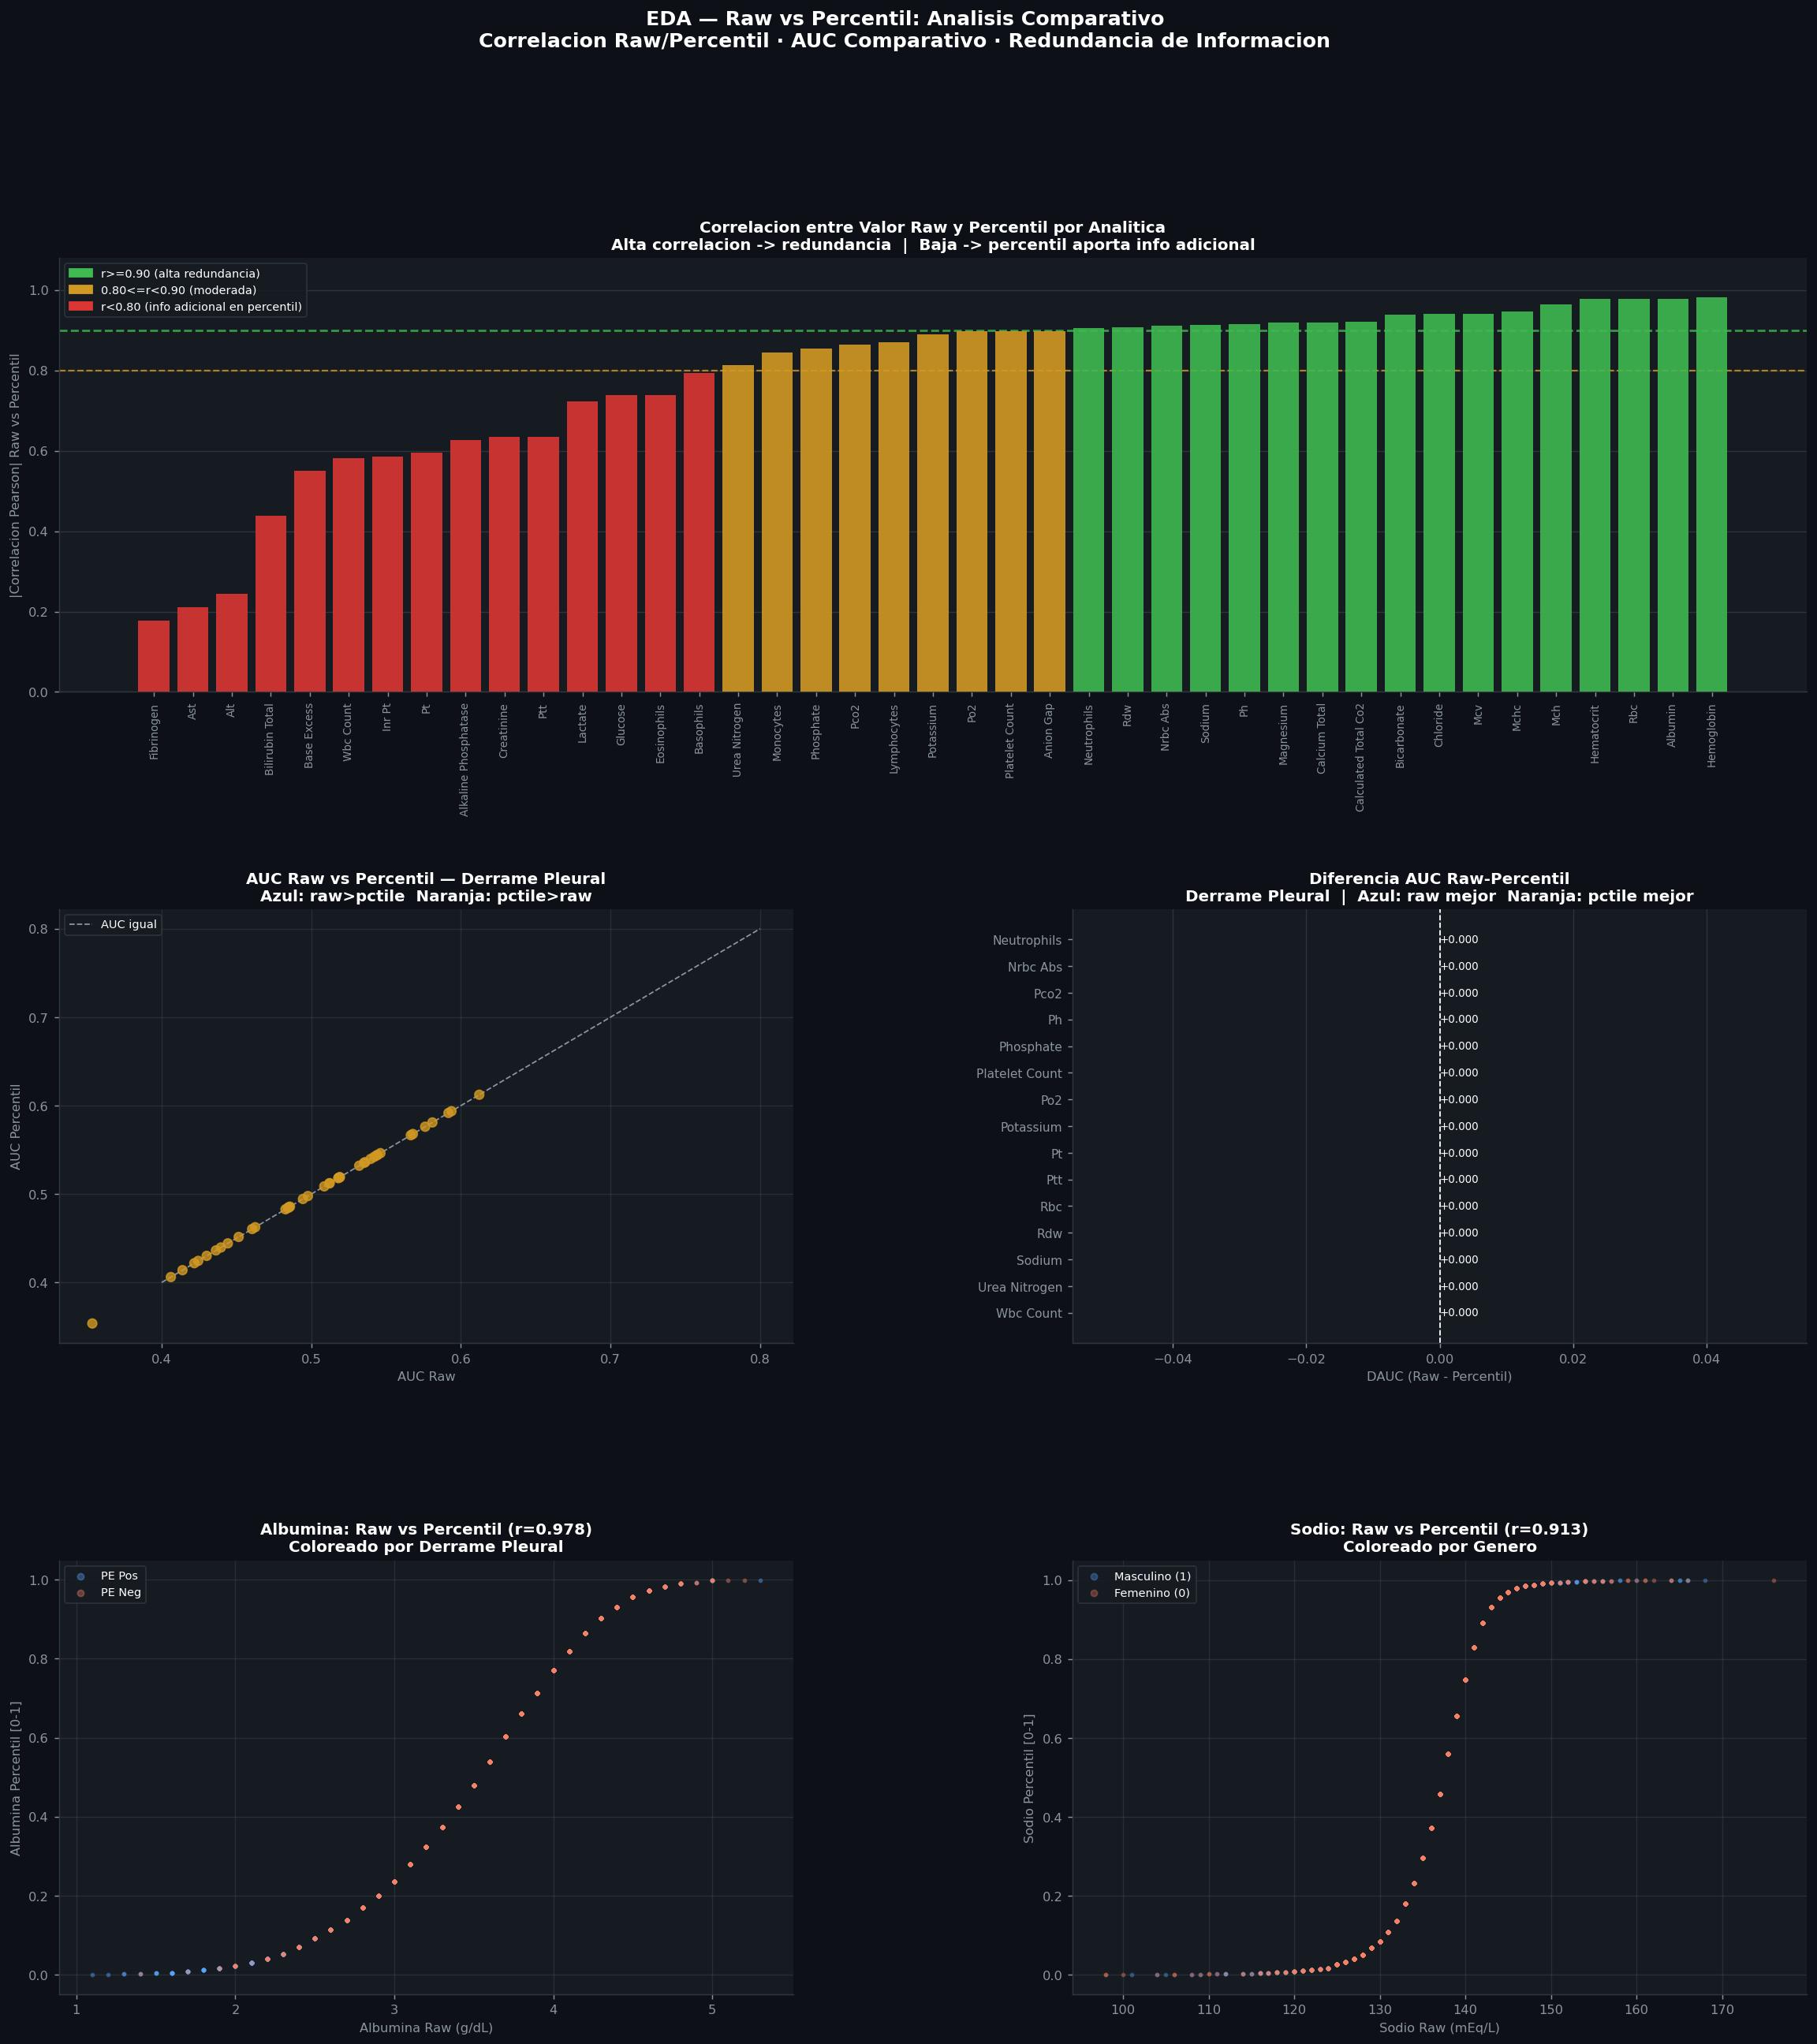

Bloque 17 guardado.


In [24]:
fig_rp = plt.figure(figsize=(22, 22), facecolor=DARK_BG)
fig_rp.suptitle('EDA — Raw vs Percentil: Analisis Comparativo\n'
                'Correlacion Raw/Percentil · AUC Comparativo · Redundancia de Informacion',
                fontsize=14, fontweight='bold', color='white', y=0.99)
gs_rp = gridspec.GridSpec(3, 2, figure=fig_rp, hspace=0.50, wspace=0.38)

raw_arr  = train[LAB_RAW_COLS].values.astype(float)
pct_arr  = train[LAB_PCTILE_COLS].values.astype(float)
miss_raw = train[LAB_RAW_COLS].isnull().mean().values

ax0 = fig_rp.add_subplot(gs_rp[0, 0:2], facecolor=PANEL_BG)
corr_rp = []
for i in range(len(LAB_RAW_COLS)):
    r = raw_arr[:, i]; p = pct_arr[:, i]; mask_valid = ~(np.isnan(r) | np.isnan(p))
    if mask_valid.sum() > 20:
        c, _ = stats.pearsonr(r[mask_valid], p[mask_valid]); corr_rp.append((LAB_RAW_DISP[i], abs(c), miss_raw[i]))
    else: corr_rp.append((LAB_RAW_DISP[i], np.nan, miss_raw[i]))
corr_rp_sorted = sorted(corr_rp, key=lambda x: (x[1] if not np.isnan(x[1]) else 0))
names_rp = [x[0] for x in corr_rp_sorted]
vals_rp  = [x[1] if not np.isnan(x[1]) else 0 for x in corr_rp_sorted]
bar_cols_rp = [C_RED if v < 0.8 else C_ORANGE if v < 0.9 else C_GREEN for v in vals_rp]
ax0.bar(range(len(names_rp)), vals_rp, color=bar_cols_rp, edgecolor='none', alpha=0.9, zorder=3)
ax0.axhline(0.9, color=C_GREEN, linestyle='--', lw=1.5, alpha=0.8)
ax0.axhline(0.8, color=C_ORANGE, linestyle='--', lw=1.2, alpha=0.8)
ax0.set_xticks(range(len(names_rp))); ax0.set_xticklabels(names_rp, rotation=90, fontsize=7.5, color=C_GREY)
ax0.set_ylabel('|Correlacion Pearson| Raw vs Percentil', color=C_GREY); ax0.set_ylim(0, 1.08)
ax0.set_title('Correlacion entre Valor Raw y Percentil por Analitica\nAlta correlacion -> redundancia  |  Baja -> percentil aporta info adicional', color='white', fontsize=11)
ax0.tick_params(colors=C_GREY); ax0.yaxis.grid(True, alpha=0.2, color=C_GREY)
patches_rp = [mpatches.Patch(color=C_GREEN, label='r>=0.90 (alta redundancia)'),
              mpatches.Patch(color=C_ORANGE, label='0.80<=r<0.90 (moderada)'),
              mpatches.Patch(color=C_RED, label='r<0.80 (info adicional en percentil)')]
ax0.legend(handles=patches_rp, fontsize=8, labelcolor='white', loc='upper left')

ax1 = fig_rp.add_subplot(gs_rp[1, 0], facecolor=PANEL_BG)
lc_focus = 'Pleural Effusion'; ld_focus = 'Derrame Pleural'
auc_raw_pe, auc_pct_pe, names_pe_cmp = [], [], []
mask_obs = train[lc_focus].isin([0,1]); y_obs = (train.loc[mask_obs, lc_focus] == 1).astype(int).values
for i in range(len(LAB_RAW_COLS)):
    r_obs = raw_arr[mask_obs.values, i]; p_obs = pct_arr[mask_obs.values, i]
    valid_r = ~np.isnan(r_obs); valid_p = ~np.isnan(p_obs)
    if valid_r.sum() >= 10 and valid_p.sum() >= 10:
        u_r, _ = stats.mannwhitneyu(r_obs[valid_r & (y_obs==1)], r_obs[valid_r & (y_obs==0)], alternative='two-sided')
        u_p, _ = stats.mannwhitneyu(p_obs[valid_p & (y_obs==1)], p_obs[valid_p & (y_obs==0)], alternative='two-sided')
        n_pos_r = (valid_r & (y_obs==1)).sum(); n_neg_r = (valid_r & (y_obs==0)).sum()
        n_pos_p = (valid_p & (y_obs==1)).sum(); n_neg_p = (valid_p & (y_obs==0)).sum()
        auc_raw_pe.append(u_r / (n_pos_r * n_neg_r) if n_pos_r*n_neg_r > 0 else 0.5)
        auc_pct_pe.append(u_p / (n_pos_p * n_neg_p) if n_pos_p*n_neg_p > 0 else 0.5)
        names_pe_cmp.append(LAB_RAW_DISP[i])
auc_raw_arr = np.array(auc_raw_pe); auc_pct_arr = np.array(auc_pct_pe)
colors_cmp = [C_CYAN if abs(a-0.5) > abs(b-0.5) else C_ORANGE for a, b in zip(auc_raw_arr, auc_pct_arr)]
ax1.scatter(auc_raw_arr, auc_pct_arr, c=colors_cmp, s=40, alpha=0.8, zorder=4)
ax1.plot([0.4,0.8],[0.4,0.8], color=C_GREY, lw=1, linestyle='--', label='AUC igual')
for i, (n, ar, ap) in enumerate(zip(names_pe_cmp, auc_raw_arr, auc_pct_arr)):
    if abs(ar-ap) > 0.03: ax1.annotate(n, (ar, ap), fontsize=6.5, color='white', xytext=(3,3), textcoords='offset points')
ax1.set_xlabel('AUC Raw', color=C_GREY); ax1.set_ylabel('AUC Percentil', color=C_GREY)
ax1.set_title(f'AUC Raw vs Percentil — {ld_focus}\nAzul: raw>pctile  Naranja: pctile>raw', color='white')
ax1.legend(fontsize=8, labelcolor='white'); ax1.tick_params(colors=C_GREY)
ax1.yaxis.grid(True, alpha=0.15, color=C_GREY); ax1.xaxis.grid(True, alpha=0.15, color=C_GREY)

ax2 = fig_rp.add_subplot(gs_rp[1, 1], facecolor=PANEL_BG)
diff_auc = auc_raw_arr - auc_pct_arr; diff_sorted_idx = np.argsort(np.abs(diff_auc))[::-1][:15]
d_names = [names_pe_cmp[i] for i in diff_sorted_idx]; d_vals = diff_auc[diff_sorted_idx]
d_cols = [C_CYAN if v > 0 else C_ORANGE for v in d_vals]
ax2.barh(range(len(d_names)), d_vals, color=d_cols, edgecolor='none', alpha=0.9, zorder=3)
ax2.axvline(0, color='white', lw=1, linestyle='--')
ax2.set_yticks(range(len(d_names))); ax2.set_yticklabels(d_names, fontsize=8.5, color=C_GREY)
ax2.set_xlabel('DAUC (Raw - Percentil)', color=C_GREY)
ax2.set_title(f'Diferencia AUC Raw-Percentil\n{ld_focus}  |  Azul: raw mejor  Naranja: pctile mejor', color='white')
ax2.tick_params(colors=C_GREY); ax2.xaxis.grid(True, alpha=0.2, color=C_GREY)
for i, v in enumerate(d_vals): ax2.text(v + 0.001*np.sign(v), i, f'{v:+.3f}', va='center', fontsize=7.5, color='white')

ax3 = fig_rp.add_subplot(gs_rp[2, 0], facecolor=PANEL_BG)
alb_raw_idx = LAB_RAW_COLS.index('albumin_50862') if 'albumin_50862' in LAB_RAW_COLS else 0
alb_pct_idx = LAB_PCTILE_COLS.index('albumin_pctile_50862') if 'albumin_pctile_50862' in LAB_PCTILE_COLS else 0
r_alb = raw_arr[:, alb_raw_idx]; p_alb = pct_arr[:, alb_pct_idx]
mask_alb = ~(np.isnan(r_alb) | np.isnan(p_alb)); pe_col_alb = train['Pleural Effusion']
for val_, col_, lbl_ in [(1, C_CYAN,'PE Pos'),(0, C_PINK,'PE Neg')]:
    m_ = mask_alb & (pe_col_alb == val_).values
    ax3.scatter(r_alb[m_], p_alb[m_], s=5, alpha=0.35, color=col_, label=lbl_, zorder=3)
c_alb = np.corrcoef(r_alb[mask_alb], p_alb[mask_alb])[0,1]
ax3.set_xlabel('Albumina Raw (g/dL)', color=C_GREY); ax3.set_ylabel('Albumina Percentil [0-1]', color=C_GREY)
ax3.set_title(f'Albumina: Raw vs Percentil (r={c_alb:.3f})\nColoreado por Derrame Pleural', color='white')
ax3.legend(fontsize=8, labelcolor='white', markerscale=2); ax3.tick_params(colors=C_GREY)
ax3.yaxis.grid(True, alpha=0.15, color=C_GREY); ax3.xaxis.grid(True, alpha=0.15, color=C_GREY)

ax4 = fig_rp.add_subplot(gs_rp[2, 1], facecolor=PANEL_BG)
sod_raw_idx = LAB_RAW_COLS.index('sodium_50983') if 'sodium_50983' in LAB_RAW_COLS else 0
sod_pct_idx = LAB_PCTILE_COLS.index('sodium_pctile_50983') if 'sodium_pctile_50983' in LAB_PCTILE_COLS else 0
r_sod = raw_arr[:, sod_raw_idx]; p_sod = pct_arr[:, sod_pct_idx]
mask_sod = ~(np.isnan(r_sod) | np.isnan(p_sod))
for gen_, col_, lbl_ in [(1, C_CYAN,'Masculino (1)'),(0, C_PINK,'Femenino (0)')]:
    m_ = mask_sod & (train['gender'] == gen_).values
    ax4.scatter(r_sod[m_], p_sod[m_], s=5, alpha=0.3, color=col_, label=lbl_, zorder=3)
c_sod = np.corrcoef(r_sod[mask_sod], p_sod[mask_sod])[0,1]
ax4.set_xlabel('Sodio Raw (mEq/L)', color=C_GREY); ax4.set_ylabel('Sodio Percentil [0-1]', color=C_GREY)
ax4.set_title(f'Sodio: Raw vs Percentil (r={c_sod:.3f})\nColoreado por Genero', color='white')
ax4.legend(fontsize=8, labelcolor='white', markerscale=2); ax4.tick_params(colors=C_GREY)
ax4.yaxis.grid(True, alpha=0.15, color=C_GREY); ax4.xaxis.grid(True, alpha=0.15, color=C_GREY)

plt.savefig(out('block17_raw_vs_pctile.png'), dpi=130, bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print("Bloque 17 guardado.")


---
## Bloque 18 — Tabla Resumen de Etiquetas y Estadísticos Finales

In [25]:
print("="*90)
print("TABLA RESUMEN COMPLETA DE ETIQUETAS DIAGNOSTICAS (Train)")
print("="*90)
print(f"{'Etiqueta':<22} {'Pos':>6} {'Neg':>6} {'Inc':>6} {'NaN':>7} {'Obs':>6} {'%Obs':>7} {'Ratio P:N':>10} {'Prev%':>7}")
print("-"*90)
for col, disp in zip(LABEL_COLS, LABEL_DISPLAY):
    s = train[col]
    c = {1: int((s==1).sum()), 0: int((s==0).sum()), -1: int((s==-1).sum()), 'NaN': int(s.isna().sum())}
    obs = c[1] + c[0]; rat = f"{c[0]/c[1]:.1f}:1" if c[1] > 0 else "inf"
    prv = f"{c[1]/obs*100:.1f}%" if obs > 0 else "no datos"
    print(f"  {disp:<22} {c[1]:>6,} {c[0]:>6,} {c[-1]:>6,} {c['NaN']:>7,} {obs:>6,} {obs/len(train)*100:>6.1f}% {rat:>10} {prv:>7}")

print()
print("="*90)
print("MISSINGNESS ANALITICAS (Train) — RAW vs PERCENTIL")
print("="*90)
miss_raw_v    = train[LAB_RAW_COLS].isnull().mean().values
miss_pctile_v = train[LAB_PCTILE_COLS].isnull().mean().values
print(f"  Total analiticas    : {len(LAB_RAW_COLS)}")
print(f"  Media raw           : {miss_raw_v.mean()*100:.1f}%")
print(f"  Media percentil     : {miss_pctile_v.mean()*100:.1f}%")
print(f"  Raw <5% missing     : {(miss_raw_v<0.05).sum()} analiticas")
print(f"  Raw 5-70% missing   : {((miss_raw_v>=0.05)&(miss_raw_v<0.7)).sum()} analiticas")
print(f"  Raw >70% missing    : {(miss_raw_v>=0.7).sum()} analiticas")
print(f"  Max missing (raw)   : {LAB_RAW_DISP[miss_raw_v.argmax()]} ({miss_raw_v.max()*100:.1f}%)")
print(f"  Min missing (raw)   : {LAB_RAW_DISP[miss_raw_v.argmin()]} ({miss_raw_v.min()*100:.1f}%)")

print()
print("="*90)
print("SCALE_POS_WEIGHT RECOMENDADO POR ETIQUETA (XGBoost)")
print("="*90)
for col, disp in zip(LABEL_COLS, LABEL_DISPLAY):
    s = train[col]; n_pos = int((s==1).sum()); n_neg = int((s==0).sum())
    if n_pos == 0: print(f"  {disp:<22} : no aplica"); continue
    spw = n_neg/n_pos; print(f"  {disp:<22} : pos={n_pos:>5,}  neg={n_neg:>5,}  SPW={spw:.2f}")

print()
print("="*90)
print("SPLIT CONSISTENCY CHECK")
print("="*90)
for sp in ['train','val','test']:
    df_sp = dfs[sp]
    obs_any = df_sp[LABEL_COLS].apply(lambda x: ((x==0)|(x==1)).sum(), axis=1)
    n = len(df_sp)
    print(f"  {sp.upper():<6}  n={n:>6,}  >=1 label obs: {(obs_any>=1).sum():>6,} "
          f"({(obs_any>=1).mean()*100:.1f}%)  0 labels: {(obs_any==0).sum():>4,} ({(obs_any==0).mean()*100:.1f}%)")


TABLA RESUMEN COMPLETA DE ETIQUETAS DIAGNOSTICAS (Train)
Etiqueta                  Pos    Neg    Inc     NaN    Obs    %Obs  Ratio P:N   Prev%
------------------------------------------------------------------------------------------
  Atelectasis             2,867    118    588   6,427  2,985   29.8%      0.0:1   96.0%
  Cardiomegalia           3,346    886    450   5,318  4,232   42.3%      0.3:1   79.1%
  Edema                   2,067  1,772    834   5,327  3,839   38.4%      0.9:1   53.8%
  Opac. Pulmonar          3,108    175    223   6,494  3,283   32.8%      0.1:1   94.7%
  Sin Hallazgo            1,368      0      0   8,632  1,368   13.7%      0.0:1  100.0%
  Derrame Pleural         3,618  1,701    371   4,310  5,319   53.2%      0.5:1   68.0%

MISSINGNESS ANALITICAS (Train) — RAW vs PERCENTIL
  Total analiticas    : 41
  Media raw           : 19.5%
  Media percentil     : 19.5%
  Raw <5% missing     : 17 analiticas
  Raw 5-70% missing   : 24 analiticas
  Raw >70% missing    : 

---
## Conclusiones del EDA (v3)

> **Bloque reservado para síntesis en el TFM.**

**Hallazgos clave documentados en los 18 bloques:**

| Bloque | Análisis | Hallazgo principal |
|--------|----------|--------------------|
| 1 | Visión general | Distribución de particiones y cobertura multimodal |
| 2 | Demografía | Sesgos de edad, género y etnia entre grupos diagnósticos |
| 3 | Etiquetas | Desequilibrio severo; co-ocurrencia Edema-Derrame Pleural |
| 4 | Missingness | Patrón diferencial Raw vs Percentil |
| 5-6 | Labs vs etiquetas | Señal discriminativa real; diferencias significativas MW |
| 7 | AUC heatmap | Top labs por patología; radares de perfil clínico |
| 8 | Calidad | SPW para XGBoost; consistencia de splits |
| 9 | Inferencia | Forest plots con IC bootstrap; Δ medianas normalizadas |
| 10 | Clustering | Grupos fisiológicos de analíticas (Ward linkage) |
| **11** | **PCA / t-SNE** | **Separabilidad parcial por diagnóstico; scree plot guía dimensionalidad** |
| **12** | **Co-ocurrencia + Spearman** | **Correlaciones Spearman significativas Labs × Etiquetas** |
| **13** | **Perfiles radar** | **Top-10 labs discriminativos globales; perfiles medios por diagnóstico** |
| **14** | **Missingness MNAR** | **Δ missingness sistemático en Edema y Derrame Pleural** |
| **15** | **IVF** | **Ranking global de features; cruce de 3 métodos de importancia** |
| 16 | Género × Etnia | Sesgos demográficos; implicaciones de equidad |
| **17** | **Raw vs Percentil** | **Alta redundancia (r>0.9) en la mayoría; percentil aporta info en outliers** |
| 18 | Resumen | SPW, missingness, consistencia split |
